# PTT WomenTalk「難過」貼文的文字探勘、主題分類與情緒分析

這份 notebook 以課堂報告可交版為目標，主線聚焦在一個問題：
**WomenTalk 的「難過」貼文，主要是在為哪些具體事情難過？**

目前可穩定執行的主分析流程為 `jieba + 自訂詞典/停用字 + 主題分類 + LIWC 字典法情緒分析 + SnowNLP 比較`；簡化字典法 baseline 仍保留做方法對照，`CKIP NER` 則保留為延伸段落，若環境不相容會自動略過，不讓 notebook 中斷。

為了讓結論更有說服力，本 notebook 不只停在「整體偏負面」的描述，而是建立一條清楚的證據鏈：
1. 先用高頻詞、高頻名詞與文字雲描述整體語料輪廓。
2. 再用 `final_secondary_topic` 回答「真正的難過來源」是什麼。
3. 最後用 `LIWC`、`SnowNLP`、代表月份、代表句與代表文章，把量化結果拉回文本脈絡。

研究問題：
1. 在排除雜訊後，文章裡最常出現的高頻詞與高頻名詞是什麼？
2. 用標題加權的主題分類後，最常見的具體困擾類型有哪些？
3. 不同月份之間，主題與情緒強度是否出現變化？

閱讀提醒：
- 這份資料本身就是以「難過」為關鍵字抓取，因此整體偏負面是合理現象。
- 報告重點不應只停在抽象情緒，而要結合**高頻名詞、主題分類、情緒方法比較、代表句與代表文章**，說明真正的困擾來源。


## 0. 環境、套件與執行提醒

建議直接在 `textmining` 環境中執行本 notebook，並優先使用課堂提供的 requirements 檔安裝版本：

```bash
conda activate textmining
pip install -r SMA_2026S-main/requirements.txt
```

補充說明：
- 這份 notebook 目前已把 `LIWC` 接成情緒分析主線，並加入 `SnowNLP` 做比較；若本機缺少 `snownlp` 套件，相關段落會自動略過。
- `CKIP NER` 已保留架構與欄位，但在目前這台 `macOS x86_64` 機器上，實測 `ckiptagger` 會觸發 CPU 相容性錯誤，因此會自動略過。
- 若後續還要再做更重的模型比較，可另參考 `1150326_refactor_plan.md`。


## 0.1 研究動機、資料來源與分析單位

在 PTT WomenTalk 板中，「難過」相關貼文常反映使用者在感情、人際、家庭、工作與自我情緒上的困擾。
因此，本研究希望透過文字探勘與情緒分析，整理這類貼文主要討論的生活情境，並觀察不同月份之間是否存在主題與情緒的變化。

本研究使用目前工作目錄中的 `sna2026s_11_f90d8ae436_12.csv`，以 **article-level** 為主要分析單位，也就是一列代表一篇文章。
主分析欄位包含：
- `artTitle`
- `artDate`
- `artContent`
- `artComment`
- `artUrl`

需要特別提醒的是，這份資料本身就是以「難過」作為關鍵字抓取，因此整體情緒偏負面是可預期的。
所以本研究的重點不只是確認「負面很多」，而是要進一步說明：
1. 難過主要出現在哪些生活情境。
2. 哪些主題最常見，且最值得作為正式結論。
3. 文章中是否同時出現支持、安慰、陪伴等較正向語彙。


## 0.2 分析架構與報告閱讀路徑

為了讓整份報告更流暢，本 notebook 依照「輪廓 -> 主題 -> 情緒 -> 代表文本」的順序安排：
1. 資料來源與樣本整理：交代資料期間、樣本數與核心樣本定義。
2. 文字清理與斷詞前處理：確保後續分析不被雜訊帶偏。
3. 高頻詞、高頻名詞與文字雲：描述整體語料輪廓。
4. 主題分類：正式回答「大家到底在難過什麼」。
5. 情緒分析：以 `LIWC` 為主線，搭配簡化字典法 baseline 與 `SnowNLP` 比較。
6. 代表月份、代表句與代表文章：把量化結果拉回文本脈絡。
7. 結論、限制與輸出整理：收束整體分析。

方法定位上，這份 notebook 以**可穩定重現的主分析流程**為主：`jieba` 負責主線斷詞，`final_secondary_topic` 回答「在難過什麼」，`LIWC` 回答「哪些情緒詞在文本中最明確」，`SnowNLP` 提供第二種情緒觀點，`CKIP NER` 則保留為延伸證據。


In [1]:
# 0-1 套件檢查

import importlib.util
import sys

required_packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "jieba",
    "wordcloud",
]
optional_packages = ["seaborn", "tqdm", "snownlp", "ckiptagger"]

missing_required = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
missing_optional = [pkg for pkg in optional_packages if importlib.util.find_spec(pkg) is None]

print(f"目前 Python：{sys.executable}")

if not missing_required:
    print("必要套件皆已安裝完成，可以直接往下執行。")
else:
    print("以下必要套件尚未安裝：", ", ".join(missing_required))
    print(f"建議安裝指令：!pip install {' '.join(missing_required)}")

if missing_optional:
    print("以下可選套件尚未安裝：", ", ".join(missing_optional))
    print("缺少 seaborn / tqdm 時不影響主流程；缺少 snownlp / ckiptagger 時，對應比較段落會自動略過。")
else:
    print("可選套件 seaborn、tqdm、snownlp、ckiptagger 已安裝。")


目前 Python：/Users/ye/miniconda3/envs/textmining/bin/python
必要套件皆已安裝完成，可以直接往下執行。
可選套件 seaborn、tqdm、snownlp、ckiptagger 已安裝。


In [2]:
# 0-2 匯入分析套件

import re
from collections import Counter
from pathlib import Path

import jieba
import jieba.posseg as pseg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import font_manager
from wordcloud import WordCloud

try:
    import seaborn as sns
    seaborn_available = True
except Exception:
    sns = None
    seaborn_available = False

try:
    from tqdm.auto import tqdm
    tqdm_available = True
except Exception:
    tqdm = None
    tqdm_available = False

try:
    from snownlp import SnowNLP
    snownlp_available = True
except Exception:
    SnowNLP = None
    snownlp_available = False

try:
    from ckiptagger import NER, POS, WS
    ckiptagger_available = True
except Exception:
    WS = POS = NER = None
    ckiptagger_available = False


2026-03-26 23:39:48.758125: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# 0-3 設定輸出資料夾
base_dir = Path.cwd()
data_path = base_dir / "sna2026s_11_f90d8ae436_12.csv"
results_dir = base_dir / "results"
results_dir.mkdir(parents=True, exist_ok=True)

print(f"目前工作目錄：{base_dir}")
print(f"資料檔案位置：{data_path}")
print(f"必要 CSV 將輸出到：{results_dir}")
print("圖表與表格以 notebook cell output 為主，不另外儲存圖片檔。")


目前工作目錄：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告
資料檔案位置：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/sna2026s_11_f90d8ae436_12.csv
必要 CSV 將輸出到：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/results
圖表與表格以 notebook cell output 為主，不另外儲存圖片檔。


In [4]:
# 0-4 設定繪圖風格與共用函式
if seaborn_available:
    sns.set_theme(style="whitegrid")
else:
    plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.unicode_minus"] = False

if tqdm_available:
    tqdm.pandas()


def print_step_start(step_code, step_title):
    print("\n" + "=" * 72)
    print(f"步驟 {step_code}：{step_title}")
    print("=" * 72)


def print_step_end(step_code, step_title):
    print(f"[完成] {step_code} {step_title}\n")


def iter_with_progress(iterable, desc):
    if tqdm_available:
        return tqdm(iterable, desc=desc)
    print(f"[進行中] {desc}")
    return iterable


def apply_with_progress(obj, func, desc, axis=0, **kwargs):
    if tqdm_available:
        tqdm.pandas(desc=desc)
        if isinstance(obj, pd.DataFrame):
            return obj.progress_apply(func, axis=axis, **kwargs)
        return obj.progress_apply(func, **kwargs)
    print(f"[開始] {desc}")
    if isinstance(obj, pd.DataFrame):
        result = obj.apply(func, axis=axis, **kwargs)
    else:
        result = obj.apply(func, **kwargs)
    print(f"[完成] {desc}")
    return result


def plot_horizontal_bar(data, x_col, y_col, title, xlabel, ylabel, color="#4C72B0"):
    """
    seaborn 不存在時，改用 matplotlib 畫水平長條圖。
    """
    plt.figure(figsize=(12, 7))
    if seaborn_available:
        sns.barplot(data=data, x=x_col, y=y_col, color=color)
    else:
        plt.barh(data[y_col], data[x_col], color=color)
        plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()


def plot_histogram(values, bins, title, xlabel, ylabel, color="#4C72B0", kde=False):
    """
    seaborn 不存在時，改用 matplotlib 畫直方圖。
    """
    plt.figure(figsize=(10, 6))
    if seaborn_available:
        sns.histplot(values, bins=bins, kde=kde, color=color)
    else:
        plt.hist(values, bins=bins, color=color, alpha=0.85, edgecolor="white")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()


def configure_matplotlib_chinese_font():
    """
    嘗試設定常見中文字型，若找不到則只印出提示，不讓程式中斷。
    """
    candidate_fonts = [
        "Arial Unicode MS",
        "PingFang TC",
        "Heiti TC",
        "Microsoft JhengHei",
        "Noto Sans CJK TC",
        "Noto Sans CJK JP",
        "SimHei",
    ]

    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in candidate_fonts:
        if font_name in available_fonts:
            plt.rcParams["font.family"] = font_name
            print(f"已設定中文字型：{font_name}")
            return font_name

    print("提醒：找不到常見中文字型，圖表中文字可能無法正常顯示。")
    return None


def get_wordcloud_font_path():
    """
    回傳可供 wordcloud 使用的中文字型路徑；若找不到則回傳 None。
    """
    candidate_paths = [
        "/System/Library/Fonts/PingFang.ttc",
        "/System/Library/Fonts/Hiragino Sans GB.ttc",
        "/Library/Fonts/Arial Unicode.ttf",
        "/System/Library/Fonts/Supplemental/Songti.ttc",
    ]
    for path in candidate_paths:
        if Path(path).exists():
            return path
    return None


def build_top_word_table(tokens, top_n=20, word_col="word"):
    counter = Counter(tokens)
    return pd.DataFrame(counter.most_common(top_n), columns=[word_col, "count"])


def safe_join(values, top_n=None):
    if values is None:
        return ""
    if not isinstance(values, (list, tuple, set)):
        return str(values)
    ordered_values = list(values)
    if top_n is not None:
        ordered_values = ordered_values[:top_n]
    return "、".join([str(value) for value in ordered_values if str(value).strip()])


chinese_font_name = configure_matplotlib_chinese_font()
wordcloud_font_path = get_wordcloud_font_path()


已設定中文字型：Arial Unicode MS


## 1. 讀取資料與基本檢查

這一段的目的，是先回答最基本的研究設計問題：資料從哪裡來、期間多長、規模多大。

本段會完成：
- 讀取 CSV。
- 檢查資料大小、欄位、缺值、重複網址。
- 將 `artDate` 轉為 datetime。
- 建立 `year`、`month`、`month_of_year`。
- 說明資料期間與資料筆數。

這一段雖然偏基礎，但它決定了後面所有圖表與趨勢解讀是否站得住腳。


In [5]:
# 1-1 讀取原始資料

print_step_start("1-1", "讀取原始資料")
if not data_path.exists():
    raise FileNotFoundError(f"找不到資料檔：{data_path}")

# 嘗試用不同方式讀取，避免因編碼或 parser 問題而失敗
read_attempts = [
    {"encoding": "utf-8-sig", "low_memory": False},
    {"encoding": "utf-8", "low_memory": False},
    {"encoding": "utf-8-sig", "engine": "python"},
]

df_raw = None
last_error = None

for options in read_attempts:
    try:
        df_raw = pd.read_csv(data_path, **options)
        print(f"成功讀取資料，參數：{options}")
        break
    except Exception as error:
        last_error = error

if df_raw is None:
    raise RuntimeError(f"CSV 讀取失敗，最後錯誤訊息：{last_error}")

analysis_columns = ["artTitle", "artDate", "artContent", "artComment", "artUrl"]
df_all = df_raw[analysis_columns].copy()
df = df_all.copy()


print_step_end("1-1", "讀取原始資料")



步驟 1-1：讀取原始資料


成功讀取資料，參數：{'encoding': 'utf-8-sig', 'low_memory': False}
[完成] 1-1 讀取原始資料



In [6]:
# 1-2 顯示資料基本資訊

print("資料 shape：", df_raw.shape)
print("欄位名稱：")
print(df_raw.columns.tolist())

print("\n前 5 筆資料：")
display(df.head())



資料 shape： (7571, 11)
欄位名稱：
['system_id', 'artUrl', 'artTitle', 'artDate', 'artPoster', 'artCatagory', 'artContent', 'artComment', 'e_ip', 'insertedDate', 'dataSource']

前 5 筆資料：


,artTitle,artDate,artContent,artComment,artUrl
0,[難過]2020年12月步數不足,2021-01-01 00:22:20,2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都沒有跑步，於是步數就不足了。\n...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""rukawa514"", ...",https://www.ptt.cc/bbs/WomenTalk/M.1609431742....
1,[難過]陽台又淹水了,2021-01-01 06:18:41,大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門一打開發現是樓下的鄰...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""molopo"", ""cm...",https://www.ptt.cc/bbs/WomenTalk/M.1609453123....
2,[閒聊]關於朋友這件事：（,2021-01-01 12:03:30,不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是真心的朋友，在我遇到很難過...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""g7a7n7"", ""cm...",https://www.ptt.cc/bbs/WomenTalk/M.1609473812....
3,[討論]大家都怎麼形容自己非常難過,2021-01-02 00:56:10,小弟才疏學淺\n\n最近想表達自己狀況不好\n\n但是我來說去\n\n就一直只能\n“說我真...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""darkswordbow...",https://www.ptt.cc/bbs/WomenTalk/M.1609520172....
4,Re:[討論]大家都怎麼形容自己非常難過,2021-01-02 02:56:23,難過是什麼？\n為什麼要形容難過？\n形容難過形容的很好可以幹嘛？\n世界就會變好了嗎？\n...,[],https://www.ptt.cc/bbs/WomenTalk/M.1609527385....


In [7]:
# 1-3 檢查缺值

missing_table = df.isna().sum().reset_index()
missing_table.columns = ["column", "missing_count"]
missing_table["missing_ratio"] = (missing_table["missing_count"] / len(df)).round(4)

print("表 1-3 缺值統計")
display(missing_table)


表 1-3 缺值統計


,column,missing_count,missing_ratio
0,artTitle,0,0.0000
1,artDate,0,0.0000
2,artContent,7,0.0009
3,artComment,0,0.0000
4,artUrl,0,0.0000


In [8]:
# 1-4 檢查重複網址

duplicate_url_count = df["artUrl"].duplicated().sum()
print(f"artUrl 重複筆數：{duplicate_url_count}")



artUrl 重複筆數：0


In [9]:
# 1-5 建立日期欄位與月份統計

month_order = list(range(1, 13))
month_label_map = {month: f"{month}月" for month in month_order}

df["artDate_dt"] = pd.to_datetime(df["artDate"], errors="coerce")
df["year"] = df["artDate_dt"].dt.year
df["month"] = df["artDate_dt"].dt.strftime("%Y-%m")
df["month_of_year"] = df["artDate_dt"].dt.month
df["month_label"] = df["month_of_year"].apply(
    lambda value: month_label_map.get(int(value)) if pd.notna(value) else np.nan
)

date_min = df["artDate_dt"].min()
date_max = df["artDate_dt"].max()
valid_date_count = df["artDate_dt"].notna().sum()

print(f"成功轉換日期的筆數：{valid_date_count} / {len(df)}")
print(f"資料期間：{date_min} 至 {date_max}")
print(f"資料總筆數：{len(df):,} 篇文章")

monthly_article_counts = (
    df.dropna(subset=["month_of_year"])
    .groupby("month_of_year")
    .size()
    .reset_index(name="article_count")
    .sort_values("month_of_year")
)
monthly_article_counts["month_of_year"] = monthly_article_counts["month_of_year"].astype(int)
monthly_article_counts["month_label"] = monthly_article_counts["month_of_year"].map(month_label_map)
print("表 1-5 各月份貼文數量（跨年聚合）")
display(monthly_article_counts)


成功轉換日期的筆數：7571 / 7571
資料期間：2021-01-01 00:22:20 至 2025-12-20 15:05:57
資料總筆數：7,571 篇文章
表 1-5 各月份貼文數量（跨年聚合）


,month_of_year,article_count,month_label
0,1,761,1月
1,2,627,2月
2,3,597,3月
3,4,584,4月
4,5,657,5月
5,6,588,6月
6,7,600,7月
7,8,543,8月
8,9,638,9月
9,10,654,10月


圖 1-6 各月份貼文數量趨勢圖（跨年聚合）


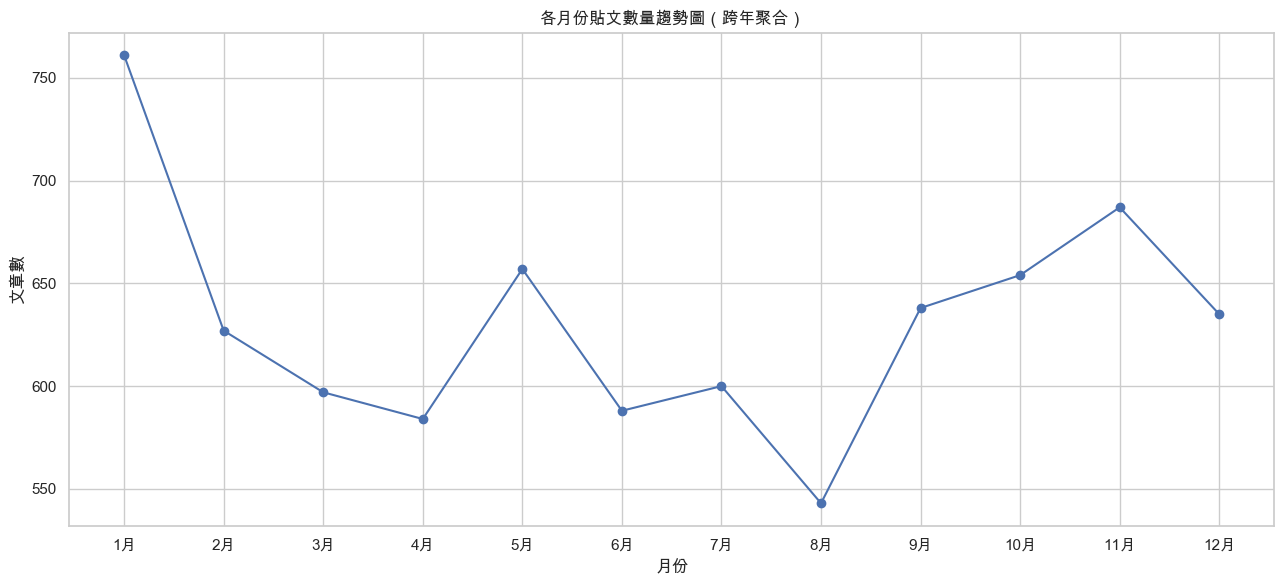

In [10]:
# 1-6 繪製各月份貼文數量趨勢圖

plt.figure(figsize=(13, 6))
plt.plot(
    monthly_article_counts["month_of_year"],
    monthly_article_counts["article_count"],
    marker="o",
    color="#4C72B0",
)
plt.title("各月份貼文數量趨勢圖（跨年聚合）")
plt.xlabel("月份")
plt.ylabel("文章數")
plt.xticks(month_order, [month_label_map[month] for month in month_order], rotation=0)
plt.tight_layout()
print("圖 1-6 各月份貼文數量趨勢圖（跨年聚合）")
plt.show()


## 2. 文字清理與分析欄位建立

這一段對應課堂中的**前處理**，重點不是把所有文字混在一起，而是把標題與內文分開處理，再建立真正用於分析的欄位。

主要欄位：
- `clean_content`：只清理內文。
- `clean_title_for_analysis`：只整理標題。
- `analysis_text`：分析時才把整理後標題與內文合併。

這樣做有三個好處：
1. 避免標題被重複計算。
2. 保留標題在主題分類中的辨識力。
3. 讓後面的高頻詞、主題分類與代表文章可以分別回看標題與內文。


In [11]:
# 2-1 建立文字清理函式與分析欄位

df["artTitle"] = df["artTitle"].fillna("")
df["artContent"] = df["artContent"].fillna("")
df["full_text"] = (df["artTitle"] + " " + df["artContent"]).str.strip()


def extract_title_tag(title):
    """
    只抽取標題最前面的 [標籤]，並容許前面有 Re:/Fw: 前綴。
    例如 [難過]...、Re:[難過]...、Fw:[心情]...。
    若標題中段才出現 []，則不視為 title_tag。
    """
    if pd.isna(title):
        return "無標籤"

    title = str(title).strip()
    title = re.sub(r"^\s*(?:Re|Fw):\s*", "", title, flags=re.IGNORECASE)
    match = re.match(r"^\[([^\]]+)\]", title)
    if match:
        return match.group(1).strip()
    return "無標籤"


def clean_title_for_analysis(title):
    """
    移除標題前方的 Re:/Fw: 與 [xxx] 標籤，保留適合做主題分析的文字。
    """
    if pd.isna(title):
        return ""

    title = str(title).strip()
    title = re.sub(r"^\s*(?:Re|Fw):\s*", "", title, flags=re.IGNORECASE)
    title = re.sub(r"^(?:\s*\[[^\]]+\])+", " ", title)
    title = re.sub(r"\s{2,}", " ", title)
    return title.strip()


def fullwidth_to_halfwidth(text):
    """
    將常見全形符號轉成半形，降低清理後的雜訊。
    """
    if not isinstance(text, str):
        text = str(text)

    translation_table = str.maketrans(
        {
            "，": ",",
            "。": ".",
            "！": "!",
            "？": "?",
            "：": ":",
            "；": ";",
            "（": "(",
            "）": ")",
            "【": "[",
            "】": "]",
            "　": " ",
        }
    )
    return text.translate(translation_table)


def clean_content(text):
    """
    清理文章內文，盡量保留之後可分析的資訊。
    這裡只處理內文，避免標題被重複納入分析。
    """
    if pd.isna(text):
        return ""

    text = str(text)
    text = fullwidth_to_halfwidth(text)

    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"imgur\S*", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"Sent from JPTT.*", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"Sent from my .*", " ", text, flags=re.IGNORECASE)
    text = re.sub(
        r'[^0-9A-Za-z\u4e00-\u9fff\s\.,!?;:\'"()\[\]/\-_%&:+]',
        " ",
        text,
    )
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n+", "\n", text)
    text = re.sub(r"\s{2,}", " ", text)
    return text.strip()


print_step_start("2-1", "建立 clean_content、title_tag、analysis_text")
df["clean_content"] = apply_with_progress(df["artContent"], clean_content, "2-1 clean_content")
df["title_tag"] = apply_with_progress(df["artTitle"], extract_title_tag, "2-1 title_tag")
df["is_reply"] = df["artTitle"].str.contains(r"^\s*Re:", case=False, na=False)
df["clean_title_for_analysis"] = apply_with_progress(
    df["artTitle"],
    clean_title_for_analysis,
    "2-1 clean_title_for_analysis",
)
df["analysis_text"] = (
    df["clean_title_for_analysis"].fillna("").str.strip()
    + " "
    + df["clean_content"].fillna("").str.strip()
).str.strip()
df["text_length"] = df["clean_content"].str.len()
print_step_end("2-1", "建立 clean_content、title_tag、analysis_text")



步驟 2-1：建立 clean_content、title_tag、analysis_text


2-1 clean_content:   0%|          | 0/7571 [00:00<?, ?it/s]

2-1 title_tag:   0%|          | 0/7571 [00:00<?, ?it/s]

2-1 clean_title_for_analysis:   0%|          | 0/7571 [00:00<?, ?it/s]

[完成] 2-1 建立 clean_content、title_tag、analysis_text



In [12]:
# 2-2 顯示清理前後示例

cleaning_examples = df.loc[
    df["full_text"].str.len() > 0,
    ["artTitle", "artContent", "clean_title_for_analysis", "clean_content", "analysis_text"],
].head(3).copy()
cleaning_examples["artContent_preview"] = cleaning_examples["artContent"].str.slice(0, 180)
cleaning_examples["clean_content_preview"] = cleaning_examples["clean_content"].str.slice(0, 180)
cleaning_examples["analysis_text_preview"] = cleaning_examples["analysis_text"].str.slice(0, 180)

print("表 2-2 清理前後示例（前 3 筆）")
display(
    cleaning_examples[
        [
            "artTitle",
            "clean_title_for_analysis",
            "artContent_preview",
            "clean_content_preview",
            "analysis_text_preview",
        ]
    ]
)


表 2-2 清理前後示例（前 3 筆）


,artTitle,clean_title_for_analysis,artContent_preview,clean_content_preview,analysis_text_preview
0,[難過]2020年12月步數不足,2020年12月步數不足,2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都沒有跑步，於是步數就不足了。\n...,"2020年12月實在是太太多事,沒辦法多走路,這幾個禮拜也都沒有跑步,於是步數就不足了.\n...","2020年12月步數不足 2020年12月實在是太太多事,沒辦法多走路,這幾個禮拜也都沒有跑..."
1,[難過]陽台又淹水了,陽台又淹水了,大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門一打開發現是樓下的鄰...,"大家...早安,我芙尼.\n大概五點的時候我被一陣電鈴聲吵醒,\n門一打開發現是樓下的鄰居,...","陽台又淹水了 大家...早安,我芙尼.\n大概五點的時候我被一陣電鈴聲吵醒,\n門一打開發現..."
2,[閒聊]關於朋友這件事：（,關於朋友這件事：（,不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是真心的朋友，在我遇到很難過...,"不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了.\n以為是真心的朋友,在我遇到很難過...",關於朋友這件事：（ 不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了.\n以為是真心的...


In [13]:
# 2-3 文章長度統計

text_length_summary_df = df["text_length"].describe().reset_index()
text_length_summary_df.columns = ["metric", "value"]

print("表 2-3 文章長度基本統計（以 clean_content 計算）")
display(text_length_summary_df)


表 2-3 文章長度基本統計（以 clean_content 計算）


,metric,value
0,count,7571.000000
1,mean,248.531502
2,std,485.302217
3,min,0.000000
4,25%,82.000000
5,50%,124.000000
6,75%,242.000000
7,max,21612.000000


圖 2-4 文章長度分布圖


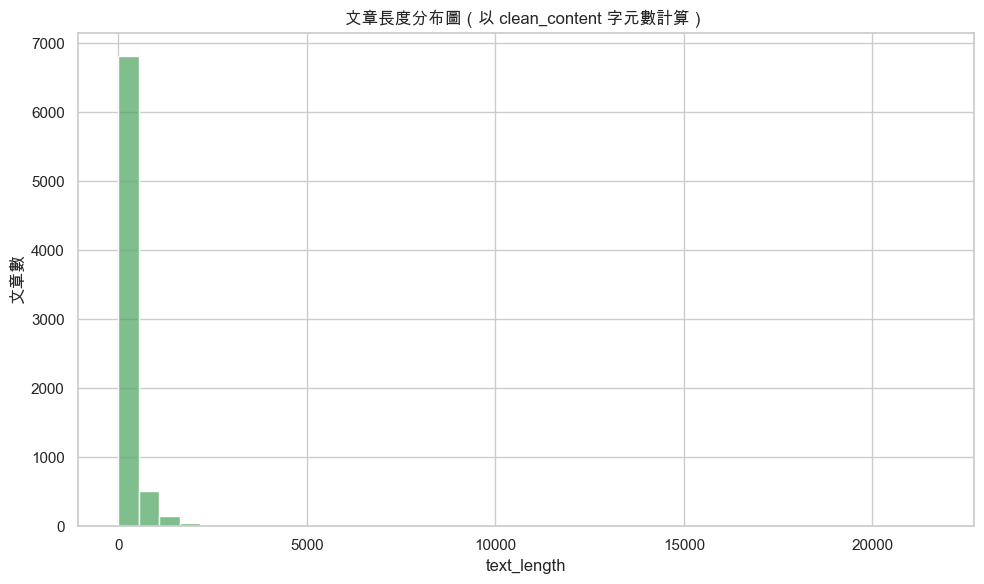

In [14]:
# 2-4 繪製文章長度分布圖

plot_histogram(
    df["text_length"],
    bins=40,
    title="文章長度分布圖（以 clean_content 字元數計算）",
    xlabel="text_length",
    ylabel="文章數",
    color="#55A868",
)
print("圖 2-4 文章長度分布圖")
plt.show()


In [15]:
# 2-5 輸出清理後資料

cleaned_output_columns = [
    "artTitle",
    "title_tag",
    "is_reply",
    "clean_title_for_analysis",
    "artDate",
    "artContent",
    "artComment",
    "artUrl",
    "year",
    "month",
    "month_of_year",
    "month_label",
    "full_text",
    "clean_content",
    "analysis_text",
    "text_length",
]
df[cleaned_output_columns].to_csv(
    results_dir / "cleaned_articles.csv",
    index=False,
    encoding="utf-8-sig",
)
print(f"已輸出清理後資料：{results_dir / 'cleaned_articles.csv'}")
print("提醒：clean_content 只保留內文，analysis_text 才是標題 + 內文的分析版本。")


已輸出清理後資料：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/results/cleaned_articles.csv
提醒：clean_content 只保留內文，analysis_text 才是標題 + 內文的分析版本。


In [16]:
# 2-6 同步整理後欄位回全樣本
df_all = df.copy()



In [17]:
# 2-7 標題標籤分布與回文比例

title_tag_counts_df = (
    df["title_tag"]
    .value_counts()
    .reset_index()
)
title_tag_counts_df.columns = ["title_tag", "count"]
title_tag_counts_df["ratio"] = (title_tag_counts_df["count"] / len(df)).round(4)

reply_ratio = df["is_reply"].mean()
reply_ratio_df = pd.DataFrame(
    {
        "metric": ["reply_count", "reply_ratio"],
        "value": [int(df["is_reply"].sum()), round(float(reply_ratio), 4)],
    }
)

print("表 2-7 title_tag 分布表")
display(title_tag_counts_df.head(15))
print(f"回文比例 reply_ratio：{reply_ratio:.2%}")
display(reply_ratio_df)


表 2-7 title_tag 分布表


,title_tag,count,ratio
0,難過,6224,0.8221
1,閒聊,495,0.0654
2,心情,366,0.0483
3,討論,164,0.0217
4,問題,153,0.0202
5,新聞,123,0.0162
6,無標籤,20,0.0026
7,灑花,14,0.0018
8,活動,4,0.0005
9,問卦,3,0.0004


回文比例 reply_ratio：21.57%


,metric,value
0,reply_count,1633.0000
1,reply_ratio,0.2157


圖 2-8 標題標籤分布圖


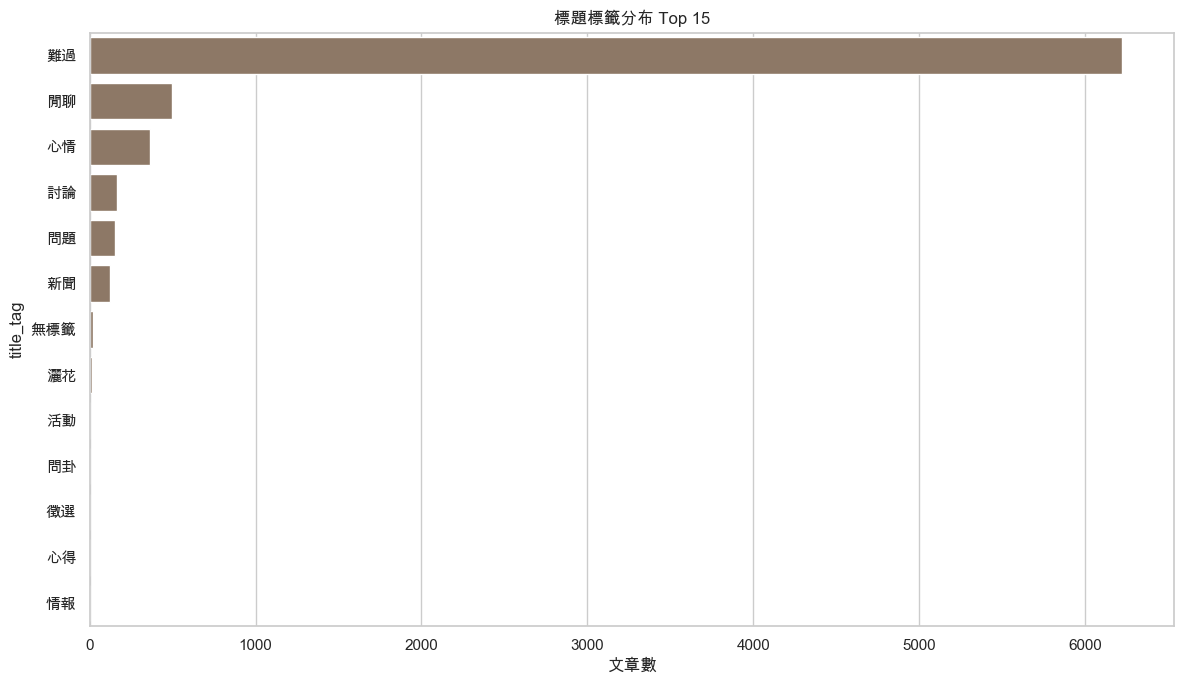

In [18]:
# 2-8 繪製標題標籤分布圖

plot_horizontal_bar(
    data=title_tag_counts_df.head(15),
    x_col="count",
    y_col="title_tag",
    title="標題標籤分布 Top 15",
    xlabel="文章數",
    ylabel="title_tag",
    color="#937860",
)
print("圖 2-8 標題標籤分布圖")
plt.show()


### 補充：主分析樣本與核心樣本定義

這一段對應課堂中的**資料清理與樣本篩選**。
為了避免新聞、轉貼或回文把結果帶偏，本研究保留三層樣本：
- `df_all`：全樣本，用於資料描述。
- `df_main_loose`：較寬鬆的主分析樣本。
- `df_main_core`：核心樣本，後續主分析以此為主。

`df_main_core` 的條件為：
1. `title_tag` 僅保留「難過」與「心情」。
2. 排除回文 `Re:`。
3. 排除轉文 `Fw:`。
4. `text_length >= 50`，且長度以 `clean_content` 計算。

這樣做的目的，是把分析焦點拉回較明確的個人抒發文本，減少公共討論或資訊轉貼對結果的干擾。


表 2-9 樣本篩選結果


,sample_type,article_count,selection_rule,ratio
0,df_all,7571,全樣本,1.0000
1,df_main_loose,5571,排除回文/轉文、資訊型標籤、過短文章,0.7358
2,df_main_core,3719,僅保留[難過]/[心情]，並排除回文/轉文、過短文章、低資訊與討論噪音,0.4912


圖 2-9 樣本篩選比較圖


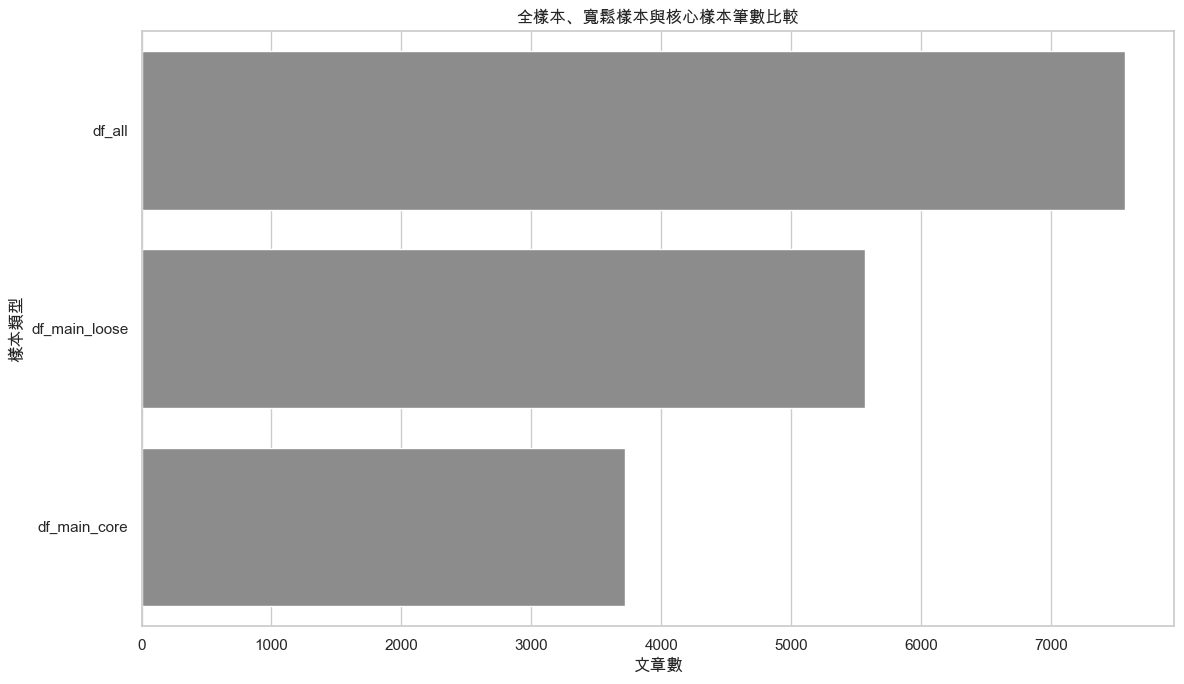

解讀：後續主分析優先使用 df_main_core，目的是把焦點放在較明確的個人抒發文本，並提前清掉低資訊標題、公共討論與明顯雜訊。


In [19]:
# 2-9 建立主分析樣本
CORE_PUBLIC_TERMS = {
    "東京奧運", "烏克蘭", "俄羅斯", "中國網軍", "女權", "覺青", "私法正義", "八卦", "政黑",
    "捐血", "病逝", "中共同路人", "福原愛", "比爾蓋茲", "宋仲基", "金秀賢", "奧運",
}
CORE_DISCUSSION_MARKERS = {
    "是不是", "如何", "怎麼", "能不能", "有沒有", "會不會", "難過的點", "怎辦", "怎釋懷", "誰害的",
}
CORE_PERSONAL_MARKERS = {
    "我", "自己", "我的", "男友", "女友", "前男友", "前女友", "老公", "老婆", "媽媽", "爸爸", "父母", "家人",
    "朋友", "同事", "主管", "老闆", "室友", "房東", "孩子", "小孩", "教授", "學姐", "寶寶", "狗", "貓",
}
CORE_TOPIC_MARKERS = {
    "工作", "上班", "下班", "薪", "房", "租", "錢", "存", "外幣", "股票", "生理期", "月經", "尿道炎", "智齒",
    "膽固醇", "生病", "手術", "受傷", "睡", "痛", "牙", "眼", "肚", "暈", "吐", "吃", "喝", "雞", "麵",
    "鍋", "碗", "盤子", "貼布", "平台", "帳號", "手機", "ipad", "iphone", "fb", "youtube", "disney", "衛生棉",
    "學生證", "信用卡", "國稅局", "教召", "車禍", "被撞", "蟑螂", "表演", "請假", "停機", "實習", "論文", "學校",
    "胖", "瘦", "髮", "白頭髮", "毛躁", "愛情", "放手", "生日", "掛號信", "疫苗", "疫情", "發票", "顯卡", "筆電",
    "劇", "居軟", "餐廳", "外送", "補助金", "狗屎", "怪人", "電線", "火災",
}
CORE_GENERIC_NOISE_TERMS = {
    "會心一笑", "昨天發生一件事", "困擾好久的事", "心裡有好多的", "1個人", "2021年要結束了",
    "明天是星期日了欸", "昨天女生", "來的都正妹", "馬太效應", "非常難過徵求搞笑圖貓圖",
}

def title_contains_any(title_text, keyword_set):
    normalized_title = str(title_text or "").strip().lower()
    return any(keyword.lower() in normalized_title for keyword in keyword_set)

def series_contains_any(text_series, keyword_set):
    normalized_series = text_series.fillna("").astype(str).str.strip().str.lower()
    return normalized_series.apply(lambda value: title_contains_any(value, keyword_set))

def annotate_core_sample_flags(input_df):
    annotated_df = input_df.copy()
    normalized_title = annotated_df["clean_title_for_analysis"].fillna("").astype(str).str.strip().str.lower()
    text_length = pd.to_numeric(annotated_df["text_length"], errors="coerce").fillna(0)

    has_personal_signal = series_contains_any(normalized_title, CORE_PERSONAL_MARKERS)
    has_topic_signal = series_contains_any(normalized_title, CORE_TOPIC_MARKERS)
    has_public_signal = series_contains_any(normalized_title, CORE_PUBLIC_TERMS)
    has_discussion_signal = (
        series_contains_any(normalized_title, CORE_DISCUSSION_MARKERS)
        | normalized_title.str.contains(r"[?？]", regex=True)
    )
    is_generic_emotion_title = (
        series_contains_any(normalized_title, CORE_GENERIC_NOISE_TERMS)
        | normalized_title.str.contains(r"^.{0,6}$", regex=True)
        | normalized_title.str.contains(r"嗚嗚|啊啊啊", regex=True)
    )

    annotated_df["has_personal_signal"] = has_personal_signal
    annotated_df["has_topic_signal"] = has_topic_signal
    annotated_df["has_public_signal"] = has_public_signal
    annotated_df["has_discussion_signal"] = has_discussion_signal
    annotated_df["is_generic_emotion_title"] = is_generic_emotion_title
    annotated_df["is_core_noise"] = (
        has_public_signal
        | ((~has_personal_signal) & (~has_topic_signal) & (text_length < 140) & (is_generic_emotion_title | has_discussion_signal))
        | ((~has_personal_signal) & (~has_topic_signal) & (text_length < 70))
    )
    return annotated_df

min_text_length = 50
loose_excluded_title_tags = {"新聞", "活動", "徵選", "情報", "問卦"}
core_title_tags = {"難過", "心情"}

df_all = df.copy()
df_all["is_forward"] = df_all["artTitle"].str.contains(r"^\s*Fw:", case=False, na=False)
df_all = annotate_core_sample_flags(df_all)

df_main_loose = df_all[
    (df_all["text_length"] >= min_text_length)
    & (~df_all["is_reply"])
    & (~df_all["is_forward"])
    & (~df_all["title_tag"].isin(loose_excluded_title_tags))
].copy()

df_main_core = df_all[
    (df_all["text_length"] >= min_text_length)
    & (~df_all["is_reply"])
    & (~df_all["is_forward"])
    & (df_all["title_tag"].isin(core_title_tags))
    & (~df_all["is_core_noise"])
].copy()

df_main = df_main_loose.copy()

sample_comparison_df = pd.DataFrame(
    {
        "sample_type": ["df_all", "df_main_loose", "df_main_core"],
        "article_count": [len(df_all), len(df_main_loose), len(df_main_core)],
        "selection_rule": [
            "全樣本",
            "排除回文/轉文、資訊型標籤、過短文章",
            "僅保留[難過]/[心情]，並排除回文/轉文、過短文章、低資訊與討論噪音",
        ],
    }
)
sample_comparison_df["ratio"] = (sample_comparison_df["article_count"] / len(df_all)).round(4)

print("表 2-9 樣本篩選結果")
display(sample_comparison_df)

plot_horizontal_bar(
    data=sample_comparison_df,
    x_col="article_count",
    y_col="sample_type",
    title="全樣本、寬鬆樣本與核心樣本筆數比較",
    xlabel="文章數",
    ylabel="樣本類型",
    color="#8C8C8C",
)
print("圖 2-9 樣本篩選比較圖")
plt.show()

df_main_core.to_csv(
    results_dir / "main_analysis_articles_core.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "解讀：後續主分析優先使用 df_main_core，"
    "目的是把焦點放在較明確的個人抒發文本，並提前清掉低資訊標題、公共討論與明顯雜訊。"
)

df = df_main_core.copy()


## 3. 斷句

雖然本研究主體以文章層級為主，但保留句子層級資料有兩個好處：
1. 後續可以回頭抽取更具代表性的句子，而不只展示整篇文章。
2. 可以補強主題解讀，讓「在難過什麼」的答案更貼近原始文本脈絡。

若文章沒有明顯標點，函式仍會保留原始文字，不讓程式因格式不規則而中斷。


In [20]:
# 3-1 建立斷句函式與句子欄位

def split_sentences(text):
    """
    以常見中文標點與換行進行斷句。
    """
    if pd.isna(text):
        return []

    text = str(text).strip()
    if not text:
        return []

    sentences = re.split(r"[。\.！？!?；;:\n]+", text)
    sentences = [sentence.strip() for sentence in sentences if sentence.strip()]

    if not sentences:
        return [text]
    return sentences


print_step_start("3-1", "建立 sentences 欄位")
df["sentences"] = apply_with_progress(df["clean_content"], split_sentences, "3-1 split_sentences")
print_step_end("3-1", "建立 sentences 欄位")
print("提醒：這裡的 sentences 只來自文章內文，不包含標題，避免關鍵句分析被標題帶偏。")



步驟 3-1：建立 sentences 欄位


3-1 split_sentences:   0%|          | 0/3719 [00:00<?, ?it/s]

[完成] 3-1 建立 sentences 欄位

提醒：這裡的 sentences 只來自文章內文，不包含標題，避免關鍵句分析被標題帶偏。


In [21]:
# 3-2 顯示斷句示例

sentence_examples = df.loc[df["sentences"].str.len() > 0, ["artTitle", "sentences"]].head(3).copy()
sentence_examples["sentence_preview"] = sentence_examples["sentences"].apply(lambda values: values[:8])

print("表 3-2 斷句示例")
display(sentence_examples[["artTitle", "sentence_preview"]])



表 3-2 斷句示例


,artTitle,sentence_preview
1,[難過]陽台又淹水了,"[大家, 早安,我芙尼, 大概五點的時候我被一陣電鈴聲吵醒,, 門一打開發現是樓下的鄰居,,..."
5,[難過]插隊的人很不ok欸（文長慎入）,"[各位大大新年快樂, 不好意思,2021年才剛開始, 我卻忍不住上來抒發一下自己心情, 除了..."
8,[心情]男女真的不平等唉唉唉唉唉,"[那個台劇未來媽媽, 劇中劉品言工作能力佳事業有成, 才34歲又6個月就開始擔心卵子品質而想..."


## 4. 斷詞、自訂詞典與停用字

這一段是文字探勘的核心前處理。
為了更接近「大家到底在為什麼事情難過」，這裡不只做全文斷詞，也會把**標題詞**與**內文詞**分開保留。

這樣做有三個好處：
- 詞頻分析可以直接觀察較乾淨的全文語彙。
- 主題分類時可以對標題加權，避免文章被大量敘事動詞帶偏。
- 後續可以分別回看「標題在說什麼」與「內文真正展開了什麼事件」。


In [22]:
# 4-1 載入自訂詞典

custom_words = sorted(
    {
        "分手", "失戀", "前任", "復合", "被甩", "被分手", "失戀中",
        "曖昧", "告白", "被拒", "拒絕", "暈船", "單戀", "追求",
        "男友", "女友", "伴侶", "另一半", "老公", "老婆", "先生", "太太",
        "吵架", "冷戰", "冷暴力", "爭執", "冷淡", "不理我", "已讀不回", "沒安全感", "不被愛", "不被珍惜", "沒結果",
        "外遇", "劈腿", "出軌", "偷吃", "小三", "約炮", "偷約", "背叛",
        "主管", "上司", "老闆", "責罵", "壓榨", "職場霸凌", "被罵", "被電", "慣老闆",
        "同事", "職場", "合作", "同部門", "辦公室", "同team",
        "離職", "轉職", "面試", "求職", "錄取", "履歷", "試用期", "工作機會", "待業", "offer",
        "加班", "工時", "薪水", "工作", "上班", "責任制", "爆肝", "值班", "下班", "薪資", "年薪", "分紅", "年終", "加薪", "升遷", "升職", "職涯", "科技業",
        "媽媽", "爸爸", "爸媽", "父母", "家人", "家庭", "控制", "干涉", "情勒", "情緒勒索", "偏心", "家暴", "決裂", "斷絕", "切割",
        "手足", "姊姊", "哥哥", "弟弟", "妹妹", "兄弟姊妹",
        "婚後", "婆家", "公婆", "媳婦", "岳家", "岳母", "結婚", "婚姻", "婆婆", "公公", "婆媳",
        "小孩", "孩子", "育兒", "照顧", "托嬰", "懷孕", "生小孩", "帶小孩",
        "朋友", "閨蜜", "疏遠", "失聯", "漸行漸遠", "絕交", "翻臉", "疏離",
        "排擠", "邊緣", "冷落", "霸凌", "孤立", "沒人理",
        "孤單", "孤獨", "社交", "沒朋友", "寂寞", "邊緣人",
        "做人失敗", "沒人喜歡", "人緣差", "不被需要", "覺得自己不好", "很爛", "自我懷疑",
        "焦慮", "不安", "害怕", "擔心", "恐慌", "緊張",
        "憂鬱", "低落", "難受", "提不起勁", "空虛", "沮喪",
        "沒用", "失敗", "自卑", "討厭自己", "不值得", "自責",
        "壓力", "崩潰", "痛苦", "無助", "委屈", "心累", "喘不過氣",
        "生理期", "經期", "月經", "經痛",
        "失眠", "頭痛", "睡不著", "偏頭痛",
        "生病", "就醫", "醫生", "醫院", "身體", "住院", "開刀", "病痛", "胸悶", "身心科", "憂鬱症", "恐慌症", "自律神經", "發燒", "拉肚子", "腹瀉", "味覺", "暈眩", "頭暈", "疲勞", "體力", "不舒服", "症狀",
        "租屋", "房租", "租金", "金錢", "沒錢", "存款", "欠錢", "經濟壓力", "退費", "退款", "訂金", "費用", "價錢", "價格", "漲價", "便宜", "付款", "匯款", "刷卡", "店家", "客服",
        "搬家", "租房", "租約", "漏水", "鄰居", "房東", "房子", "房間", "客廳", "冷氣", "套房", "公寓", "住處",
        "寵物", "狗狗", "貓咪", "毛孩", "離世", "過世", "安樂", "走了", "離開了", "當天使", "火化", "失去牠",
        "考試", "研究所", "學測", "期末", "重考", "落榜",
        "Spotify", "spotify", "YouTube", "youtube", "iPhone", "iphone", "Android", "android", "淘寶", "蝦皮", "平台", "app", "軟體", "系統", "網購",
        "支持", "鼓勵", "陪伴", "安慰", "療癒",
    }
)

for word in custom_words:
    jieba.add_word(word)

print(f"已加入自訂詞典，共 {len(custom_words)} 個詞。")


Building prefix dict from the default dictionary ...


Loading model from cache /var/folders/0x/f7rgr96j42bfb8yq04lhwm9r0000gn/T/jieba.cache


Loading model cost 0.876 seconds.


Prefix dict has been built successfully.


已加入自訂詞典，共 279 個詞。


In [23]:
# 4-2 停用字、斷詞、詞性標記與難過句擷取

general_stopwords = {
    "的", "了", "和", "是", "我", "你", "他", "她", "它", "我們", "你們", "他們",
    "自己", "真的", "就是", "這樣", "那樣", "一個", "一些", "一下", "不是", "因為",
    "所以", "如果", "然後", "但是", "而且", "可以", "還是", "沒有", "有點", "知道",
    "覺得", "可能", "應該", "已經", "非常", "最近", "今天", "昨天", "現在", "時候",
    "東西", "事情", "問題", "什麼", "怎麼", "這個", "那個", "一樣", "一點", "很多",
    "一直", "還有", "只是", "自己", "我們家", "你們家"
}

ptt_stopwords = {
    "ptt", "womentalk", "jptt", "發信站", "批踢踢", "文章", "板友", "大家", "有人",
    "女生", "女孩", "男生", "哈哈", "哈哈哈", "qq", "qqq", "xd", "qaq", "一下下",
    "這篇", "標題", "原po", "原poo", "推文", "留言", "感覺", "好像", "就是說", "一下子",
    "好不好", "是不是", "re", "fw", "sent", "from", "新聞", "閒聊",
    "討論", "本文", "如題", "台灣", "my", "啊啊啊", "真的很"
}

analysis_noise_words = {
    "如題", "台灣", "結果", "直接", "看到", "發現", "開始", "不會", "不要", "這麼",
    "只是", "一直", "突然", "原來", "好像", "真的很", "一下子"
}
stopwords = general_stopwords | ptt_stopwords
english_stopwords_lower = {word.lower() for word in stopwords if re.search(r"[A-Za-z]", word)}
analysis_noise_words_lower = {word.lower() for word in analysis_noise_words if re.search(r"[A-Za-z]", word)}
seed_words = {"難過"}


def is_stopword(word):
    if word in stopwords:
        return True
    if word.lower() in english_stopwords_lower:
        return True
    return False


def is_analysis_noise(word):
    if word in analysis_noise_words:
        return True
    if word.lower() in analysis_noise_words_lower:
        return True
    return False


def normalize_token(token):
    token = token.strip()
    if re.fullmatch(r"[A-Za-z][A-Za-z0-9_+.-]*", token):
        return token.lower()
    return token


def raw_tokenize(text):
    if pd.isna(text):
        return []

    text = str(text).strip()
    if not text:
        return []

    tokens = jieba.lcut(text)
    return [normalize_token(token) for token in tokens if token.strip()]


def tokenize(text):
    raw_tokens = raw_tokenize(text)
    clean_tokens = []

    for token in raw_tokens:
        if len(token) < 2:
            continue
        if is_stopword(token):
            continue
        if re.fullmatch(r"\d+", token):
            continue
        if re.fullmatch(r"[\W_]+", token):
            continue
        clean_tokens.append(token)

    return clean_tokens


def clean_tokens_for_analysis(tokens):
    return [
        token
        for token in tokens
        if token not in seed_words and not is_analysis_noise(token)
    ]


def pos_tokenize(text):
    if pd.isna(text):
        return []

    text = str(text).strip()
    if not text:
        return []

    tagged_tokens = []
    for word, flag in pseg.cut(text):
        word = normalize_token(word)
        if not word:
            continue
        if len(word) < 2:
            continue
        if is_stopword(word):
            continue
        if re.fullmatch(r"\d+", word):
            continue
        if re.fullmatch(r"[\W_]+", word):
            continue
        tagged_tokens.append((word, flag))
    return tagged_tokens


def filter_pos_tokens(pos_tokens, keep_prefixes):
    return [
        word
        for word, flag in pos_tokens
        if any(flag.startswith(prefix) for prefix in keep_prefixes)
    ]


def build_top_word_table(tokens, top_n=20, word_col="word"):
    return pd.DataFrame(Counter(tokens).most_common(top_n), columns=[word_col, "count"])


print_step_start("4-2", "建立 title/content tokens、分析 tokens、POS 與 sad_sentences")
df["title_raw_tokens"] = apply_with_progress(df["clean_title_for_analysis"], raw_tokenize, "4-2 title_raw_tokens")
df["content_raw_tokens"] = apply_with_progress(df["clean_content"], raw_tokenize, "4-2 content_raw_tokens")
df["raw_tokens"] = apply_with_progress(df["analysis_text"], raw_tokenize, "4-2 raw_tokenize")

df["title_tokens"] = apply_with_progress(df["clean_title_for_analysis"], tokenize, "4-2 title_tokens")
df["content_tokens"] = apply_with_progress(df["clean_content"], tokenize, "4-2 content_tokens")
df["tokens"] = apply_with_progress(df["analysis_text"], tokenize, "4-2 tokenize")

df["title_tokens_clean"] = apply_with_progress(df["title_tokens"], clean_tokens_for_analysis, "4-2 title_tokens_clean")
df["content_tokens_clean"] = apply_with_progress(df["content_tokens"], clean_tokens_for_analysis, "4-2 content_tokens_clean")
df["tokens_no_seed"] = apply_with_progress(
    df["tokens"],
    lambda tokens: [token for token in tokens if token not in seed_words],
    "4-2 tokens_no_seed",
)
df["tokens_clean_for_analysis"] = apply_with_progress(
    df["tokens_no_seed"],
    clean_tokens_for_analysis,
    "4-2 tokens_clean_for_analysis",
)

df["pos_tokens"] = apply_with_progress(df["analysis_text"], pos_tokenize, "4-2 pos_tokenize")
df["noun_tokens"] = df["pos_tokens"].apply(lambda values: filter_pos_tokens(values, {"n"}))
df["verb_tokens"] = df["pos_tokens"].apply(lambda values: filter_pos_tokens(values, {"v"}))
df["adj_tokens"] = df["pos_tokens"].apply(lambda values: filter_pos_tokens(values, {"a"}))

df["noun_tokens_clean"] = apply_with_progress(df["noun_tokens"], clean_tokens_for_analysis, "4-2 noun_tokens_clean")
df["verb_tokens_clean"] = apply_with_progress(df["verb_tokens"], clean_tokens_for_analysis, "4-2 verb_tokens_clean")
df["adj_tokens_clean"] = apply_with_progress(df["adj_tokens"], clean_tokens_for_analysis, "4-2 adj_tokens_clean")

df["sad_sentences"] = apply_with_progress(
    df["sentences"],
    lambda values: [sentence for sentence in values if "難過" in sentence],
    "4-2 sad_sentences",
)
print_step_end("4-2", "建立 title/content tokens、分析 tokens、POS 與 sad_sentences")

print("已完成：停用字設定、標題/內文分開斷詞、詞性標記、難過句擷取")
print(f"停用字總數：{len(stopwords)}")
print("提醒：高頻詞仍會保留，但後續解讀會優先看名詞與主題分類。")



步驟 4-2：建立 title/content tokens、分析 tokens、POS 與 sad_sentences


4-2 title_raw_tokens:   0%|          | 0/3719 [00:00<?, ?it/s]

4-2 content_raw_tokens:   0%|          | 0/3719 [00:00<?, ?it/s]

4-2 raw_tokenize:   0%|          | 0/3719 [00:00<?, ?it/s]

4-2 title_tokens:   0%|          | 0/3719 [00:00<?, ?it/s]

...

4-2 noun_tokens_clean:   0%|          | 0/3719 [00:00<?, ?it/s]

4-2 verb_tokens_clean:   0%|          | 0/3719 [00:00<?, ?it/s]

4-2 adj_tokens_clean:   0%|          | 0/3719 [00:00<?, ?it/s]

4-2 sad_sentences:   0%|          | 0/3719 [00:00<?, ?it/s]

[完成] 4-2 建立 title/content tokens、分析 tokens、POS 與 sad_sentences

已完成：停用字設定、標題/內文分開斷詞、詞性標記、難過句擷取
停用字總數：101
提醒：高頻詞仍會保留，但後續解讀會優先看名詞與主題分類。


In [24]:
# 4-3 顯示斷詞示例

token_examples = df.loc[
    df["analysis_text"].str.len() > 0,
    ["artTitle", "title_tokens_clean", "content_tokens_clean", "tokens_clean_for_analysis"],
].head(3).copy()
token_examples["title_tokens_preview"] = token_examples["title_tokens_clean"].apply(lambda values: values[:12])
token_examples["content_tokens_preview"] = token_examples["content_tokens_clean"].apply(lambda values: values[:15])
token_examples["analysis_tokens_preview"] = token_examples["tokens_clean_for_analysis"].apply(lambda values: values[:15])

print("表 4-3 標題與內文斷詞示例")
display(
    token_examples[
        ["artTitle", "title_tokens_preview", "content_tokens_preview", "analysis_tokens_preview"]
    ]
)


表 4-3 標題與內文斷詞示例


,artTitle,title_tokens_preview,content_tokens_preview,analysis_tokens_preview
1,[難過]陽台又淹水了,"[陽台, 淹水]","[早安, 芙尼, 大概, 五點, 一陣, 電鈴聲, 吵醒, 一打, 開發現, 鄰居, 她問,...","[陽台, 淹水, 早安, 芙尼, 大概, 五點, 一陣, 電鈴聲, 吵醒, 一打, 開發現,..."
5,[難過]插隊的人很不ok欸（文長慎入）,"[插隊, ok, 文長, 慎入]","[各位, 大大, 新年, 快樂, 不好意思, 剛開始, 忍不住, 上來, 抒發, 心情, 除...","[插隊, ok, 文長, 慎入, 各位, 大大, 新年, 快樂, 不好意思, 剛開始, 忍不..."
8,[心情]男女真的不平等唉唉唉唉唉,"[男女, 平等]","[台劇, 未來, 媽媽, 劇中, 劉品, 工作, 能力, 佳事業, 有成, 擔心, 卵子, ...","[男女, 平等, 台劇, 未來, 媽媽, 劇中, 劉品, 工作, 能力, 佳事業, 有成, ..."


In [25]:
# 4-4 比較初步斷詞與清理後斷詞 top20

all_raw_tokens = [token for tokens in df["raw_tokens"] for token in tokens]
all_clean_tokens = [token for tokens in df["tokens"] for token in tokens]
all_tokens_no_seed = [token for tokens in df["tokens_no_seed"] for token in tokens]
all_tokens_clean_for_analysis = [token for tokens in df["tokens_clean_for_analysis"] for token in tokens]

raw_top20_df = pd.DataFrame(Counter(all_raw_tokens).most_common(20), columns=["word", "raw_count"])
analysis_top20_df = pd.DataFrame(
    Counter(all_tokens_clean_for_analysis).most_common(20),
    columns=["word", "analysis_count"],
)

top20_compare_df = pd.concat([raw_top20_df, analysis_top20_df], axis=1)
print("表 4-4 斷詞整理前後比較（節錄前 10 名）")
display(top20_compare_df.head(10))

print("解讀：加入停用字、排除 seed word 與敘事型雜訊詞後，留下的高頻詞更接近生活事件，而不是泛用敘事動詞。")


表 4-4 斷詞整理前後比較（節錄前 10 名）


,word,raw_count,word,analysis_count
0,的,19406,工作,934
1,",",16211,朋友,819
2,我,14431,同事,662
3,了,8537,媽媽,523
4,是,6401,上班,505
5,有,5010,時間,499
6,也,4863,一起,489
7,都,4773,不能,489
8,在,4604,希望,488
9,就,4361,公司,481


解讀：加入停用字、排除 seed word 與敘事型雜訊詞後，留下的高頻詞更接近生活事件，而不是泛用敘事動詞。


### 補充：詞性標記與關鍵句輔助分析

課堂中除了全文斷詞，也強調可以用詞性與關鍵句幫助解讀。
這裡會保留名詞、動詞、形容詞，但報告主結論會優先看**名詞**，因為名詞更能回答「大家是在為什麼事情難過」。

含「難過」句子的分析則扮演輔助角色：
- 名詞幫助辨識人物、關係與事件對象。
- 動詞幫助理解事件動作。
- 形容詞幫助補充情緒狀態。


In [26]:
# 4-5 主分析樣本詞性標記
all_noun_tokens = [token for tokens in df["noun_tokens_clean"] for token in tokens]
all_verb_tokens = [token for tokens in df["verb_tokens_clean"] for token in tokens]
all_adj_tokens = [token for tokens in df["adj_tokens_clean"] for token in tokens]

noun_top20_df = build_top_word_table(all_noun_tokens, top_n=20, word_col="noun")
verb_top10_df = build_top_word_table(all_verb_tokens, top_n=10, word_col="verb")
adj_top10_df = build_top_word_table(all_adj_tokens, top_n=10, word_col="adjective")

pos_summary_preview_df = pd.concat(
    [
        noun_top20_df.head(10).reset_index(drop=True),
        verb_top10_df.reset_index(drop=True),
        adj_top10_df.reset_index(drop=True),
    ],
    axis=1,
)

print("表 4-5 詞性 Top10 摘要")
display(pos_summary_preview_df)

noun_top20_df.to_csv(results_dir / "noun_top20.csv", index=False, encoding="utf-8-sig")

print("解讀：名詞最適合拿來辨識困擾對象與事件，動詞與形容詞則作為輔助解讀。")


表 4-5 詞性 Top10 摘要


,noun,count,verb,count,adjective,count
0,朋友,819,工作,934,完全,378
1,同事,662,上班,505,根本,341
2,時間,535,不能,489,努力,236
3,公司,481,希望,488,平常,189
4,回家,394,喜歡,465,嚴重,141
5,小孩,384,只能,433,痛苦,141
6,家人,368,想到,429,一般,137
7,男友,336,不想,409,容易,124
8,人生,314,不到,348,很大,110
9,心情,294,起來,345,不錯,110


解讀：名詞最適合拿來辨識困擾對象與事件，動詞與形容詞則作為輔助解讀。


In [27]:
# 4-6 含「難過」句子分析
print_step_start("4-6", "分析含『難過』句子的詞性分布")
sad_sentence_list = [sentence for values in df["sad_sentences"] for sentence in values]
sad_sentence_pos_tokens = [
    pos_tokenize(sentence)
    for sentence in iter_with_progress(sad_sentence_list, "4-6 sad_sentence_pos")
]

sad_sentence_nouns = []
sad_sentence_verbs = []
sad_sentence_adjs = []
for values in sad_sentence_pos_tokens:
    sad_sentence_nouns.extend(clean_tokens_for_analysis(filter_pos_tokens(values, {"n"})))
    sad_sentence_verbs.extend(clean_tokens_for_analysis(filter_pos_tokens(values, {"v"})))
    sad_sentence_adjs.extend(clean_tokens_for_analysis(filter_pos_tokens(values, {"a"})))

sad_noun_top20_df = build_top_word_table(sad_sentence_nouns, top_n=20, word_col="noun")
sad_verb_top20_df = build_top_word_table(sad_sentence_verbs, top_n=20, word_col="verb")
sad_adj_top20_df = build_top_word_table(sad_sentence_adjs, top_n=20, word_col="adjective")

sad_pos_preview_df = pd.concat(
    [
        sad_noun_top20_df.head(10).reset_index(drop=True),
        sad_verb_top20_df.head(10).reset_index(drop=True),
        sad_adj_top20_df.head(10).reset_index(drop=True),
    ],
    axis=1,
)

print("表 4-6 含『難過』句子的詞性 Top10 摘要")
display(sad_pos_preview_df)
print_step_end("4-6", "分析含『難過』句子的詞性分布")

print(
    "解讀：這一段直接對應課堂中『先鎖定含關鍵字句子，再抽取重要詞』的做法，"
    "能更具體回答使用者是在因為哪些對象與事件而感到難過。"
)



步驟 4-6：分析含『難過』句子的詞性分布


4-6 sad_sentence_pos:   0%|          | 0/1081 [00:00<?, ?it/s]

表 4-6 含『難過』句子的詞性 Top10 摘要


,noun,count,verb,count,adjective,count
0,心情,23,想到,32,完全,7
1,朋友,16,感到,14,痛苦,6
2,情緒,9,聽到,12,心疼,4
3,男友,7,超難,11,很痛,4
4,我心,7,不能,11,自由,3
5,傷心,7,不到,10,悠樂,2
6,日子,7,不想,9,珍惜,2
7,家人,6,出來,9,平常,2
8,時間,6,喜歡,9,快樂,2
9,內心,6,生活,9,一般,2


[完成] 4-6 分析含『難過』句子的詞性分布

解讀：這一段直接對應課堂中『先鎖定含關鍵字句子，再抽取重要詞』的做法，能更具體回答使用者是在因為哪些對象與事件而感到難過。


### 延伸：CKIP NER

這一段屬於延伸分析，目的不是取代前面的 `jieba` 主線，而是用 CKIP 的 **NER（Named Entity Recognition，命名實體辨識）** 補充辨識文本中的專名實體，例如人物、地名、組織、品牌與產品。

這段分析的用途有三個：
- 補充高頻名詞之外的專名資訊。
- 協助辨識事件涉及的公司、平台、品牌、地點或人物。
- 作為後續主題解讀與代表文章閱讀的輔助證據。

若環境未安裝 `ckiptagger`、尚未準備模型，或像目前這台 `macOS x86_64` 機器一樣存在 CPU 相容性問題，這一段都會保留架構並清楚提示，不會讓 notebook 中斷。


In [28]:
# 4-7 檢查 CKIP 環境並建立 NER 輸入文本

if "doc_id" not in df.columns:
    df = df.reset_index(drop=True).copy()
    df["doc_id"] = [f"D{idx + 1:05d}" for idx in range(len(df))]

import platform

ckip_candidate_dirs = [
    Path.cwd() / "resources" / "models" / "ckiptagger_data",
    Path.cwd() / "ckiptagger_data",
    Path.cwd() / "data",
    Path.cwd() / "models" / "ckiptagger_data",
    Path.cwd() / "SMA_2026S-main" / "ckiptagger_data",
]
ckip_model_dir = next((path for path in ckip_candidate_dirs if path.exists()), None)
ckip_ner_max_docs = None  # 若要先測試，可改成 100 或 200。
ckip_runtime_enabled = True
ckip_runtime_reason = "可執行"

if platform.system() == "Darwin" and platform.machine() == "x86_64":
    ckip_runtime_enabled = False
    ckip_runtime_reason = "本機 macOS x86_64 實測執行 ckiptagger 會觸發 x2APIC CPU 相容性錯誤，為避免 notebook kernel 中斷，預設略過 CKIP NER。"


def build_ckip_ner_input(row):
    parts = []

    title_text = str(row.get("clean_title_for_analysis", "")).strip()
    if title_text:
        parts.append(title_text)

    sad_sentences = row.get("sad_sentences", [])
    if isinstance(sad_sentences, list) and sad_sentences:
        parts.extend([str(sentence).strip() for sentence in sad_sentences[:2] if str(sentence).strip()])
    else:
        sentences = row.get("sentences", [])
        if isinstance(sentences, list):
            parts.extend([str(sentence).strip() for sentence in sentences[:2] if str(sentence).strip()])

    deduped_parts = []
    seen_parts = set()
    for part in parts:
        if part and part not in seen_parts:
            seen_parts.add(part)
            deduped_parts.append(part)

    return "。".join(deduped_parts)[:250]


df["ckip_ner_input_text"] = df.apply(build_ckip_ner_input, axis=1)
df["ckip_ner_entities"] = ""
df["ckip_ner_types"] = ""

ckip_ner_status_df = pd.DataFrame(
    {
        "item": ["ckiptagger 套件", "CKIP 模型資料夾", "CKIP 執行狀態", "核心樣本筆數", "NER 最大處理筆數"],
        "status": [
            "可用" if ckiptagger_available else "未安裝",
            str(ckip_model_dir) if ckip_model_dir is not None else "未找到",
            ckip_runtime_reason,
            len(df),
            "全部" if ckip_ner_max_docs is None else ckip_ner_max_docs,
        ],
    }
)

print("表 4-7 CKIP NER 環境檢查")
display(ckip_ner_status_df)

if not ckiptagger_available:
    print("提醒：目前環境未安裝 `ckiptagger`，因此 CKIP NER 暫時不會執行。")
elif ckip_model_dir is None:
    print("提醒：已偵測到 CKIP 章節，但找不到模型資料夾。請先把模型放到 notebook 規劃的 models 目錄後再執行。")
elif not ckip_runtime_enabled:
    print(f"提醒：{ckip_runtime_reason}")
else:
    print(f"已找到 CKIP 模型資料夾：{ckip_model_dir}")


表 4-7 CKIP NER 環境檢查


,item,status
0,ckiptagger 套件,可用
1,CKIP 模型資料夾,/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/resou...
2,CKIP 執行狀態,本機 macOS x86_64 實測執行 ckiptagger 會觸發 x2APIC CPU...
3,核心樣本筆數,3719
4,NER 最大處理筆數,全部


提醒：本機 macOS x86_64 實測執行 ckiptagger 會觸發 x2APIC CPU 相容性錯誤，為避免 notebook kernel 中斷，預設略過 CKIP NER。


In [29]:
# 4-8 執行 CKIP NER 並整理實體結果

ckip_ner_entity_df = pd.DataFrame(columns=["doc_id", "artTitle", "entity_text", "entity_type", "entity_index", "ckip_ner_input_text"])
ckip_ner_type_counts_df = pd.DataFrame(columns=["entity_type", "entity_count"])
ckip_ner_top_entities_df = pd.DataFrame(columns=["entity_text", "entity_type", "entity_count", "doc_count"])


def unpack_ckip_entity(entity):
    if hasattr(entity, "word"):
        return str(entity.word), str(getattr(entity, "ner", "")), getattr(entity, "idx", "")

    if isinstance(entity, (list, tuple)):
        if len(entity) >= 3 and isinstance(entity[0], str):
            return str(entity[0]), str(entity[1]), entity[2]
        if len(entity) >= 4:
            return str(entity[3]), str(entity[2]), (entity[0], entity[1])

    return str(entity), "", ""


if not ckiptagger_available:
    print("提醒：未安裝 `ckiptagger`，略過 CKIP NER。")
elif ckip_model_dir is None:
    print("提醒：找不到 CKIP 模型資料夾，略過 CKIP NER。")
elif not ckip_runtime_enabled:
    print(f"提醒：{ckip_runtime_reason}")
else:
    ckip_input_df = df[["doc_id", "artTitle", "ckip_ner_input_text"]].copy()
    ckip_input_df = ckip_input_df[ckip_input_df["ckip_ner_input_text"].astype(str).str.strip().ne("")].copy()

    if ckip_ner_max_docs is not None:
        ckip_input_df = ckip_input_df.head(int(ckip_ner_max_docs)).copy()

    print_step_start("4-8", "執行 CKIP NER")
    ws_driver = WS(str(ckip_model_dir))
    pos_driver = POS(str(ckip_model_dir))
    ner_driver = NER(str(ckip_model_dir))

    ckip_texts = ckip_input_df["ckip_ner_input_text"].tolist()
    ws_results = ws_driver(ckip_texts, sentence_segmentation=True)
    pos_results = pos_driver(ws_results)
    ner_results = ner_driver(ws_results, pos_results)

    entity_rows = []
    for (_, row), sentence_entities in zip(ckip_input_df.iterrows(), ner_results):
        for entity in sorted(sentence_entities, key=lambda value: str(value)):
            entity_text, entity_type, entity_index = unpack_ckip_entity(entity)
            entity_text = str(entity_text).strip()
            entity_type = str(entity_type).strip()

            if len(entity_text) < 2:
                continue

            entity_rows.append(
                {
                    "doc_id": row["doc_id"],
                    "artTitle": row["artTitle"],
                    "entity_text": entity_text,
                    "entity_type": entity_type,
                    "entity_index": str(entity_index),
                    "ckip_ner_input_text": row["ckip_ner_input_text"],
                }
            )

    ckip_ner_entity_df = pd.DataFrame(entity_rows)

    if ckip_ner_entity_df.empty:
        print("提醒：CKIP NER 已執行，但這批文本沒有辨識出可保留的實體。")
    else:
        ckip_ner_type_counts_df = (
            ckip_ner_entity_df.groupby("entity_type")
            .size()
            .reset_index(name="entity_count")
            .sort_values("entity_count", ascending=False)
        )

        ckip_ner_top_entities_df = (
            ckip_ner_entity_df.groupby(["entity_text", "entity_type"])
            .agg(entity_count=("entity_text", "size"), doc_count=("doc_id", "nunique"))
            .reset_index()
            .sort_values(["entity_count", "doc_count", "entity_text"], ascending=[False, False, True])
        )

        doc_entity_summary_df = (
            ckip_ner_entity_df.groupby("doc_id")
            .agg(
                ckip_ner_entities=("entity_text", lambda values: "、".join(pd.unique(list(values))[:10])),
                ckip_ner_types=("entity_type", lambda values: "、".join(pd.unique(list(values))[:10])),
            )
            .reset_index()
        )

        entity_map = doc_entity_summary_df.set_index("doc_id")["ckip_ner_entities"].to_dict()
        type_map = doc_entity_summary_df.set_index("doc_id")["ckip_ner_types"].to_dict()
        df["ckip_ner_entities"] = df["doc_id"].map(entity_map).fillna(df["ckip_ner_entities"])
        df["ckip_ner_types"] = df["doc_id"].map(type_map).fillna(df["ckip_ner_types"])

        print("表 4-8-1 CKIP NER 實體類型分布")
        display(ckip_ner_type_counts_df)
        print("表 4-8-2 CKIP NER 高頻實體 Top 20")
        display(ckip_ner_top_entities_df.head(20))

        ckip_ner_entity_df.to_csv(results_dir / "ckip_ner_entities.csv", index=False, encoding="utf-8-sig")
        ckip_ner_type_counts_df.to_csv(results_dir / "ckip_ner_type_counts.csv", index=False, encoding="utf-8-sig")
        ckip_ner_top_entities_df.to_csv(results_dir / "ckip_ner_top_entities.csv", index=False, encoding="utf-8-sig")
        ckip_ner_status_df.to_csv(results_dir / "ckip_ner_status.csv", index=False, encoding="utf-8-sig")

        print(
            "解讀：CKIP NER 提供的是專名實體線索，適合補充高頻名詞與主題分類；"
            "例如品牌、平台、地點、組織或人物名稱，可幫助我們更具體理解文章在指向哪些生活場景。"
        )

    print_step_end("4-8", "執行 CKIP NER")


提醒：本機 macOS x86_64 實測執行 ckiptagger 會觸發 x2APIC CPU 相容性錯誤，為避免 notebook kernel 中斷，預設略過 CKIP NER。


## 5. 高頻詞、高頻名詞與文字雲

這一段對應課堂中的**詞頻分析**，也是整份報告的第一層證據。
為了避免高頻詞被「看到、發現、開始」這類敘事動詞帶走，這裡會同時呈現：
- 全體高頻詞 Top 20。
- 高頻名詞 Top 20。
- 全體文字雲。

解讀順序建議如下：
1. 先看高頻詞，掌握語料整體輪廓。
2. 再看高頻名詞，辨識人物、關係與事件核心。
3. 最後用文字雲作為視覺摘要，但不把文字雲當成唯一證據。


In [30]:
# 5-1 建立主分析樣本高頻詞表

top_words_no_seed_df = pd.DataFrame(
    Counter(all_tokens_clean_for_analysis).most_common(20),
    columns=["word", "count"],
)

print("表 5-1 核心樣本高頻詞 Top 20")
display(top_words_no_seed_df)
print("表 5-1-2 核心樣本高頻名詞 Top 20")
display(noun_top20_df.head(20))

top_words_no_seed_df.to_csv(results_dir / "top_words_no_seed.csv", index=False, encoding="utf-8-sig")

print("解讀：高頻詞提供整體輪廓，但高頻名詞更直接指出難過貼文中的人物、關係與生活事件。")


表 5-1 核心樣本高頻詞 Top 20


,word,count
0,工作,934
1,朋友,819
2,同事,662
3,媽媽,523
4,上班,505
5,時間,499
6,一起,489
7,不能,489
8,希望,488
9,公司,481


表 5-1-2 核心樣本高頻名詞 Top 20


,noun,count
0,朋友,819
1,同事,662
2,時間,535
3,公司,481
4,回家,394
5,小孩,384
6,家人,368
7,男友,336
8,人生,314
9,心情,294


解讀：高頻詞提供整體輪廓，但高頻名詞更直接指出難過貼文中的人物、關係與生活事件。


圖 5-2 主分析樣本高頻名詞 Top 20


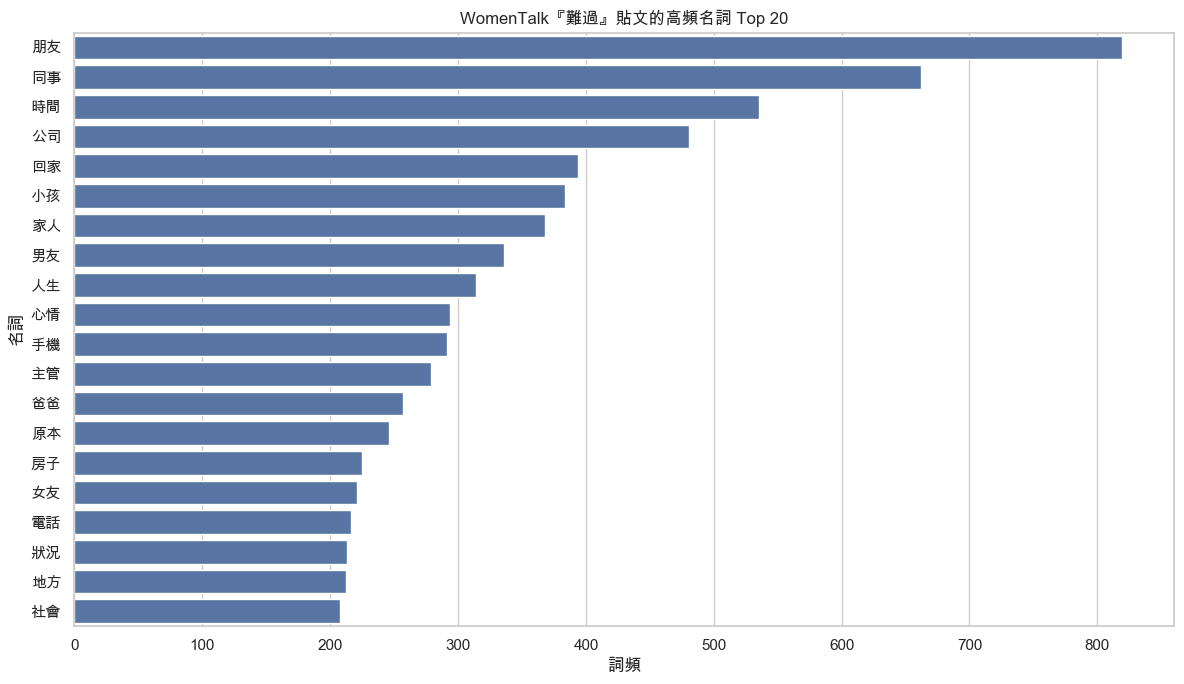

In [31]:
# 5-2 繪製高頻名詞長條圖

plot_horizontal_bar(
    data=noun_top20_df.head(20),
    x_col="count",
    y_col="noun",
    title="WomenTalk『難過』貼文的高頻名詞 Top 20",
    xlabel="詞頻",
    ylabel="名詞",
    color="#4C72B0",
)
print("圖 5-2 主分析樣本高頻名詞 Top 20")
plt.show()


圖 5-3 核心樣本文字雲


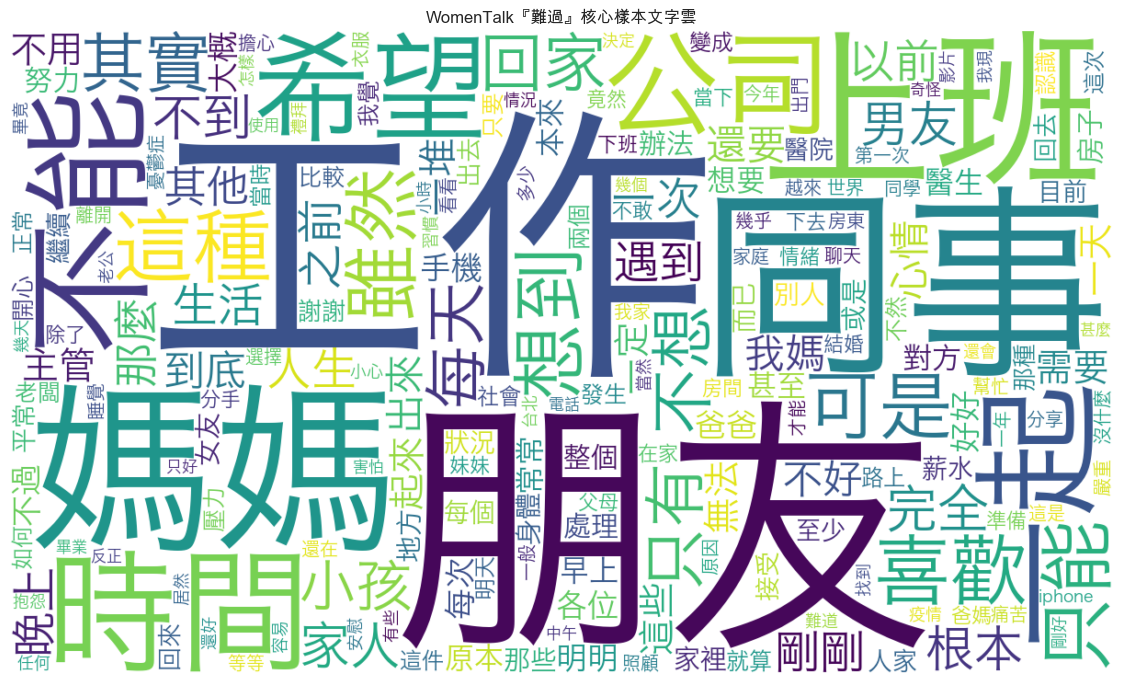

解讀：文字雲只作為輔助視覺化，真正的主結論仍應以高頻名詞、主題分類與代表文章為主。


In [32]:
# 5-3 繪製文字雲

wordcloud_counter = Counter(all_tokens_clean_for_analysis)

try:
    if wordcloud_font_path is None:
        raise FileNotFoundError("找不到中文字型檔，無法保證中文文字雲正常顯示。")

    wordcloud = WordCloud(
        width=1200,
        height=700,
        background_color="white",
        font_path=wordcloud_font_path,
        collocations=False,
    ).generate_from_frequencies(wordcloud_counter)

    plt.figure(figsize=(12, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("WomenTalk『難過』核心樣本文字雲")
    plt.tight_layout()
    print("圖 5-3 核心樣本文字雲")
    plt.show()
except Exception as error:
    print(f"文字雲產生失敗：{error}")
    print("提醒：若要正常顯示中文文字雲，請確認系統中有可用中文字型。")

print("解讀：文字雲只作為輔助視覺化，真正的主結論仍應以高頻名詞、主題分類與代表文章為主。")


## 6. 主題分類：真正的難過來源

這一段是整份報告的核心，正式回答「大家到底在難過什麼」。
做法不是只看文章碰到哪個大類關鍵字，而是先用較貼近事件原因的**二級主題**計分，再整理成單一正式欄位 `final_secondary_topic`，最後再回推 `primary_topic`。

這次分類有五個重點：
- **secondary 為主、primary 為輔**：真正回答「大家在難過什麼」時，以 `final_secondary_topic` 為正式結果。
- **標題加權**：標題命中比內文命中更高，避免事件核心被長文稀釋。
- **精準優先**：收緊 `加班工時`、`同事相處`、`生病就醫` 等過寬類別，避免硬塞。
- **候選與信心分流**：保留 `secondary_candidates`、`classification_reason` 與 `classification_confidence`，讓正式結果和檢查資訊分開。
- **中高信心優先解讀**：後續圖表、代表文章與月份回看，優先聚焦 `medium/high confidence`。

真正回答「在難過什麼」時，這一章會同時依據：
- 高頻名詞。
- `final_secondary_topic` 分布。
- 主題證據摘要表。
- 中高信心代表句與代表文章。

`primary_topic` 仍保留，但定位是高層次補充歸納，而不是主要答案。


In [33]:
# 6-1 建立分類規則並建立主題欄位
from collections import Counter

TITLE_WEIGHT_STRONG = 6
CONTENT_WEIGHT_STRONG = 2
TITLE_WEIGHT_WEAK = 2
CONTENT_WEIGHT_WEAK = 1

SECONDARY_TOPIC_RULES = {
    "分手失戀": {
        "strong": {"分手", "失戀", "前任", "前男友", "前女友", "復合", "被甩", "被分手", "放手"},
        "weak": {"想念", "單身"},
    },
    "曖昧拒絕": {
        "strong": {"曖昧", "告白", "被拒", "拒絕", "暈船", "單戀", "追求"},
        "weak": {"喜歡", "好感", "愛情"},
    },
    "伴侶衝突": {
        "strong": {"男友", "女友", "男朋友", "女朋友", "伴侶", "另一半", "老公", "老婆", "先生", "太太", "吵架", "冷戰", "冷淡", "不理我", "已讀不回"},
        "weak": {"感情", "婚姻", "吵", "分開"},
    },
    "外遇劈腿": {
        "strong": {"外遇", "劈腿", "出軌", "偷吃", "小三", "約炮", "背叛"},
        "weak": set(),
    },
    "主管壓力": {
        "strong": {"主管", "上司", "老闆", "責罵", "壓榨", "職場霸凌", "被罵", "慣老闆", "針對", "刁難"},
        "weak": {"考績", "升遷"},
    },
    "同事相處": {
        "strong": {"同事", "合作", "辦公室", "團隊", "排擠", "孤立", "小團體", "同部門", "同team", "互動"},
        "weak": {"公司", "職場", "部門"},
    },
    "離職面試": {
        "strong": {"離職", "轉職", "面試", "求職", "錄取", "履歷", "試用期", "待業", "offer", "失業"},
        "weak": {"換工作"},
    },
    "加班工時": {
        "strong": {"加班", "工時", "爆肝", "值班", "輪班", "壓榨", "責任制", "年終", "分紅", "升遷", "調薪", "派遣", "請假困難", "補班"},
        "weak": {"上班", "下班", "薪水", "薪資", "工作", "請假"},
    },
    "父母衝突": {
        "strong": {"父母", "爸媽", "媽媽", "爸爸", "控制", "干涉", "情勒", "情緒勒索", "偏心", "家暴", "長輩"},
        "weak": {"回家", "家庭"},
    },
    "手足關係": {
        "strong": {"手足", "姊姊", "哥哥", "弟弟", "妹妹", "兄弟姊妹", "弟媳"},
        "weak": set(),
    },
    "婚後家庭": {
        "strong": {"婚後", "婆家", "公婆", "媳婦", "岳家", "結婚", "婚姻", "婆婆", "公公", "婆媳"},
        "weak": {"老公", "老婆"},
    },
    "小孩照顧": {
        "strong": {"小孩", "孩子", "育兒", "照顧", "托嬰", "懷孕", "生小孩", "帶小孩", "寶寶"},
        "weak": set(),
    },
    "朋友疏遠": {
        "strong": {"閨蜜", "疏遠", "失聯", "漸行漸遠", "絕交", "翻臉", "朋友"},
        "weak": {"同學"},
    },
    "被排擠": {
        "strong": {"排擠", "邊緣", "冷落", "霸凌", "孤立", "針對"},
        "weak": set(),
    },
    "孤單社交": {
        "strong": {"孤單", "孤獨", "社交", "沒朋友", "寂寞", "邊緣人"},
        "weak": {"一個人", "自己一個人"},
    },
    "陌生人衝突": {
        "strong": {"搭訕", "尾隨", "偷拍", "性騷擾", "司機", "喇叭", "爭執", "插隊", "騷擾", "陌生人", "計程車", "捷運", "路人", "怪人"},
        "weak": {"被罵", "被兇", "小姐"},
    },
    "自我價值低落": {
        "strong": {"做人失敗", "不值得", "沒人喜歡", "自責", "不被需要", "自我懷疑", "不知足"},
        "weak": {"沒用", "失去自信"},
    },
    "焦慮不安": {
        "strong": {"焦慮", "不安", "害怕", "擔心", "恐慌", "緊張", "可怕"},
        "weak": {"煩", "煩躁"},
    },
    "憂鬱低落": {
        "strong": {"憂鬱", "低落", "提不起勁", "空虛", "沮喪", "不開心", "藍瘦"},
        "weak": {"難受", "悶", "想哭"},
    },
    "自我否定": {
        "strong": {"失敗", "自卑", "討厭自己", "走投無路", "被自己笨死"},
        "weak": {"好爛", "好廢"},
    },
    "壓力爆炸": {
        "strong": {"壓力", "崩潰", "痛苦", "無助", "委屈", "心累", "喘不過氣", "盡力了"},
        "weak": {"好累", "很累"},
    },
    "外貌身材": {
        "strong": {"胖", "瘦", "醜", "白頭髮", "髮際線", "毛躁", "身材", "禿"},
        "weak": {"外貌", "長相"},
    },
    "生理期": {
        "strong": {"生理期", "經期", "月經", "經痛"},
        "weak": set(),
    },
    "失眠頭痛": {
        "strong": {"失眠", "頭痛", "睡不著", "偏頭痛", "睡眠", "打呼", "安眠藥"},
        "weak": {"累到睡不著"},
    },
    "生病就醫": {
        "strong": {"醫生", "醫院", "看診", "住院", "開刀", "手術", "急診", "發燒", "感冒", "憂鬱症", "恐慌症", "牙醫", "智齒", "抽血", "腸胃炎", "腹瀉", "拉肚子", "尿道炎", "膽固醇", "受傷", "頭暈", "暈眩", "味覺", "健保卡"},
        "weak": {"痛", "病", "吐", "暈", "不舒服"},
    },
    "租屋金錢": {
        "strong": {"租屋", "房租", "租金", "金錢", "沒錢", "存款", "欠錢", "經濟壓力", "退款", "訂金", "費用", "價錢", "價格", "漲價", "付款", "匯款", "刷卡", "股票", "房價", "頭期款", "現金", "信用卡", "買不起"},
        "weak": {"錢", "外幣", "房", "租"},
    },
    "搬家": {
        "strong": {"搬家", "租房", "租約", "漏水", "鄰居", "房東", "房子", "房間", "客廳", "冷氣", "套房", "公寓", "住處", "淹水"},
        "weak": {"住家"},
    },
    "飲食餐飲": {
        "strong": {"早餐", "午餐", "晚餐", "飲料", "咖啡", "豆漿", "吐司", "水餃", "拉麵", "鹹粥", "春捲", "餐盒", "餐廳", "內用", "外送", "麥當勞", "雞排", "雞胸", "漢堡", "便當", "吃", "喝", "冰淇淋"},
        "weak": {"食物", "口味", "難吃"},
    },
    "商品消費": {
        "strong": {"店員", "物流", "發票", "包裝", "包包", "顯卡", "筆電", "商品", "衛生棉", "貼布", "木炭", "空氣壓縮機", "客服", "店家", "退貨", "訂單", "瑕疵", "刮痕", "買貴"},
        "weak": {"購物", "買", "賣家"},
    },
    "科技平台": {
        "strong": {"spotify", "youtube", "iphone", "android", "ipad", "fb", "facebook", "ig", "instagram", "手機", "淘寶", "蝦皮", "平台", "app", "軟體", "系統", "網購", "帳號", "logo", "蘋果", "3c", "disney"},
        "weak": {"手機殼"},
    },
    "考試": {
        "strong": {"考試", "研究所", "學測", "期末", "重考", "落榜", "論文", "教授", "延畢", "畢業", "口試", "作業", "報告", "學校", "實習", "學生證", "在學證明", "單字"},
        "weak": {"課業", "修課"},
    },
    "行政瑣事": {
        "strong": {"教召", "掛號信", "國稅局", "郵局", "請假", "表演", "停機", "停電", "證件", "證明", "國稅"},
        "weak": {"手續"},
    },
    "日常意外": {
        "strong": {"車禍", "被撞", "蟑螂", "狗屎", "打雷", "電線", "火災", "火燭", "恐嚇", "提告", "踩到", "打壞", "摔", "摔倒"},
        "weak": {"意外"},
    },
    "社會討論": {
        "strong": {"新聞", "疫情", "疫苗", "奧運", "烏克蘭", "俄羅斯", "中國網軍", "八卦", "政黑", "女權", "覺青", "私法正義", "病逝", "捐血"},
        "weak": {"社會", "網友", "媒體"},
    },
    "寵物": {
        "strong": {"寵物", "狗狗", "貓咪", "毛孩", "離世", "過世", "安樂", "走了", "離開了", "當天使", "火化", "失去牠", "狗勾"},
        "weak": {"狗", "貓"},
    },
    "親友離世": {
        "strong": {"過世", "離世", "走了", "告別式", "喪禮", "自殺"},
        "weak": {"離開"},
    },
}

SECONDARY_TO_PRIMARY = {
    "分手失戀": "感情",
    "曖昧拒絕": "感情",
    "伴侶衝突": "感情",
    "外遇劈腿": "感情",
    "主管壓力": "工作",
    "同事相處": "工作",
    "離職面試": "工作",
    "加班工時": "工作",
    "父母衝突": "家庭",
    "手足關係": "家庭",
    "婚後家庭": "家庭",
    "小孩照顧": "家庭",
    "朋友疏遠": "人際",
    "被排擠": "人際",
    "孤單社交": "人際",
    "陌生人衝突": "人際",
    "自我價值低落": "自我情緒",
    "焦慮不安": "自我情緒",
    "憂鬱低落": "自我情緒",
    "自我否定": "自我情緒",
    "壓力爆炸": "自我情緒",
    "外貌身材": "自我情緒",
    "生理期": "健康生理",
    "失眠頭痛": "健康生理",
    "生病就醫": "健康生理",
    "租屋金錢": "生活事件",
    "搬家": "生活事件",
    "飲食餐飲": "生活事件",
    "商品消費": "生活事件",
    "科技平台": "生活事件",
    "考試": "生活事件",
    "行政瑣事": "生活事件",
    "日常意外": "生活事件",
    "社會討論": "非個人抒發/雜項",
    "寵物": "生活事件",
    "親友離世": "生活事件",
}

SECONDARY_TOPIC_PRIORITY = list(SECONDARY_TOPIC_RULES.keys())
PRIMARY_TOPIC_PRIORITY = ["感情", "工作", "家庭", "人際", "自我情緒", "健康生理", "生活事件", "未明確分類", "非個人抒發/雜項"]

NON_PERSONAL_KEYWORDS = {"新聞", "報導", "記者", "警方", "社會", "影片", "快訊", "網友", "爆料", "事件"}
PERSONAL_TEXT_MARKERS = {
    "我", "自己", "我的", "我們", "男友", "女友", "前男友", "前女友", "老公", "老婆", "爸媽", "媽媽", "爸爸",
    "家人", "朋友", "同事", "主管", "老闆", "室友", "房東", "孩子", "小孩", "教授", "學姐", "寶寶",
}
PERSONAL_EXPERIENCE_HINTS = {"被", "得了", "遇到", "發生", "突然", "昨天", "今天", "剛剛", "真的", "覺得", "又", "好怕", "快到了"}
PET_TERMS = {"寵物", "狗狗", "貓咪", "毛孩", "狗勾", "狗", "貓"}
PET_LOSS_TERMS = {"離世", "過世", "安樂", "走了", "當天使", "火化", "離開了", "失去牠"}
PARTNER_TERMS = {"老公", "老婆", "男友", "女友", "男朋友", "女朋友", "另一半", "伴侶", "先生", "太太"}
AFFAIR_TERMS = {"劈腿", "外遇", "出軌", "偷吃", "約炮"}
FAMILY_FRIEND_TERMS = {
    "媽媽", "爸爸", "爸媽", "父母", "家人", "阿嬤", "阿公", "爺爺", "奶奶", "哥哥", "姊姊", "弟弟", "妹妹",
    "朋友", "閨蜜", "同學", "室友", "同事", "老師", "教授", "前男友", "前女友", "男友", "女友",
}
DEATH_TERMS = {"過世", "離世", "走了", "告別式", "喪禮", "自殺", "病逝"}
WORK_CONTEXT_TERMS = {"工作", "上班", "下班", "公司", "主管", "老闆"}
WORKLOAD_TERMS = {"加班", "工時", "爆肝", "值班", "輪班", "責任制", "補班", "請假困難", "年終", "分紅", "升遷", "調薪"}
COLLEAGUE_TERMS = {"同事", "部門", "團隊", "辦公室", "同team"}
COLLEAGUE_INTERACTION_TERMS = {"合作", "排擠", "孤立", "小團體", "互動", "針對"}
STRANGER_TERMS = {"司機", "陌生人", "路人", "怪人", "大叔", "阿伯", "店員", "計程車"}
STRANGER_CONFLICT_TERMS = {"偷拍", "尾隨", "搭訕", "騷擾", "性騷擾", "插隊", "爭執", "喇叭", "被罵", "被兇", "小姐"}
MEDICAL_SERVICE_TERMS = {"醫生", "醫院", "看診", "住院", "開刀", "手術", "急診", "牙醫", "抽血"}
HEALTH_CONDITION_TERMS = {"感冒", "腸胃炎", "腹瀉", "拉肚子", "憂鬱症", "恐慌症", "發燒", "智齒", "受傷", "暈眩", "頭暈"}
FOOD_TERMS = {"吃", "喝", "餐廳", "外送", "早餐", "午餐", "晚餐", "雞排", "雞胸", "漢堡", "吐司", "便當", "飲料", "冰淇淋"}
CONSUMER_TERMS = {"商品", "客服", "店家", "物流", "訂單", "退貨", "發票", "瑕疵", "包裝", "買貴", "顯卡", "筆電", "衛生棉"}
DISCUSSION_PREFIXES = ("有人也是", "大家覺得", "請問", "如何", "怎麼", "是不是", "有沒有", "能不能", "會不會")

TITLE_RULES = [
    {"secondary": "外遇劈腿", "primary": "感情", "keywords": AFFAIR_TERMS, "reason": "title_affair_fallback"},
    {"secondary": "伴侶衝突", "primary": "感情", "keywords": PARTNER_TERMS, "reason": "title_partner_fallback"},
    {"secondary": "分手失戀", "primary": "感情", "keywords": {"分手", "失戀", "放手", "前任", "前男友", "前女友"}, "reason": "title_breakup_fallback"},
    {"secondary": "加班工時", "primary": "工作", "keywords": {"加班", "工時", "爆肝", "值班", "輪班", "年終", "分紅", "調薪", "升遷", "補班"}, "reason": "title_workload_fallback"},
    {"secondary": "同事相處", "primary": "工作", "keywords": {"同事", "辦公室", "團隊", "排擠", "孤立", "小團體"}, "reason": "title_colleague_fallback"},
    {"secondary": "主管壓力", "primary": "工作", "keywords": {"主管", "老闆", "慣老闆", "職場霸凌", "被罵"}, "reason": "title_supervisor_fallback"},
    {"secondary": "生理期", "primary": "健康生理", "keywords": {"生理期", "月經", "經痛"}, "reason": "title_period_fallback"},
    {"secondary": "失眠頭痛", "primary": "健康生理", "keywords": {"失眠", "睡不著", "頭痛", "安眠藥"}, "reason": "title_sleep_fallback"},
    {"secondary": "生病就醫", "primary": "健康生理", "keywords": {"醫院", "醫生", "看診", "住院", "手術", "開刀", "急診", "腸胃炎", "抽血", "感冒", "發燒", "拉肚子", "腹瀉", "智齒", "受傷", "暈眩", "膽固醇", "身心科", "乳房攝影"}, "reason": "title_health_fallback"},
    {"secondary": "搬家", "primary": "生活事件", "keywords": {"搬家", "租約", "房東", "房間", "漏水", "淹水", "冷氣", "鄰居"}, "reason": "title_housing_fallback"},
    {"secondary": "租屋金錢", "primary": "生活事件", "keywords": {"房租", "租金", "頭期款", "沒錢", "存款", "買不起", "漲價", "外幣", "股票", "信用卡"}, "reason": "title_money_fallback"},
    {"secondary": "飲食餐飲", "primary": "生活事件", "keywords": {"吃", "喝", "餐廳", "外送", "早餐", "午餐", "晚餐", "吐司", "雞排", "雞胸", "漢堡", "便當", "飲料", "冰淇淋"}, "reason": "title_food_fallback"},
    {"secondary": "商品消費", "primary": "生活事件", "keywords": {"商品", "客服", "店家", "物流", "發票", "顯卡", "筆電", "衛生棉", "貼布", "瑕疵", "刮痕", "買貴"}, "reason": "title_consumer_fallback"},
    {"secondary": "科技平台", "primary": "生活事件", "keywords": {"spotify", "youtube", "iphone", "android", "ipad", "fb", "facebook", "ig", "instagram", "手機", "平台", "app", "帳號", "logo", "蘋果", "3c", "disney"}, "reason": "title_tech_fallback"},
    {"secondary": "考試", "primary": "生活事件", "keywords": {"考試", "研究所", "論文", "教授", "學校", "實習", "學生證", "延畢"}, "reason": "title_academic_fallback"},
    {"secondary": "行政瑣事", "primary": "生活事件", "keywords": {"教召", "掛號信", "國稅局", "郵局", "停機", "停電", "證件", "證明"}, "reason": "title_admin_fallback"},
    {"secondary": "日常意外", "primary": "生活事件", "keywords": {"車禍", "被撞", "蟑螂", "狗屎", "火災", "摔", "摔倒", "恐嚇", "提告"}, "reason": "title_accident_fallback"},
    {"secondary": "陌生人衝突", "primary": "人際", "keywords": {"搭訕", "尾隨", "偷拍", "性騷擾", "計程車", "司機", "喇叭", "插隊", "捷運", "小姐"}, "reason": "title_stranger_conflict_fallback"},
    {"secondary": "外貌身材", "primary": "自我情緒", "keywords": {"胖", "瘦", "白頭髮", "髮際線", "毛躁", "身材", "禿"}, "reason": "title_appearance_fallback"},
]

def topic_priority_index(topic_name, priority_list):
    return priority_list.index(topic_name) if topic_name in priority_list else 999

def rank_topic_pairs(score_dict, priority_list):
    return sorted(
        [(topic, int(score)) for topic, score in score_dict.items() if score > 0],
        key=lambda item: (-item[1], topic_priority_index(item[0], priority_list)),
    )

def aggregate_primary_scores(secondary_score_dict):
    primary_scores = Counter()
    for secondary_name, score in secondary_score_dict.items():
        if score <= 0:
            continue
        primary_name = SECONDARY_TO_PRIMARY.get(secondary_name)
        if primary_name:
            primary_scores[primary_name] += score
    return {topic: int(primary_scores.get(topic, 0)) for topic in PRIMARY_TOPIC_PRIORITY if topic != "未明確分類"}

def lower_tokens(token_list):
    return [str(token).strip().lower() for token in token_list if str(token).strip()]

def collect_match_debug(title_tokens, content_tokens, topic_rules):
    normalized_title_tokens = lower_tokens(title_tokens)
    normalized_content_tokens = lower_tokens(content_tokens)
    title_counter = Counter(normalized_title_tokens)
    content_counter = Counter(normalized_content_tokens)

    score_dict = {}
    matched_keywords_by_secondary = {}
    hit_profile_by_secondary = {}
    matched_title_keywords = set()
    matched_content_keywords = set()

    for topic_name, rule in topic_rules.items():
        strong_keywords = {keyword.lower() for keyword in rule.get("strong", set())}
        weak_keywords = {keyword.lower() for keyword in rule.get("weak", set())}

        strong_title_matches = sorted([word for word in strong_keywords if title_counter.get(word, 0) > 0])
        strong_content_matches = sorted([word for word in strong_keywords if content_counter.get(word, 0) > 0])
        weak_title_matches = sorted([word for word in weak_keywords if title_counter.get(word, 0) > 0])
        weak_content_matches = sorted([word for word in weak_keywords if content_counter.get(word, 0) > 0])

        matched_keywords_by_secondary[topic_name] = sorted(
            set(strong_title_matches + strong_content_matches + weak_title_matches + weak_content_matches)
        )
        hit_profile_by_secondary[topic_name] = {
            "strong_title": len(strong_title_matches),
            "strong_content": len(strong_content_matches),
            "weak_title": len(weak_title_matches),
            "weak_content": len(weak_content_matches),
        }

        matched_title_keywords.update(strong_title_matches + weak_title_matches)
        matched_content_keywords.update(strong_content_matches + weak_content_matches)

        score_dict[topic_name] = int(
            TITLE_WEIGHT_STRONG * sum(title_counter.get(word, 0) for word in strong_keywords)
            + CONTENT_WEIGHT_STRONG * sum(content_counter.get(word, 0) for word in strong_keywords)
            + TITLE_WEIGHT_WEAK * sum(title_counter.get(word, 0) for word in weak_keywords)
            + CONTENT_WEIGHT_WEAK * sum(content_counter.get(word, 0) for word in weak_keywords)
        )

    return {
        "score_dict": score_dict,
        "matched_keywords_by_secondary": matched_keywords_by_secondary,
        "hit_profile_by_secondary": hit_profile_by_secondary,
        "matched_title_keywords": sorted(matched_title_keywords),
        "matched_content_keywords": sorted(matched_content_keywords),
    }

def contains_any_text(text_value, keywords):
    normalized_text = str(text_value or "").lower()
    return any(str(keyword).lower() in normalized_text for keyword in keywords)

def has_personal_context(title_text, content_text, token_set):
    return (
        bool(token_set & {token.lower() for token in PERSONAL_TEXT_MARKERS})
        or contains_any_text(title_text, PERSONAL_TEXT_MARKERS | PERSONAL_EXPERIENCE_HINTS)
        or contains_any_text(content_text, PERSONAL_TEXT_MARKERS)
    )

def is_generic_discussion(title_text, content_text, token_set):
    normalized_title = str(title_text or "").strip().lower()
    normalized_content = str(content_text or "").strip().lower()
    has_public_signal = bool(token_set & {token.lower() for token in NON_PERSONAL_KEYWORDS}) or contains_any_text(normalized_title, CORE_PUBLIC_TERMS)
    has_discussion_marker = (
        normalized_title.startswith(DISCUSSION_PREFIXES)
        or contains_any_text(normalized_title, CORE_DISCUSSION_MARKERS)
        or ("?" in normalized_title)
        or ("？" in normalized_title)
    )
    has_personal_signal = has_personal_context(normalized_title, normalized_content, token_set)
    return (has_public_signal or has_discussion_marker) and not has_personal_signal

def apply_score_boosts(token_set, secondary_score_dict):
    if (token_set & {token.lower() for token in PARTNER_TERMS}) and (token_set & {token.lower() for token in {"吵架", "冷戰", "冷淡", "不理我", "已讀不回"}}):
        secondary_score_dict["伴侶衝突"] += 4
    if (token_set & {token.lower() for token in WORK_CONTEXT_TERMS}) and (token_set & {token.lower() for token in WORKLOAD_TERMS}):
        secondary_score_dict["加班工時"] += 4
    if (token_set & {token.lower() for token in COLLEAGUE_TERMS}) and (token_set & {token.lower() for token in COLLEAGUE_INTERACTION_TERMS}):
        secondary_score_dict["同事相處"] += 4
    if (token_set & {token.lower() for token in MEDICAL_SERVICE_TERMS}) and (token_set & {token.lower() for token in HEALTH_CONDITION_TERMS}):
        secondary_score_dict["生病就醫"] += 4
    if (token_set & {token.lower() for token in STRANGER_TERMS}) and (token_set & {token.lower() for token in STRANGER_CONFLICT_TERMS}):
        secondary_score_dict["陌生人衝突"] += 4
    if (token_set & {token.lower() for token in FOOD_TERMS}) and ("難吃" in token_set or "變質" in token_set):
        secondary_score_dict["飲食餐飲"] += 2
    if (token_set & {token.lower() for token in CONSUMER_TERMS}) and ("客服" in token_set or "退貨" in token_set or "瑕疵" in token_set):
        secondary_score_dict["商品消費"] += 2
    return secondary_score_dict

def infer_title_based_fallback(title_text):
    normalized_title = str(title_text or "").strip().lower()
    if not normalized_title:
        return None
    if contains_any_text(normalized_title, {"買貴", "消費經驗", "賣東西", "個人寫真"}):
        return ("生活事件", "商品消費", "title_consumer_fallback", "medium")
    if ("上班" in normalized_title and ("請假" in normalized_title or "厭世" in normalized_title or "發薪水" in normalized_title or "假日" in normalized_title)):
        return ("工作", "加班工時", "title_workload_fallback", "medium")
    if contains_any_text(normalized_title, {"肚子餓", "肚子餓了", "餓了"}):
        return ("生活事件", "飲食餐飲", "title_food_fallback", "medium")
    if contains_any_text(normalized_title, {"想念", "處女男"}):
        return ("感情", "分手失戀", "title_breakup_fallback", "medium")
    if contains_any_text(normalized_title, {"牽手", "優秀男"}):
        return ("感情", "曖昧拒絕", "title_relation_fallback", "medium")
    if contains_any_text(normalized_title, {"不想努力", "看護都不如", "沒用", "受不了自己"}):
        return ("自我情緒", "自我否定", "title_self_worth_fallback", "medium")
    if contains_any_text(normalized_title, {"小屁孩", "小姐", "喇叭", "司機", "插隊"}):
        return ("人際", "陌生人衝突", "title_stranger_conflict_fallback", "medium")
    for rule in TITLE_RULES:
        if contains_any_text(normalized_title, rule["keywords"]):
            return (
                rule["primary"],
                rule["secondary"],
                rule["reason"],
                "medium",
            )
    if is_generic_discussion(normalized_title, "", set()):
        return ("非個人抒發/雜項", "社會討論", "generic_discussion", "low")
    return None

def apply_rule_adjustments(title_text, content_text, token_set):
    if (token_set & {token.lower() for token in PET_TERMS}) and (token_set & {token.lower() for token in PET_LOSS_TERMS}):
        return ("生活事件", "寵物", "override_pet_loss", "high")
    if (token_set & {token.lower() for token in PARTNER_TERMS}) and (token_set & {token.lower() for token in AFFAIR_TERMS}):
        return ("感情", "外遇劈腿", "override_affair", "high")
    if (token_set & {token.lower() for token in FAMILY_FRIEND_TERMS}) and (token_set & {token.lower() for token in DEATH_TERMS}):
        return ("生活事件", "親友離世", "override_bereavement", "high")
    if contains_any_text(title_text, {"前男友自殺", "前女友自殺", "朋友自殺", "親友走了", "親人走了"}):
        return ("生活事件", "親友離世", "override_bereavement", "high")
    return (None, None, None, None)

def choose_ranked_topic(ranked_secondary_pairs, hit_profile_by_secondary):
    if not ranked_secondary_pairs:
        return None

    top_topic, top_score = ranked_secondary_pairs[0]
    second_score = ranked_secondary_pairs[1][1] if len(ranked_secondary_pairs) > 1 else 0
    hit_profile = hit_profile_by_secondary.get(top_topic, {})
    strong_hits = int(hit_profile.get("strong_title", 0) + hit_profile.get("strong_content", 0))
    weak_hits = int(hit_profile.get("weak_title", 0) + hit_profile.get("weak_content", 0))
    score_gap = int(top_score - second_score)

    if top_score >= 8 and score_gap >= 2 and strong_hits >= 1:
        return (top_topic, "weighted_match_clear", "high")
    if top_score >= 6 and score_gap >= 1 and strong_hits >= 1:
        return (top_topic, "weighted_match", "high")
    if top_score >= 4 and (strong_hits >= 1 or weak_hits >= 2):
        return (top_topic, "secondary_hint_fallback", "medium")
    if top_score >= 2 and strong_hits >= 1 and score_gap >= 1:
        return (top_topic, "secondary_hint_fallback", "medium")
    return None

def build_secondary_candidates(ranked_secondary_pairs, final_secondary_topic, limit=3):
    candidates = []
    for topic_name, _ in ranked_secondary_pairs:
        if topic_name == final_secondary_topic:
            continue
        candidates.append(topic_name)
        if len(candidates) >= limit:
            break
    return candidates

def classify_article(row):
    title_tokens = row["title_tokens_clean"] if isinstance(row["title_tokens_clean"], list) else []
    content_tokens = row["content_tokens_clean"] if isinstance(row["content_tokens_clean"], list) else []
    title_text = str(row.get("clean_title_for_analysis", "") or "")
    content_text = str(row.get("clean_content", "") or "")
    topic_tokens = lower_tokens(title_tokens + content_tokens)
    token_set = set(topic_tokens)

    debug_info = collect_match_debug(title_tokens, content_tokens, SECONDARY_TOPIC_RULES)
    secondary_score_dict = apply_score_boosts(token_set, debug_info["score_dict"].copy())
    matched_keywords_by_secondary = {topic: list(words) for topic, words in debug_info["matched_keywords_by_secondary"].items()}
    hit_profile_by_secondary = debug_info["hit_profile_by_secondary"]
    primary_score_dict = aggregate_primary_scores(secondary_score_dict)
    ranked_secondary_pairs = rank_topic_pairs(secondary_score_dict, SECONDARY_TOPIC_PRIORITY)

    top_secondary_score = int(ranked_secondary_pairs[0][1]) if ranked_secondary_pairs else 0
    second_secondary_score = int(ranked_secondary_pairs[1][1]) if len(ranked_secondary_pairs) > 1 else 0
    score_gap = int(top_secondary_score - second_secondary_score)

    override_primary, override_secondary, override_reason, override_confidence = apply_rule_adjustments(
        title_text,
        content_text,
        token_set,
    )

    final_secondary_topic = None
    primary_topic = None
    classification_reason = None
    classification_confidence = None

    if is_generic_discussion(title_text, content_text, token_set) and top_secondary_score < 4:
        primary_topic = "非個人抒發/雜項"
        final_secondary_topic = "社會討論"
        classification_reason = "generic_discussion"
        classification_confidence = "low"
    elif override_secondary is not None:
        primary_topic = override_primary
        final_secondary_topic = override_secondary
        classification_reason = override_reason
        classification_confidence = override_confidence
    else:
        ranked_choice = choose_ranked_topic(ranked_secondary_pairs, hit_profile_by_secondary)
        title_based_fallback = infer_title_based_fallback(title_text)

        if ranked_choice is not None and ranked_choice[2] == "high":
            final_secondary_topic, classification_reason, classification_confidence = ranked_choice
            primary_topic = SECONDARY_TO_PRIMARY.get(final_secondary_topic, "未明確分類")
        elif title_based_fallback is not None and title_based_fallback[3] == "medium":
            primary_topic, final_secondary_topic, classification_reason, classification_confidence = title_based_fallback
        elif ranked_choice is not None:
            final_secondary_topic, classification_reason, classification_confidence = ranked_choice
            primary_topic = SECONDARY_TO_PRIMARY.get(final_secondary_topic, "未明確分類")
        elif has_personal_context(title_text, content_text, token_set) and len(ranked_secondary_pairs) == 1:
            final_secondary_topic = ranked_secondary_pairs[0][0]
            primary_topic = SECONDARY_TO_PRIMARY.get(final_secondary_topic, "未明確分類")
            classification_reason = "single_candidate_fallback"
            classification_confidence = "low"
        elif has_personal_context(title_text, content_text, token_set) and contains_any_text(title_text + " " + content_text, {"焦慮", "憂鬱", "壓力", "難過", "崩潰", "好累", "心累", "厭世"}):
            primary_topic = "自我情緒"
            final_secondary_topic = "壓力爆炸"
            classification_reason = "emotion_context_fallback"
            classification_confidence = "low"
        elif has_personal_context(title_text, content_text, token_set):
            primary_topic = "未明確分類"
            final_secondary_topic = "未明確分類"
            classification_reason = "unresolved_personal"
            classification_confidence = "low"
        elif title_based_fallback is not None:
            primary_topic, final_secondary_topic, classification_reason, classification_confidence = title_based_fallback
        else:
            primary_topic = "非個人抒發/雜項"
            final_secondary_topic = "社會討論"
            classification_reason = "non_personal_fallback"
            classification_confidence = "low"

    primary_topics = rank_topic_pairs(primary_score_dict, PRIMARY_TOPIC_PRIORITY)
    primary_topics = [topic for topic, _ in primary_topics] if primary_topics else [primary_topic]
    secondary_topics = [topic for topic, _ in ranked_secondary_pairs]
    secondary_candidates = build_secondary_candidates(ranked_secondary_pairs, final_secondary_topic, limit=3)
    matched_secondary_keywords = matched_keywords_by_secondary.get(final_secondary_topic, []) if final_secondary_topic is not None else []

    final_secondary_score = int(secondary_score_dict.get(final_secondary_topic, 0)) if final_secondary_topic is not None else 0
    final_primary_score = int(primary_score_dict.get(primary_topic, 0)) if primary_topic in primary_score_dict else 0

    return pd.Series(
        {
            "topic_tokens": topic_tokens,
            "secondary_topic_matches": secondary_score_dict,
            "topic_matches": primary_score_dict,
            "topics": primary_topics,
            "secondary_topics": secondary_topics,
            "final_secondary_topic": final_secondary_topic,
            "secondary_candidates": secondary_candidates,
            "primary_topic": primary_topic,
            "classification_confidence": classification_confidence,
            "matched_title_keywords": debug_info["matched_title_keywords"],
            "matched_content_keywords": debug_info["matched_content_keywords"],
            "matched_secondary_keywords": matched_secondary_keywords,
            "title_hit_count": len(debug_info["matched_title_keywords"]),
            "content_hit_count": len(debug_info["matched_content_keywords"]),
            "top_secondary_score": top_secondary_score,
            "second_secondary_score": second_secondary_score,
            "score_gap": score_gap,
            "classification_reason": classification_reason,
            "secondary_topic_score": final_secondary_score,
            "primary_topic_score": final_primary_score,
        }
    )

primary_topic_priority = PRIMARY_TOPIC_PRIORITY
secondary_topic_priority = SECONDARY_TOPIC_PRIORITY
secondary_to_primary = SECONDARY_TO_PRIMARY
secondary_topic_rules = SECONDARY_TOPIC_RULES

print_step_start("6-1", "建立 final_secondary_topic、confidence 與分類 debug 欄位")
classification_result_df = apply_with_progress(
    df[["clean_title_for_analysis", "clean_content", "title_tokens_clean", "content_tokens_clean"]],
    classify_article,
    "6-1 classify_article",
    axis=1,
)
df = pd.concat([df, classification_result_df], axis=1)
print_step_end("6-1", "建立 final_secondary_topic、confidence 與分類 debug 欄位")



步驟 6-1：建立 final_secondary_topic、confidence 與分類 debug 欄位


6-1 classify_article:   0%|          | 0/3719 [00:00<?, ?it/s]

[完成] 6-1 建立 final_secondary_topic、confidence 與分類 debug 欄位



表 6-2-1 核心樣本 final_secondary_topic 分布（medium/high confidence）


,final_secondary_topic,article_count,article_ratio
0,飲食餐飲,379,0.1362
1,同事相處,190,0.0683
2,伴侶衝突,190,0.0683
3,科技平台,181,0.0651
4,加班工時,149,0.0536
5,生病就醫,144,0.0518
6,父母衝突,136,0.0489
7,搬家,127,0.0457
8,租屋金錢,117,0.0421
9,朋友疏遠,116,0.0417


表 6-2-2 分類信心分布


,classification_confidence,article_count,article_ratio
0,high,1652,0.4442
1,medium,1130,0.3038
2,low,937,0.2519


表 6-2-3 primary_topic 分布（全部核心樣本，作為高層次補充）


,primary_topic,article_count,article_ratio
0,生活事件,1156,0.3108
1,工作,497,0.1336
2,自我情緒,391,0.1051
3,未明確分類,363,0.0976
4,感情,304,0.0817
5,非個人抒發/雜項,303,0.0815
6,家庭,297,0.0799
7,人際,211,0.0567
8,健康生理,197,0.0530


圖 6-2-4 二級主題 Top 10 分布圖（medium/high confidence）


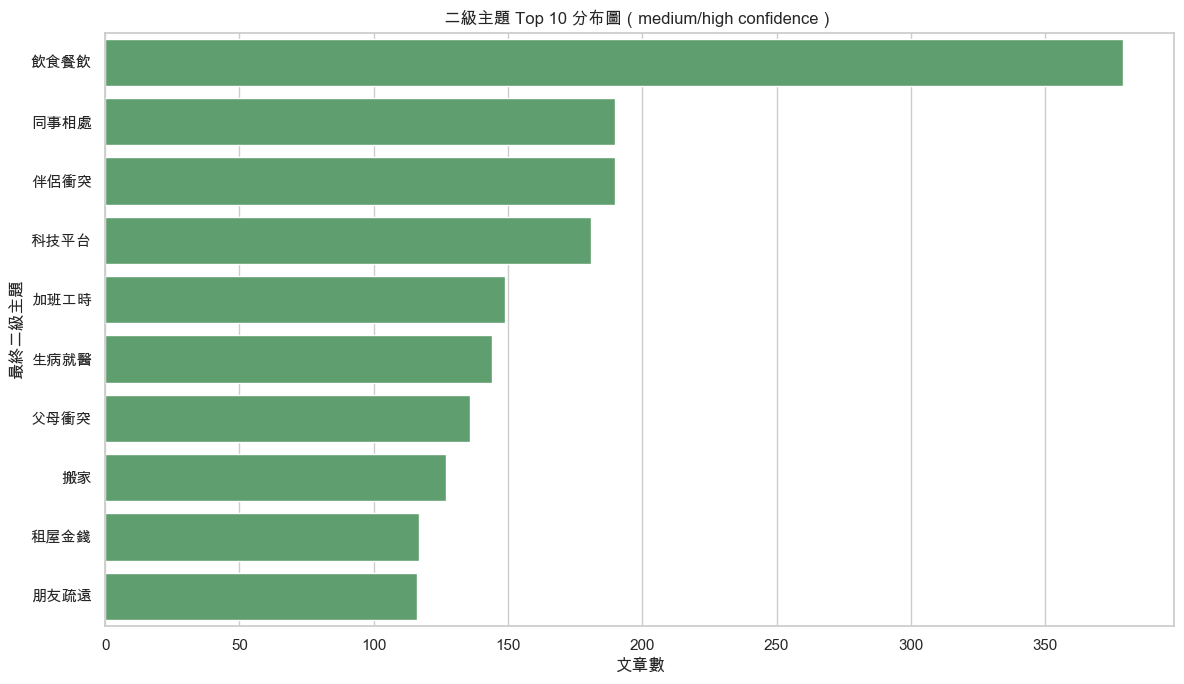

表 6-2-5 前十大二級主題的證據摘要


,final_secondary_topic,article_count,article_ratio,top_nouns,top_title_words,matched_secondary_keywords,representative_title
0,飲食餐飲,379,0.1362,早餐、晚餐、飲料、咖啡、午餐,晚上、早餐、中午、晚餐、好吃,晚餐、早餐、飲料、午餐、咖啡,[難過]遇到很混帳的早餐店員
1,同事相處,190,0.0683,同事、公司、主管、女同事、普妹,同事、女同事、排擠、工作、上班,同事、公司、辦公室、職場、排擠,[難過]被同事排擠好心累
2,伴侶衝突,190,0.0683,男友、女友、老公、男朋友、朋友,男友、女友、老公、男朋友、老婆,男友、女友、老公、吵架、老婆,[心情]男友與前女友
3,科技平台,181,0.0651,手機、帳號、同事、朋友、蘋果,手機、iphone、帳號、youtube、接受,手機、iphone、帳號、系統、youtube,[難過]請小心叫吳佳穎的臉書帳號
4,加班工時,149,0.0536,公司、薪水、時間、同事、主管,上班、工作、薪水、加班、還要,上班、工作、加班、薪水、下班,[難過]下班只想追劇
5,生病就醫,144,0.0518,保母、手術、家人、狀況、住院,憂鬱症、生病、拉肚子、確診、醫院,醫生、醫院、憂鬱症、不舒服、住院,[難過]狗狗結紮術後紗布未取出
6,父母衝突,136,0.0489,爸爸、父母、回家、家庭、家人,媽媽、爸爸、父母、爸媽、如何,媽媽、爸爸、父母、回家、爸媽,[心情]跟父母的相處
7,搬家,127,0.0457,房子、公寓、租屋、套房、公司,房東、鄰居、房子、房間、冷氣,房子、房東、房間、鄰居、冷氣,[難過]室友體味很重怎麼辦？
8,租屋金錢,117,0.0421,股票、存款、租屋、房子、房價,股票、漲價、租屋、沒錢、起房,股票、價格、漲價、沒錢、房價,[難過]不翼而飛的四千五百元
9,朋友疏遠,116,0.0417,朋友、群組、同學、時間、人生,朋友、好友、一起、生日、遇到,朋友、同學、閨蜜、漸行漸遠、絕交,[心情]覺得自己做人滿失敗的


解讀：`final_secondary_topic` 是正式主分析欄位，因為它比 `primary_topic` 更接近具體事件原因；主題證據摘要表則把文章數、代表名詞、命中關鍵詞與代表標題放在一起，方便直接回答『大家在難過什麼』。
補充：為避免過度解讀，後續月份趨勢、代表句與代表文章，優先聚焦 `classification_confidence` 為 medium 或 high 的分類結果。


In [34]:
# 6-2 統計 final_secondary_topic、分類信心與 primary_topic 分布，並建立主題證據摘要表

focus_confidence_levels = ["high", "medium"]
df_focus = df[df["classification_confidence"].isin(focus_confidence_levels)].copy()
if df_focus.empty:
    df_focus = df.copy()

final_secondary_topic_counts_df = (
    df["final_secondary_topic"]
    .value_counts(dropna=False)
    .rename_axis("final_secondary_topic")
    .reset_index(name="article_count")
)
final_secondary_topic_counts_df["article_ratio"] = (final_secondary_topic_counts_df["article_count"] / len(df)).round(4)

focus_secondary_topic_counts_df = (
    df_focus["final_secondary_topic"]
    .value_counts(dropna=False)
    .rename_axis("final_secondary_topic")
    .reset_index(name="article_count")
)
focus_secondary_topic_counts_df["article_ratio"] = (focus_secondary_topic_counts_df["article_count"] / len(df_focus)).round(4)

confidence_counts_df = (
    df["classification_confidence"]
    .value_counts(dropna=False)
    .rename_axis("classification_confidence")
    .reset_index(name="article_count")
)
confidence_counts_df["article_ratio"] = (confidence_counts_df["article_count"] / len(df)).round(4)

primary_topic_counts_df = (
    df["primary_topic"]
    .value_counts(dropna=False)
    .rename_axis("primary_topic")
    .reset_index(name="article_count")
)
primary_topic_counts_df["article_ratio"] = (primary_topic_counts_df["article_count"] / len(df)).round(4)

print("表 6-2-1 核心樣本 final_secondary_topic 分布（medium/high confidence）")
display(focus_secondary_topic_counts_df.head(12))
print("表 6-2-2 分類信心分布")
display(confidence_counts_df)
print("表 6-2-3 primary_topic 分布（全部核心樣本，作為高層次補充）")
display(primary_topic_counts_df)

plot_horizontal_bar(
    data=focus_secondary_topic_counts_df.head(10),
    x_col="article_count",
    y_col="final_secondary_topic",
    title="二級主題 Top 10 分布圖（medium/high confidence）",
    xlabel="文章數",
    ylabel="最終二級主題",
    color="#55A868",
)
print("圖 6-2-4 二級主題 Top 10 分布圖（medium/high confidence）")
plt.show()

confidence_rank_map = {"high": 2, "medium": 1, "low": 0}
topic_evidence_rows = []
representative_topic_names = focus_secondary_topic_counts_df["final_secondary_topic"].head(10).tolist()

for topic_name in representative_topic_names:
    topic_df = df_focus[df_focus["final_secondary_topic"] == topic_name].copy()
    if topic_df.empty:
        continue

    noun_counter = Counter([token for tokens in topic_df["noun_tokens_clean"] for token in tokens])
    title_counter = Counter([token for tokens in topic_df["title_tokens_clean"] for token in tokens])
    keyword_counter = Counter()
    for values in topic_df["matched_secondary_keywords"]:
        if isinstance(values, list):
            keyword_counter.update(values)

    topic_df["confidence_rank"] = topic_df["classification_confidence"].map(confidence_rank_map).fillna(0)
    representative_row = topic_df.sort_values(
        ["confidence_rank", "secondary_topic_score", "text_length"],
        ascending=[False, False, False],
    ).iloc[0]

    topic_evidence_rows.append(
        {
            "final_secondary_topic": topic_name,
            "article_count": int(len(topic_df)),
            "article_ratio": round(len(topic_df) / len(df_focus), 4),
            "top_nouns": "、".join([word for word, _ in noun_counter.most_common(5)]),
            "top_title_words": "、".join([word for word, _ in title_counter.most_common(5)]),
            "matched_secondary_keywords": "、".join([word for word, _ in keyword_counter.most_common(5)]),
            "representative_title": representative_row["artTitle"],
        }
    )

topic_evidence_summary_df = pd.DataFrame(topic_evidence_rows)
print("表 6-2-5 前十大二級主題的證據摘要")
display(topic_evidence_summary_df)

primary_topic_counts_df.to_csv(
    results_dir / "primary_topic_counts.csv",
    index=False,
    encoding="utf-8-sig",
)
focus_secondary_topic_counts_df.to_csv(
    results_dir / "secondary_topic_counts.csv",
    index=False,
    encoding="utf-8-sig",
)
confidence_counts_df.to_csv(
    results_dir / "classification_confidence_counts.csv",
    index=False,
    encoding="utf-8-sig",
)
topic_evidence_summary_df.to_csv(
    results_dir / "topic_evidence_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "解讀：`final_secondary_topic` 是正式主分析欄位，因為它比 `primary_topic` 更接近具體事件原因；"
    "主題證據摘要表則把文章數、代表名詞、命中關鍵詞與代表標題放在一起，方便直接回答『大家在難過什麼』。"
)
print(
    "補充：為避免過度解讀，後續月份趨勢、代表句與代表文章，優先聚焦 `classification_confidence` 為 medium 或 high 的分類結果。"
)


圖 6-3 primary_topic 分布圖（補充）


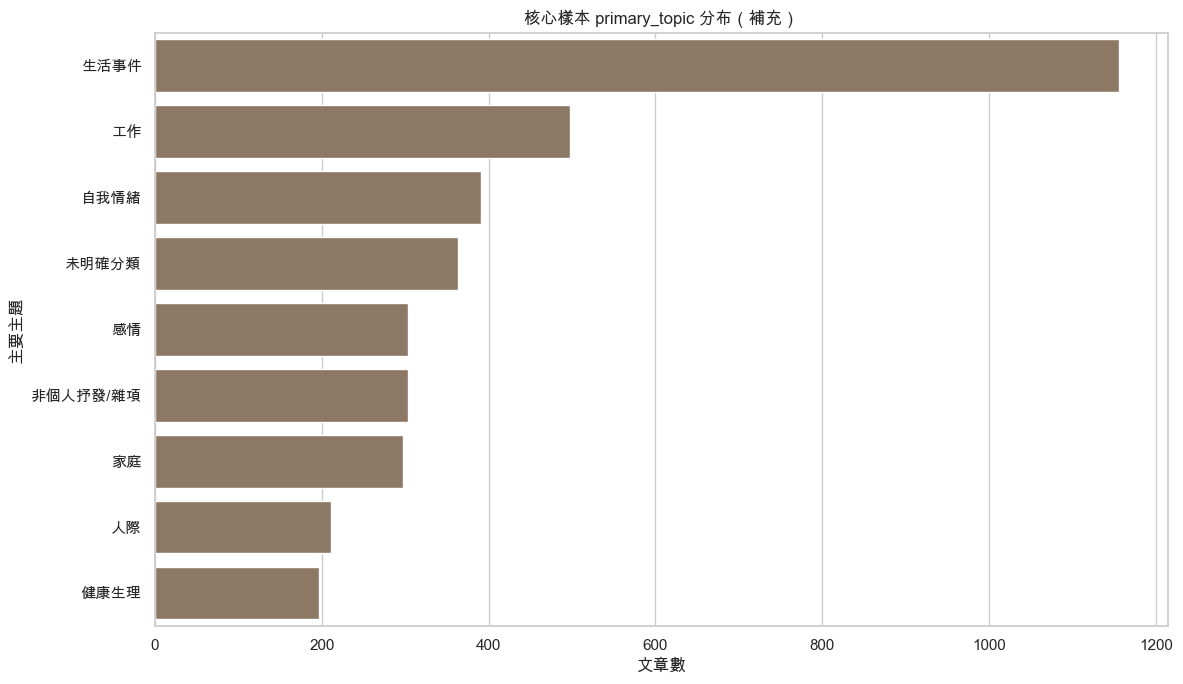

解讀：primary_topic 適合做高層次統整，但若要說明具體困擾來源，仍應回頭看 `final_secondary_topic` 與中高信心代表文章。


In [35]:
# 6-3 繪製 primary_topic 分布圖（高層次補充）

plot_horizontal_bar(
    data=primary_topic_counts_df,
    x_col="article_count",
    y_col="primary_topic",
    title="核心樣本 primary_topic 分布（補充）",
    xlabel="文章數",
    ylabel="主要主題",
    color="#937860",
)
print("圖 6-3 primary_topic 分布圖（補充）")
plt.show()

print("解讀：primary_topic 適合做高層次統整，但若要說明具體困擾來源，仍應回頭看 `final_secondary_topic` 與中高信心代表文章。")


### 補充：分類邊界樣本檢查與人工驗證

這一段不再把 top 3 候選主題當成正式答案，而是把它們退回到**檢查資訊**。
檢查重點包括：
- `classification_confidence = low` 的案例是否真的偏模糊。
- `非個人抒發/雜項` 是否只留下真正偏公共討論或泛論述的文章。
- `secondary_candidates` 是否提供合理的候選方向，而不是荒謬混搭。

這裡的目的不是追求所有文章都被硬塞進某一類，而是確認正式結果與邊界案例之間有被清楚區分，讓後面的結論更保守也更可信。


In [36]:
# 6-4 分類邊界樣本檢查
boundary_df = df[
    (df["classification_confidence"] == "low")
    | (df["primary_topic"] == "非個人抒發/雜項")
    | (df["final_secondary_topic"] == "未明確分類")
].copy()

boundary_noun_tokens = [token for tokens in boundary_df["noun_tokens_clean"] for token in tokens]
boundary_title_tokens = [token for tokens in boundary_df["title_tokens_clean"] for token in tokens]

boundary_noun_top30_df = build_top_word_table(boundary_noun_tokens, top_n=30, word_col="noun")
boundary_title_top30_df = build_top_word_table(boundary_title_tokens, top_n=30, word_col="title_word")

print("表 6-4-1 分類邊界樣本的高頻名詞 Top 30")
display(boundary_noun_top30_df)
print("表 6-4-2 分類邊界樣本的高頻標題詞 Top 30")
display(boundary_title_top30_df)

boundary_sample_size = min(30, len(boundary_df))
if boundary_sample_size > 0:
    boundary_sample_df = boundary_df.sample(n=boundary_sample_size, random_state=42).copy()
    boundary_sample_df["clean_content_preview"] = boundary_sample_df["clean_content"].astype(str).str.slice(0, 120)
    boundary_sample_df["secondary_candidates"] = boundary_sample_df["secondary_candidates"].apply(
        lambda values: "、".join(values) if isinstance(values, list) else values
    )
    print("表 6-4-3 分類邊界樣本隨機抽樣 30 篇（若不足則全數顯示）")
    display(
        boundary_sample_df[
            [
                "artTitle",
                "primary_topic",
                "final_secondary_topic",
                "secondary_candidates",
                "classification_reason",
                "classification_confidence",
                "clean_content_preview",
            ]
        ]
    )
else:
    print("提醒：目前沒有需要額外檢查的分類邊界樣本。")

print("解讀：這一段用來確認低信心與邊界案例是否真的偏模糊，並檢查 `secondary_candidates` 是否仍保留合理的人工判讀線索。")


表 6-4-1 分類邊界樣本的高頻名詞 Top 30


,noun,count
0,疫苗,94
1,時間,88
2,公司,69
3,人生,61
4,疫情,54
5,回家,52
6,社會,50
7,地方,47
8,人家,47
9,衣服,45


表 6-4-2 分類邊界樣本的高頻標題詞 Top 30


,title_word,count
0,上班,13
1,公司,11
2,睡覺,10
3,只有,10
4,疫情,9
5,不到,9
6,喜歡,9
7,工作,9
8,不能,9
9,起來,9


表 6-4-3 分類邊界樣本隨機抽樣 30 篇（若不足則全數顯示）


,artTitle,primary_topic,final_secondary_topic,secondary_candidates,classification_reason,classification_confidence,clean_content_preview
1360,[難過]覺得自己是個老廢物怎麼辦,未明確分類,未明確分類,伴侶衝突、主管壓力、加班工時,unresolved_personal,low,就\n最近啊\n常常覺得\n自己從小\n無論課業 事業跟感情都搞得一團糟\n學生時期不念書 ...
661,[難過]公司尾牙取消,未明確分類,未明確分類,同事相處、飲食餐飲、社會討論,unresolved_personal,low,剛剛得知公司尾牙取消了\n以疫情和飯店難定位為理由\n可是現在都開放內用了\n一年難得的大餐...
1931,[難過]我兩個兒子因為世足扭打在一起,未明確分類,未明確分類,,unresolved_personal,low,唉\n我一個鵝子支持巴西的\n一個支持阿根廷\n看他們身上穿的就分的出來吧 剛剛 大的就一直...
3224,[難過]沙茶醬好吃在哪?,非個人抒發/雜項,社會討論,,generic_discussion,low,吃個鍋燒麵常常一堆喳喳沉底部\n都是沙茶醬沒辦法溶掉的部分\n但沙茶醬熱量超高\n加了一堆到...
443,[難過]我真的做過重大惡極的事情,未明確分類,未明確分類,手足關係、陌生人衝突,unresolved_personal,low,在洗漱之前我想要自首自己做過可惡該下地獄的事情\n在2017年我說過要跟鄭捷一樣在捷運站上要...
1630,[難過]慟！紐約洋基被剃光頭！！！,自我情緒,壓力爆炸,伴侶衝突、科技平台,emotion_context_fallback,low,欸欸\n紐約洋基\n號稱邪惡帝國的超級豪門球隊\n隊上有史上最高薪投手蓋瑞寇爾\n40號王牌...
3406,[難過]遇到樑壓床,自我情緒,壓力爆炸,搬家、科技平台,emotion_context_fallback,low,最近搬家\n結果躺床的時候才發現有樑壓床\n實在是大意了...\n那個樑就剛好在頭的正上方\...
521,[難過]無良爆雷仔是反社會人格？,非個人抒發/雜項,社會討論,科技平台、朋友疏遠,weighted_match,high,As title\n最近很紅的韓劇魷魚遊戲\n我是上禮拜才開始看的\n看之前就第一次被雷到\...
331,[難過]我沒想到我竟然會受不了......,未明確分類,未明確分類,憂鬱低落、商品消費、朋友疏遠,unresolved_personal,low,"本人是個肥宅,高中時曾經因為懶得走出門買飯囤積泡麵,吃到同學看不下去主動幫買飯\n.原本以為..."
2041,[難過]當兵的難過事,自我情緒,壓力爆炸,行政瑣事、親友離世,emotion_context_fallback,low,"我是男生\n目前在服義務役 我今天在早上集合時,因疑似手插手袋而被要求要寫 自白書 .\n我..."


解讀：這一段用來確認低信心與邊界案例是否真的偏模糊，並檢查 `secondary_candidates` 是否仍保留合理的人工判讀線索。


In [37]:
# 6-5 人工驗證抽樣
manual_review_frames = []

top_focus_secondary_topics = focus_secondary_topic_counts_df["final_secondary_topic"].head(8).tolist()
for topic_name in top_focus_secondary_topics:
    topic_sample_df = df_focus[df_focus["final_secondary_topic"] == topic_name].copy()
    if topic_sample_df.empty:
        continue
    sample_n = min(3, len(topic_sample_df))
    manual_review_frames.append(topic_sample_df.sample(n=sample_n, random_state=42))

low_confidence_review_df = df[df["classification_confidence"] == "low"].copy()
if not low_confidence_review_df.empty:
    manual_review_frames.append(low_confidence_review_df.sample(n=min(10, len(low_confidence_review_df)), random_state=42))

classification_manual_review_df = (
    pd.concat(manual_review_frames, ignore_index=True)
    if manual_review_frames
    else pd.DataFrame()
)

if not classification_manual_review_df.empty:
    classification_manual_review_df["clean_content_preview"] = classification_manual_review_df["clean_content"].astype(str).str.slice(0, 100)
    review_display_df = classification_manual_review_df[
        [
            "artTitle",
            "primary_topic",
            "final_secondary_topic",
            "secondary_candidates",
            "matched_secondary_keywords",
            "classification_reason",
            "classification_confidence",
            "clean_content_preview",
        ]
    ].copy()
    review_display_df["secondary_candidates"] = review_display_df["secondary_candidates"].apply(
        lambda values: "、".join(values) if isinstance(values, list) else values
    )
    review_display_df["matched_secondary_keywords"] = review_display_df["matched_secondary_keywords"].apply(
        lambda values: "、".join(values) if isinstance(values, list) else values
    )

    print("表 6-5 分類人工驗證抽樣")
    display(review_display_df)
    review_display_df.to_csv(
        results_dir / "classification_manual_review_sample.csv",
        index=False,
        encoding="utf-8-sig",
    )
    print(f"已輸出人工驗證抽樣：{results_dir / 'classification_manual_review_sample.csv'}")
else:
    print("提醒：目前沒有可供人工驗證抽樣的文章。")


表 6-5 分類人工驗證抽樣


,artTitle,primary_topic,final_secondary_topic,secondary_candidates,matched_secondary_keywords,classification_reason,classification_confidence,clean_content_preview
0,[難過]17分鐘吃得完拉麵嗎?,生活事件,飲食餐飲,主管壓力、加班工時、生病就醫,食物,title_food_fallback,medium,光設17分鐘的用餐時間就覺得不舒服\n又不是上班趕時間把食物塞進肚子\n只吃麵麵不喝湯湯老闆...
1,[難過]吃到有油耗味的堅果,生活事件,飲食餐飲,,,title_food_fallback,medium,半夜嘴饞開了一包堅果來吃\n結果一咬下去就有濃濃的油耗味\n嘔嘔嘔嘔嘔\n嚴重懷疑老天在懲罰...
2,[難過]今天晚上我又吃多了拉!,生活事件,飲食餐飲,,午餐,title_food_fallback,medium,今天晚上除了吃正餐之外 又吃了黑糖粉圓刨冰\n想必熱量不少吧! 不過我午餐有吃少一點就是\n...
3,[難過]改吃養生飲食被同事嘲諷怎麼辦？,工作,同事相處,飲食餐飲、父母衝突、生病就醫,同事、職場,weighted_match_clear,high,"如題\n我媽最近診斷出糖尿病前期\n因為年輕時吃太多蛋糕 零食,不忌口\n我整個嚇到發現媽媽..."
4,[難過]同事是故意的嗎？,工作,同事相處,,互動、同事,weighted_match_clear,high,昨天跟同事去聚餐\n同事a較晚到\n他來的時候我揮手跟他打招呼(面對面 還揮了2次)\n但他...
5,[難過]同事想給我看她的大咪咪,工作,同事相處,,同事,weighted_match_clear,high,同事明明就大B小A而已也不算大\n居然問我想不想看她家的咪咪\n這時Line就傳來一陣聲響\...
6,[難過]請大家評評理,感情,伴侶衝突,曖昧拒絕、婚後家庭、小孩照顧,先生、太太、老公、老婆,weighted_match_clear,high,"朋友跟我討拍,因為一件小事但她很難過\n前兩天她自己在家煮晚餐吃\n用了一個鍋子放在洗碗槽一..."
7,[難過]老公眼界很小怎麼辦,感情,伴侶衝突,生病就醫、婚後家庭、離職面試,老公,weighted_match_clear,high,"最近越來越不喜歡跟老公講話,他總是一副剛愎自用的樣子 講話回話都很消極跟負面\n我說這間店廚..."
8,[難過]每年過年除夕夜就吵架,感情,伴侶衝突,手足關係,吵架,weighted_match,high,是這樣的\n每年過年我表弟全家都會來我家拿紅包\n剛好我們兩家政治理念有點不合\n我們全家都...
9,[難過]我們與惡的距離到底哪裡可看,生活事件,科技平台,,平台,secondary_hint_fallback,medium,"我媽說他想看這部\n我看了MOD戲劇,搜尋找不到\nnetflix也翻來翻去都沒有\n這部這..."


已輸出人工驗證抽樣：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/results/classification_manual_review_sample.csv


In [38]:
# 6-6 建立各月份 x final_secondary_topic 交叉表（medium/high confidence）

top_month_secondary_topics = focus_secondary_topic_counts_df["final_secondary_topic"].head(10).tolist()
topic_month_pivot = (
    pd.crosstab(df_focus["month_of_year"], df_focus["final_secondary_topic"])
    .reindex(month_order, fill_value=0)
)
topic_month_pivot = topic_month_pivot.reindex(columns=top_month_secondary_topics, fill_value=0)
topic_month_pivot.index.name = "month_of_year"
topic_month_pivot.to_csv(results_dir / "topic_month_pivot.csv", encoding="utf-8-sig")

print("表 6-6 各月份 x final_secondary_topic 交叉表（medium/high confidence，跨年聚合）")
display(topic_month_pivot)


表 6-6 各月份 x final_secondary_topic 交叉表（medium/high confidence，跨年聚合）


final_secondary_topic,飲食餐飲,同事相處,伴侶衝突,科技平台,加班工時,生病就醫,父母衝突,搬家,租屋金錢,朋友疏遠
month_of_year,,,,,,,,,,
1,32,13,23,13,31,15,17,13,8,13
2,29,14,17,17,11,14,14,10,13,9
3,26,11,17,14,7,11,4,6,11,10
4,19,14,21,12,9,10,11,12,8,13
5,20,20,21,19,16,19,15,5,11,13
6,27,15,15,14,15,11,9,11,10,6
7,28,15,12,11,8,10,11,18,12,13
8,33,13,18,12,9,10,14,11,8,6
9,35,15,13,23,10,12,11,13,8,13


圖 6-7 各月份主要二級主題趨勢圖（跨年聚合）


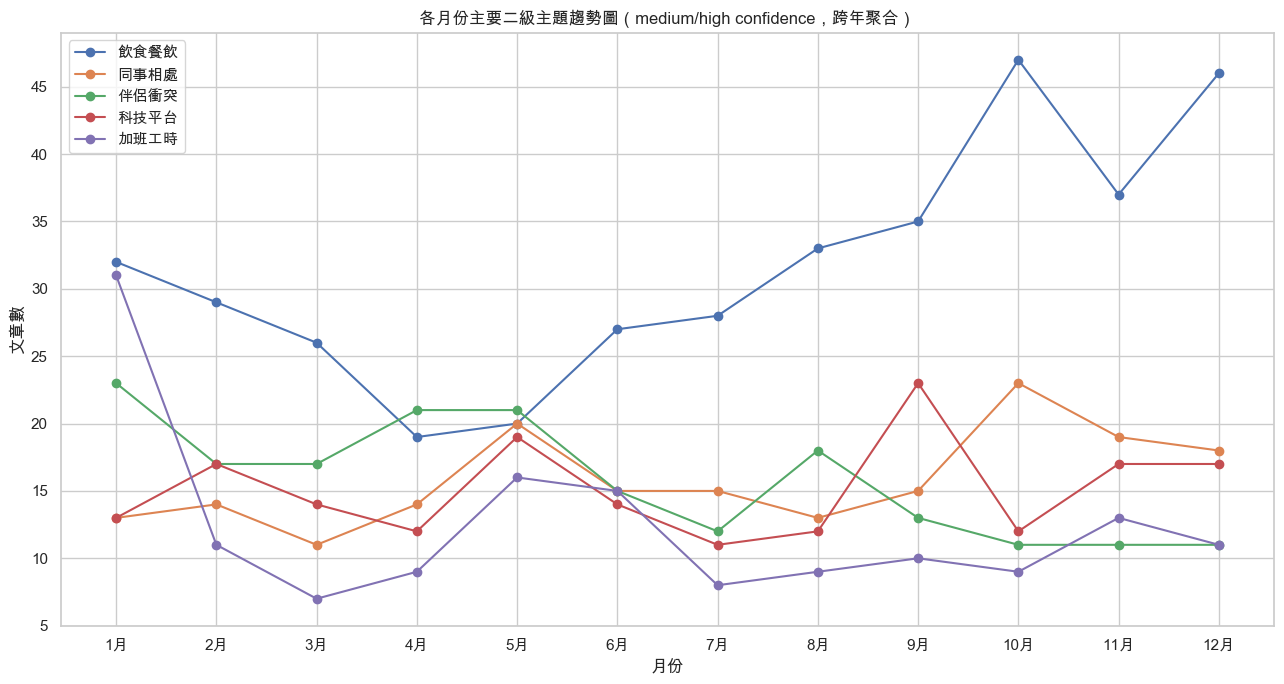

In [39]:
# 6-7 繪製各月份主要二級主題趨勢圖

top_topics = top_month_secondary_topics[:5] if top_month_secondary_topics else []
topic_month_top = topic_month_pivot[top_topics].copy() if top_topics else pd.DataFrame(index=month_order)

plt.figure(figsize=(13, 7))
for topic_name in top_topics:
    plt.plot(topic_month_top.index, topic_month_top[topic_name], marker="o", label=topic_name)

plt.title("各月份主要二級主題趨勢圖（medium/high confidence，跨年聚合）")
plt.xlabel("月份")
plt.ylabel("文章數")
plt.xticks(month_order, [month_label_map[month] for month in month_order], rotation=0)
plt.legend()
plt.tight_layout()
print("圖 6-7 各月份主要二級主題趨勢圖（跨年聚合）")
plt.show()


圖 6-8 各月份主要二級主題比例趨勢圖（跨年聚合）


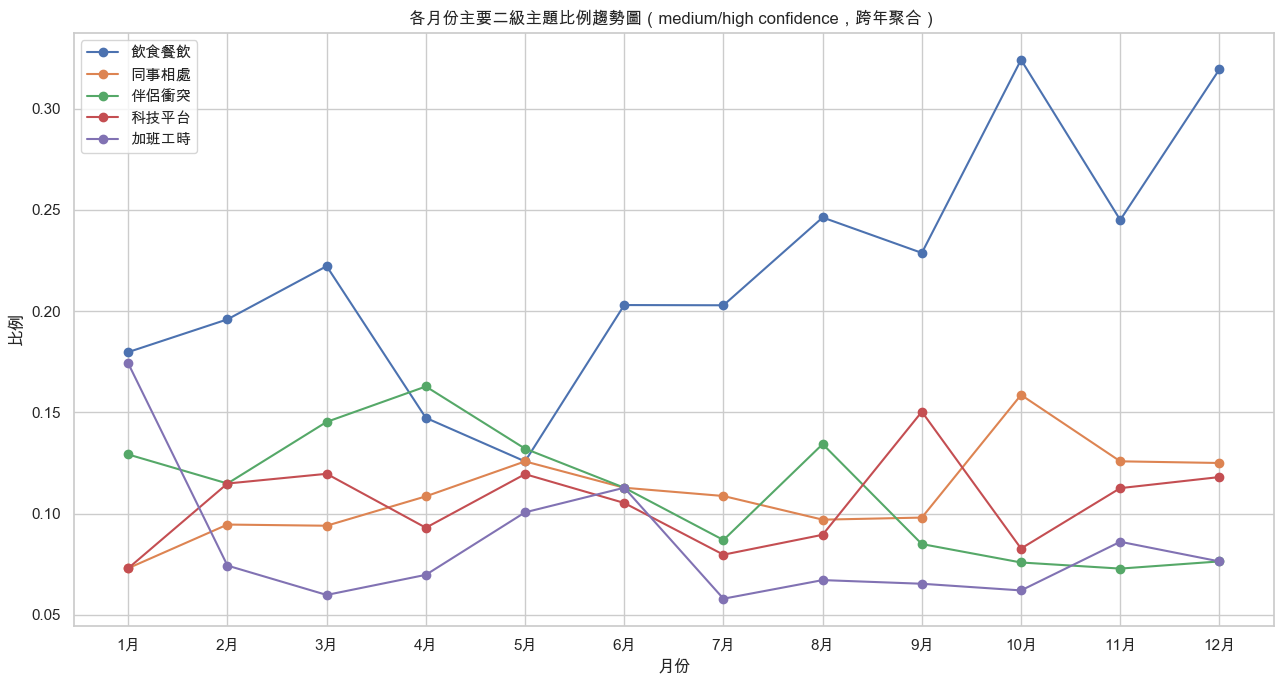

解讀：月份比較改以中高信心的 `final_secondary_topic` 為主，比直接用較粗的 `primary_topic` 更接近實際困擾事件。


In [40]:
# 6-8 繪製各月份主要二級主題比例趨勢圖

topic_month_ratio = topic_month_pivot.div(topic_month_pivot.sum(axis=1), axis=0).fillna(0)
topic_month_ratio_top = topic_month_ratio[top_topics].copy() if top_topics else pd.DataFrame(index=month_order)

plt.figure(figsize=(13, 7))
for topic_name in top_topics:
    plt.plot(
        topic_month_ratio_top.index,
        topic_month_ratio_top[topic_name],
        marker="o",
        label=topic_name,
    )

plt.title("各月份主要二級主題比例趨勢圖（medium/high confidence，跨年聚合）")
plt.xlabel("月份")
plt.ylabel("比例")
plt.xticks(month_order, [month_label_map[month] for month in month_order], rotation=0)
plt.legend()
plt.tight_layout()
print("圖 6-8 各月份主要二級主題比例趨勢圖（跨年聚合）")
plt.show()

print("解讀：月份比較改以中高信心的 `final_secondary_topic` 為主，比直接用較粗的 `primary_topic` 更接近實際困擾事件。")


## 7. 情緒分析：LIWC 主線、SnowNLP 比較與 baseline 對照

這一段把情緒分析正式重構成三層：
- `LIWC`：主線方法。優點是可解釋，能直接指出文本裡命中的正向、負向、悲傷、憤怒與焦慮詞。
- `SnowNLP`：比較方法。優點是能直接給一個整體情緒分數，適合拿來和字典法交叉比對。
- 簡化字典法 baseline：保留原本 notebook 的情緒邏輯，作為課堂方法延伸與穩定對照。

因為資料本身來自「難過」相關貼文，這裡的重點不是證明整體偏負面，而是觀察：
- 不同月份的情緒強度是否出現相對變化。
- 不同二級主題的情緒強度是否不同。
- `LIWC` 與 `SnowNLP` 的判斷是否一致，若不一致，分歧通常出現在什麼文本。

因此，這一章主要回答的是「哪些文本情緒最重、什麼時候較重、不同方法看法是否一致」，並與前面的「在難過什麼事」互相對照。


In [41]:
# 7-1 準備情緒分析資源與函式

liwc_dict_candidates = [
    base_dir / "SMA_2026S-main" / "week04" / "dict" / "liwc" / "LIWC_CH.csv",
    base_dir / "week04" / "dict" / "liwc" / "LIWC_CH.csv",
    base_dir / "dict" / "liwc" / "LIWC_CH.csv",
]
liwc_dict_path = next((path for path in liwc_dict_candidates if path.exists()), None)
if liwc_dict_path is None:
    raise FileNotFoundError("找不到 LIWC 中文字典，請確認 LIWC_CH.csv 是否存在。")

lex_positive_words = {
    "開心", "快樂", "喜歡", "幸福", "溫暖", "支持", "鼓勵", "感謝", "安心", "放鬆",
    "舒服", "陪伴", "療癒", "幸運", "安慰", "希望", "穩定", "好轉", "喜悅", "被愛"
}
lex_negative_words = {
    "難過", "低落", "失望", "無助", "崩潰", "痛苦", "焦慮", "憂鬱", "討厭", "害怕",
    "孤單", "委屈", "受傷", "分手", "失眠", "煩", "煩躁", "哭", "哭了", "難受",
    "壓力", "絕望", "挫折", "生氣", "不安", "心累"
}
lex_sadness_words = {"難過", "低落", "憂鬱", "痛苦", "失望", "委屈", "哭", "哭了", "難受"}
lex_fear_words = {"焦慮", "害怕", "不安", "擔心", "恐慌"}
lex_anger_words = {"討厭", "生氣", "煩", "煩躁", "火大", "崩潰"}
lex_support_words = {"支持", "鼓勵", "陪伴", "安慰", "溫暖", "感謝", "安心", "療癒"}

liwc_raw_df = pd.read_csv(liwc_dict_path)
liwc_raw_df["name"] = liwc_raw_df["name"].fillna("").astype(str).map(normalize_token)
liwc_raw_df["class"] = liwc_raw_df["class"].fillna("").astype(str).str.strip().str.lower()
liwc_raw_df = liwc_raw_df[
    liwc_raw_df["name"].astype(str).str.strip().ne("")
    & liwc_raw_df["class"].astype(str).str.strip().ne("")
].drop_duplicates()

liwc_class_map = (
    liwc_raw_df.groupby("name")["class"]
    .apply(lambda values: sorted(set(values)))
    .to_dict()
)
liwc_positive_words = {word for word, classes in liwc_class_map.items() if "positive" in classes}
liwc_negative_words = {word for word, classes in liwc_class_map.items() if "negative" in classes}
liwc_affect_words = {word for word, classes in liwc_class_map.items() if "affect" in classes}
liwc_sad_words = {word for word, classes in liwc_class_map.items() if "sad" in classes}
liwc_anger_words = {word for word, classes in liwc_class_map.items() if "anger" in classes}
liwc_anx_words = {word for word, classes in liwc_class_map.items() if "anx" in classes}


def build_sentiment_tokens(raw_tokens):
    values = raw_tokens if isinstance(raw_tokens, list) else []
    clean_tokens = []

    for token in values:
        token = normalize_token(str(token).strip())
        if not token:
            continue
        if is_stopword(token):
            continue
        if re.fullmatch(r"\d+", token):
            continue
        if re.fullmatch(r"[\W_]+", token):
            continue
        clean_tokens.append(token)

    return clean_tokens


def join_unique_hits(tokens, max_items=12):
    ordered_unique = []
    seen = set()
    for token in tokens:
        if token not in seen:
            seen.add(token)
            ordered_unique.append(token)
    return "、".join(ordered_unique[:max_items])


def label_from_counts(pos_count, neg_count):
    if pos_count > neg_count:
        return "positive"
    if pos_count < neg_count:
        return "negative"
    return "neutral"


def lexicon_sentiment(tokens, positive_words, negative_words):
    pos_hits = [token for token in tokens if token in positive_words]
    neg_hits = [token for token in tokens if token in negative_words]
    token_count = len(tokens)
    score = len(pos_hits) - len(neg_hits)
    score_norm = score / token_count if token_count else 0.0

    return pd.Series(
        {
            "lex_positive_count": len(pos_hits),
            "lex_negative_count": len(neg_hits),
            "lex_score": score,
            "lex_score_norm": score_norm,
            "lex_label": label_from_counts(len(pos_hits), len(neg_hits)),
        }
    )


def liwc_sentiment(tokens):
    affect_hits = [token for token in tokens if token in liwc_affect_words]
    positive_hits = [token for token in tokens if token in liwc_positive_words]
    negative_hits = [token for token in tokens if token in liwc_negative_words]
    sad_hits = [token for token in tokens if token in liwc_sad_words]
    anger_hits = [token for token in tokens if token in liwc_anger_words]
    anx_hits = [token for token in tokens if token in liwc_anx_words]
    token_count = len(tokens)
    score = len(positive_hits) - len(negative_hits)
    score_norm = score / token_count if token_count else 0.0

    return pd.Series(
        {
            "liwc_affect_count": len(affect_hits),
            "liwc_positive_count": len(positive_hits),
            "liwc_negative_count": len(negative_hits),
            "liwc_sad_count": len(sad_hits),
            "liwc_anger_count": len(anger_hits),
            "liwc_anx_count": len(anx_hits),
            "liwc_score": score,
            "liwc_score_norm": score_norm,
            "liwc_label": label_from_counts(len(positive_hits), len(negative_hits)),
            "liwc_positive_hits": join_unique_hits(positive_hits),
            "liwc_negative_hits": join_unique_hits(negative_hits),
        }
    )


def snownlp_sentiment(text):
    if not snownlp_available:
        return pd.Series(
            {
                "snownlp_sentiment": np.nan,
                "snownlp_score": np.nan,
                "snownlp_label": "unavailable",
            }
        )

    text = str(text).strip()
    if not text:
        return pd.Series(
            {
                "snownlp_sentiment": np.nan,
                "snownlp_score": np.nan,
                "snownlp_label": "neutral",
            }
        )

    sentiment = float(SnowNLP(text).sentiments)
    centered_score = sentiment - 0.5
    if sentiment >= 0.6:
        label = "positive"
    elif sentiment <= 0.4:
        label = "negative"
    else:
        label = "neutral"

    return pd.Series(
        {
            "snownlp_sentiment": sentiment,
            "snownlp_score": centered_score,
            "snownlp_label": label,
        }
    )


sentiment_resources_df = pd.DataFrame(
    {
        "item": [
            "LIWC 中文字典",
            "LIWC positive 詞數",
            "LIWC negative 詞數",
            "LIWC sad 詞數",
            "LIWC anger 詞數",
            "LIWC anx 詞數",
            "SnowNLP",
        ],
        "status": [
            str(liwc_dict_path),
            len(liwc_positive_words),
            len(liwc_negative_words),
            len(liwc_sad_words),
            len(liwc_anger_words),
            len(liwc_anx_words),
            "可用" if snownlp_available else "不可用（將略過比較）",
        ],
    }
)
print("表 7-1 情緒分析資源檢查")
display(sentiment_resources_df)


表 7-1 情緒分析資源檢查

,item,status
0,LIWC 中文字典,/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/SMA_2...
1,LIWC positive 詞數,730
2,LIWC negative 詞數,1172
3,LIWC sad 詞數,192
4,LIWC anger 詞數,358
5,LIWC anx 詞數,169
6,SnowNLP,可用


In [42]:
# 7-2 建立 baseline、LIWC 與 SnowNLP 情緒欄位

sentiment_columns_to_replace = [
    "sentiment_tokens",
    "lex_positive_count",
    "lex_negative_count",
    "lex_score",
    "lex_score_norm",
    "lex_label",
    "liwc_affect_count",
    "liwc_positive_count",
    "liwc_negative_count",
    "liwc_sad_count",
    "liwc_anger_count",
    "liwc_anx_count",
    "liwc_score",
    "liwc_score_norm",
    "liwc_label",
    "liwc_positive_hits",
    "liwc_negative_hits",
    "snownlp_sentiment",
    "snownlp_score",
    "snownlp_label",
]
df = df.drop(columns=sentiment_columns_to_replace, errors="ignore")

print_step_start("7-2", "建立文章層級情緒欄位")
df["sentiment_tokens"] = apply_with_progress(df["raw_tokens"], build_sentiment_tokens, "7-2 sentiment_tokens")

lexicon_result_df = apply_with_progress(
    df["sentiment_tokens"],
    lambda tokens: lexicon_sentiment(tokens, lex_positive_words, lex_negative_words),
    "7-2 lexicon_sentiment",
)
liwc_result_df = apply_with_progress(df["sentiment_tokens"], liwc_sentiment, "7-2 liwc_sentiment")

if snownlp_available:
    snownlp_result_df = apply_with_progress(df["analysis_text"], snownlp_sentiment, "7-2 snownlp_sentiment")
else:
    snownlp_result_df = pd.DataFrame(
        {
            "snownlp_sentiment": [np.nan] * len(df),
            "snownlp_score": [np.nan] * len(df),
            "snownlp_label": ["unavailable"] * len(df),
        },
        index=df.index,
    )

df = pd.concat([df, lexicon_result_df, liwc_result_df, snownlp_result_df], axis=1)
print_step_end("7-2", "建立文章層級情緒欄位")

sentiment_head_df = df[
    [
        "artTitle",
        "final_secondary_topic",
        "lex_score_norm",
        "liwc_score_norm",
        "liwc_label",
        "snownlp_score",
        "snownlp_label",
    ]
].head(5)
print("表 7-2 情緒欄位示例")
display(sentiment_head_df)



步驟 7-2：建立文章層級情緒欄位


7-2 sentiment_tokens:   0%|          | 0/3719 [00:00<?, ?it/s]

7-2 lexicon_sentiment:   0%|          | 0/3719 [00:00<?, ?it/s]

7-2 liwc_sentiment:   0%|          | 0/3719 [00:00<?, ?it/s]

7-2 snownlp_sentiment:   0%|          | 0/3719 [00:00<?, ?it/s]

[完成] 7-2 建立文章層級情緒欄位

表 7-2 情緒欄位示例


,artTitle,final_secondary_topic,lex_score_norm,liwc_score_norm,liwc_label,snownlp_score,snownlp_label
0,[難過]陽台又淹水了,搬家,-0.003906,-0.019531,negative,-0.500000,negative
1,[難過]插隊的人很不ok欸（文長慎入）,陌生人衝突,0.005435,0.003623,positive,-0.500000,negative
2,[心情]男女真的不平等唉唉唉唉唉,壓力爆炸,-0.013699,-0.027397,negative,-0.499995,negative
3,[難過]一直遺憾當初沒有救回自殺的朋友.很想他,親友離世,0.008499,0.039660,positive,-0.500000,negative
4,[難過]生理期會想哭,生理期,-0.153846,-0.076923,negative,-0.498555,negative


In [43]:
# 7-3 比較三種方法的整體結果

def build_method_summary(method_name, label_series, score_series):
    label_series = label_series.fillna("unavailable")
    available_mask = label_series.ne("unavailable")
    available_count = int(available_mask.sum())
    total_count = int(len(label_series))
    label_ratio = label_series[available_mask].value_counts(normalize=True).round(4) if available_count else pd.Series(dtype=float)
    return {
        "method": method_name,
        "available_docs": available_count,
        "coverage_ratio": round(available_count / total_count, 4) if total_count else 0.0,
        "avg_score": round(float(score_series[available_mask].mean()), 4) if available_count else np.nan,
        "positive_ratio": label_ratio.get("positive", 0.0),
        "neutral_ratio": label_ratio.get("neutral", 0.0),
        "negative_ratio": label_ratio.get("negative", 0.0),
    }


sentiment_method_summary_df = pd.DataFrame(
    [
        build_method_summary("Lexicon baseline", df["lex_label"], df["lex_score_norm"]),
        build_method_summary("LIWC", df["liwc_label"], df["liwc_score_norm"]),
        build_method_summary("SnowNLP", df["snownlp_label"], df["snownlp_score"]),
    ]
)
print("表 7-3-1 三種情緒方法整體結果")
display(sentiment_method_summary_df)

comparable_mask = df["snownlp_label"].isin(["positive", "neutral", "negative"])
if comparable_mask.any():
    sentiment_agreement_df = pd.DataFrame(
        {
            "metric": ["LIWC 與 SnowNLP 整體一致率", "同時判為 negative 的比例", "同時判為 positive 的比例"],
            "value": [
                round(float((df.loc[comparable_mask, "liwc_label"] == df.loc[comparable_mask, "snownlp_label"]).mean()), 4),
                round(float(((df.loc[comparable_mask, "liwc_label"] == "negative") & (df.loc[comparable_mask, "snownlp_label"] == "negative")).mean()), 4),
                round(float(((df.loc[comparable_mask, "liwc_label"] == "positive") & (df.loc[comparable_mask, "snownlp_label"] == "positive")).mean()), 4),
            ],
        }
    )
else:
    sentiment_agreement_df = pd.DataFrame(
        {"metric": ["LIWC 與 SnowNLP 整體一致率"], "value": [np.nan]}
    )

print("表 7-3-2 LIWC 與 SnowNLP 一致率")
display(sentiment_agreement_df)

print(
    "解讀：LIWC 提供可解釋的詞彙證據，SnowNLP 提供整體分數；"
    "如果兩者方向一致，通常代表文本情緒相對明確，若分歧較大，則值得回看原文語境。"
)


表 7-3-1 三種情緒方法整體結果


,method,available_docs,coverage_ratio,avg_score,positive_ratio,neutral_ratio,negative_ratio
0,Lexicon baseline,3719,1.0,-0.0041,0.1578,0.5257,0.3165
1,LIWC,3719,1.0,-0.0109,0.3001,0.1753,0.5246
2,SnowNLP,3719,1.0,-0.3813,0.1049,0.0177,0.8774


表 7-3-2 LIWC 與 SnowNLP 一致率


,metric,value
0,LIWC 與 SnowNLP 整體一致率,0.5246
1,同時判為 negative 的比例,0.4746
2,同時判為 positive 的比例,0.0471


解讀：LIWC 提供可解釋的詞彙證據，SnowNLP 提供整體分數；如果兩者方向一致，通常代表文本情緒相對明確，若分歧較大，則值得回看原文語境。


表 7-4 各月份平均情緒分數比較（跨年聚合）


,month_of_year,article_count,avg_lex_score_norm,avg_liwc_score_norm,avg_snownlp_score,avg_snownlp_sentiment,month_label
0,1,381,-0.008281,-0.012504,-0.396514,0.103486,1月
1,2,317,-0.003523,-0.010338,-0.405696,0.094304,2月
2,3,280,-0.004128,-0.015482,-0.385913,0.114087,3月
3,4,271,-0.004416,-0.012715,-0.348460,0.151540,4月
4,5,326,-0.002903,-0.011476,-0.385266,0.114734,5月
5,6,296,-0.003791,-0.010594,-0.352683,0.147317,6月
6,7,298,-0.001829,-0.005695,-0.373884,0.126116,7月
7,8,264,-0.003192,-0.008964,-0.389049,0.110951,8月
8,9,295,-0.002857,-0.006792,-0.380889,0.119111,9月
9,10,323,-0.002931,-0.009369,-0.362838,0.137162,10月


圖 7-4 各月份平均情緒分數比較（跨年聚合）


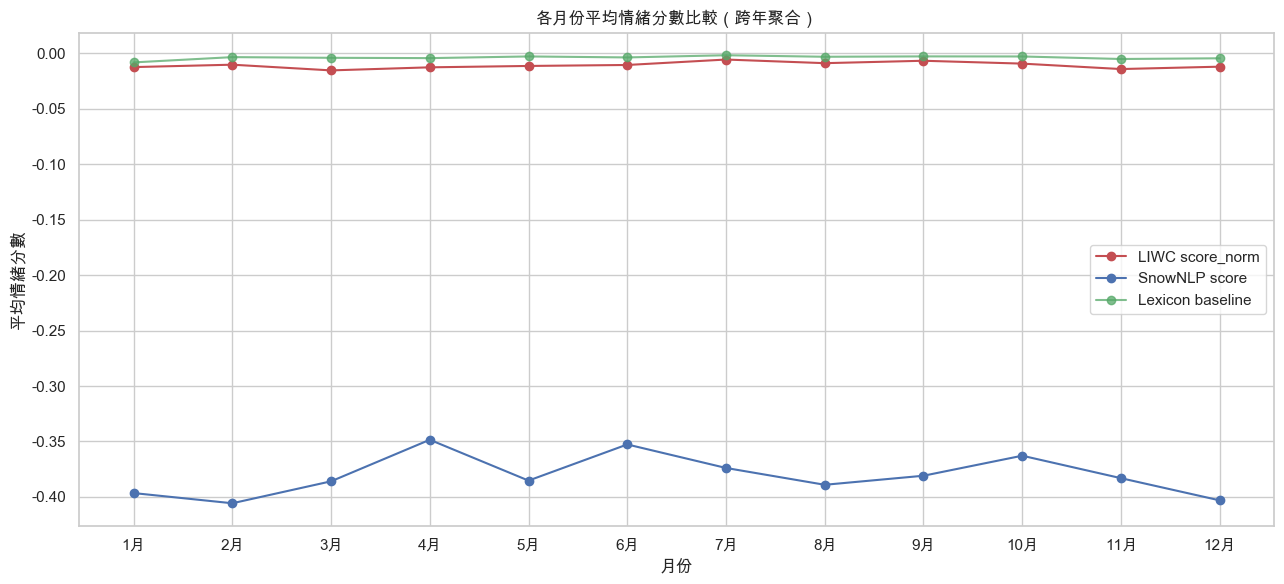

解讀：這張圖把 LIWC、SnowNLP 與 baseline 放在同一個月份軸上，方便比較方法之間是否指向相同的相對高低變化。


In [44]:
# 7-4 各月份平均情緒分數比較

monthly_sentiment_compare_df = (
    df.dropna(subset=["month_of_year"])
    .groupby("month_of_year")
    .agg(
        article_count=("doc_id", "size"),
        avg_lex_score_norm=("lex_score_norm", "mean"),
        avg_liwc_score_norm=("liwc_score_norm", "mean"),
        avg_snownlp_score=("snownlp_score", "mean"),
        avg_snownlp_sentiment=("snownlp_sentiment", "mean"),
    )
    .reset_index()
    .sort_values("month_of_year")
)
monthly_sentiment_compare_df["month_of_year"] = monthly_sentiment_compare_df["month_of_year"].astype(int)
monthly_sentiment_compare_df["month_label"] = monthly_sentiment_compare_df["month_of_year"].map(month_label_map)

print("表 7-4 各月份平均情緒分數比較（跨年聚合）")
display(monthly_sentiment_compare_df)

plt.figure(figsize=(13, 6))
plt.plot(
    monthly_sentiment_compare_df["month_of_year"],
    monthly_sentiment_compare_df["avg_liwc_score_norm"],
    marker="o",
    label="LIWC score_norm",
    color="#C44E52",
)
plt.plot(
    monthly_sentiment_compare_df["month_of_year"],
    monthly_sentiment_compare_df["avg_snownlp_score"],
    marker="o",
    label="SnowNLP score",
    color="#4C72B0",
)
plt.plot(
    monthly_sentiment_compare_df["month_of_year"],
    monthly_sentiment_compare_df["avg_lex_score_norm"],
    marker="o",
    label="Lexicon baseline",
    color="#55A868",
    alpha=0.75,
)
plt.title("各月份平均情緒分數比較（跨年聚合）")
plt.xlabel("月份")
plt.ylabel("平均情緒分數")
plt.xticks(month_order, [month_label_map[month] for month in month_order], rotation=0)
plt.legend()
plt.tight_layout()
print("圖 7-4 各月份平均情緒分數比較（跨年聚合）")
plt.show()

print("解讀：這張圖把 LIWC、SnowNLP 與 baseline 放在同一個月份軸上，方便比較方法之間是否指向相同的相對高低變化。")


表 7-5-1 各月份 LIWC 正負中性文章數（跨年聚合）


liwc_label,positive,neutral,negative
month_of_year,,,
1,116,59,206
2,92,59,166
3,70,59,151
4,80,36,155
5,96,57,173
6,93,45,158
7,101,54,143
8,81,51,132
9,102,46,147


表 7-5-2 各月份 LIWC 正負中性文章比例（跨年聚合）


liwc_label,positive,neutral,negative
month_of_year,,,
1,0.304462,0.154856,0.540682
2,0.290221,0.186120,0.523659
3,0.250000,0.210714,0.539286
4,0.295203,0.132841,0.571956
5,0.294479,0.174847,0.530675
6,0.314189,0.152027,0.533784
7,0.338926,0.181208,0.479866
8,0.306818,0.193182,0.500000
9,0.345763,0.155932,0.498305


圖 7-5 各月份 LIWC 正負中性文章比例（跨年聚合）


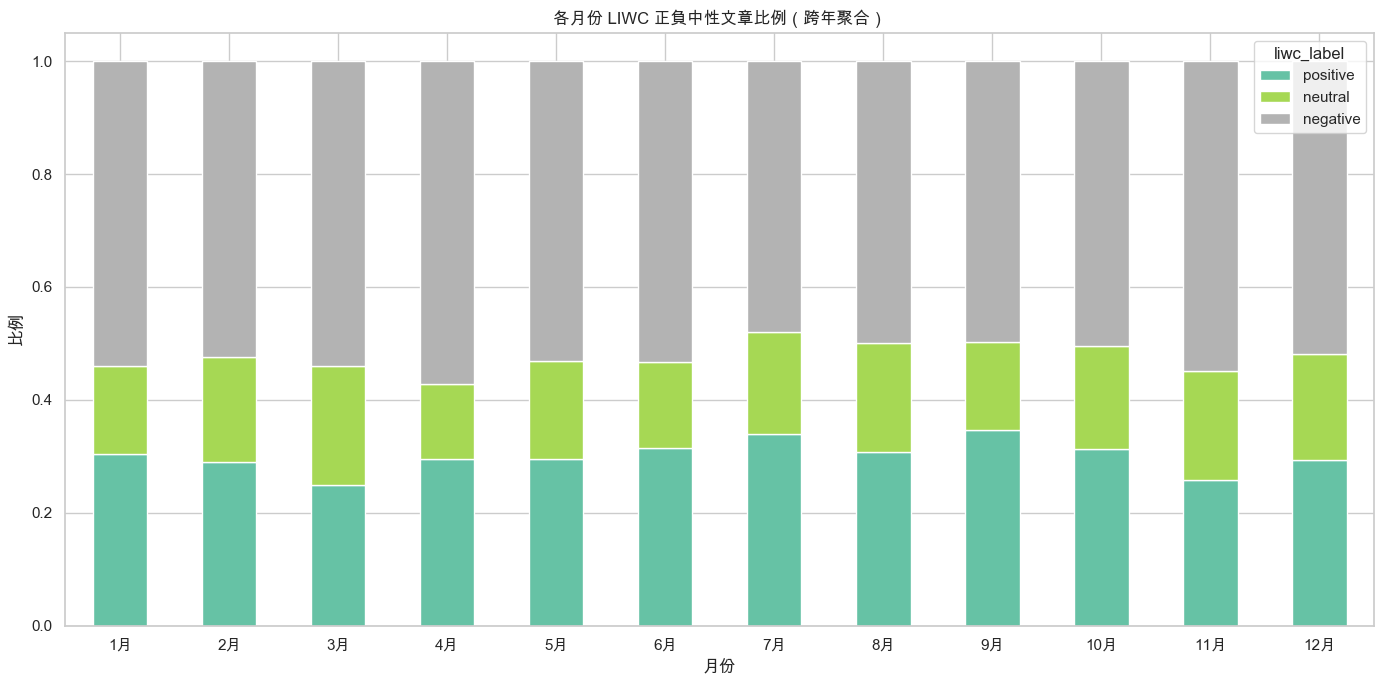

解讀：這張圖以 LIWC 作為主線，比平均分數更容易看出某些月份是否特別集中在 negative 或 neutral。


In [45]:
# 7-5 各月份 LIWC 正負中性文章比例

monthly_liwc_label_counts_df = (
    df.dropna(subset=["month_of_year"])
    .groupby(["month_of_year", "liwc_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["positive", "neutral", "negative"], fill_value=0)
    .reindex(month_order, fill_value=0)
)
monthly_liwc_label_ratio_df = monthly_liwc_label_counts_df.div(monthly_liwc_label_counts_df.sum(axis=1), axis=0).fillna(0)

print("表 7-5-1 各月份 LIWC 正負中性文章數（跨年聚合）")
display(monthly_liwc_label_counts_df)
print("表 7-5-2 各月份 LIWC 正負中性文章比例（跨年聚合）")
display(monthly_liwc_label_ratio_df)

monthly_liwc_label_ratio_df.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    colormap="Set2",
)
plt.title("各月份 LIWC 正負中性文章比例（跨年聚合）")
plt.xlabel("月份")
plt.ylabel("比例")
plt.xticks(range(len(month_order)), [month_label_map[month] for month in month_order], rotation=0)
plt.tight_layout()
print("圖 7-5 各月份 LIWC 正負中性文章比例（跨年聚合）")
plt.show()

print("解讀：這張圖以 LIWC 作為主線，比平均分數更容易看出某些月份是否特別集中在 negative 或 neutral。")


表 7-6 各二級主題的情緒強度摘要（medium/high confidence）


,final_secondary_topic,article_count,avg_liwc_score_norm,liwc_negative_ratio,avg_snownlp_score,avg_lex_score_norm
35,飲食餐飲,379,-0.007043,0.472296,-0.356952,-0.005200
4,同事相處,190,-0.005395,0.452632,-0.440891,0.000933
1,伴侶衝突,190,-0.004384,0.484211,-0.393352,-0.000539
25,科技平台,181,-0.007022,0.480663,-0.417066,0.000140
3,加班工時,149,-0.013227,0.476510,-0.410954,-0.005344
23,生病就醫,144,-0.023161,0.680556,-0.407074,-0.006157
21,父母衝突,136,-0.015558,0.632353,-0.341550,-0.003942
16,搬家,127,-0.011546,0.551181,-0.471496,-0.002424
26,租屋金錢,117,-0.009064,0.470085,-0.452284,-0.003908
19,朋友疏遠,116,0.019172,0.275862,-0.335140,-0.001432


圖 7-6 前十大二級主題的平均 LIWC 情緒分數


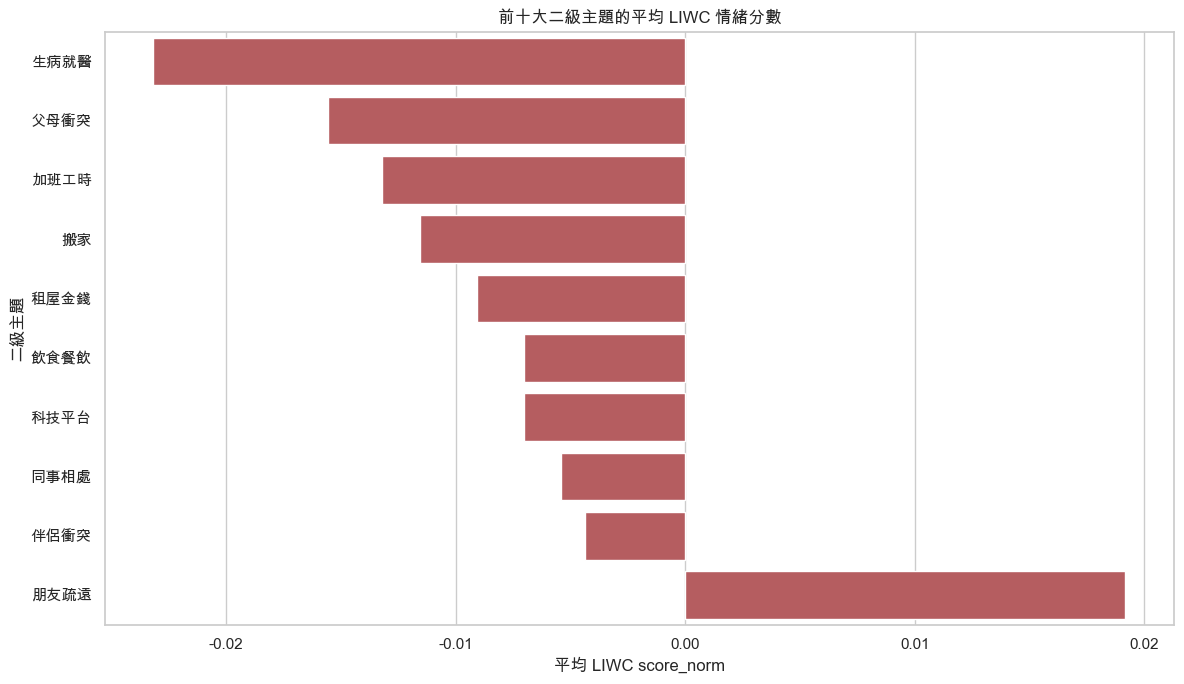

解讀：這一段把『在難過什麼』和『情緒有多重』接起來。若某個二級主題文章數多，且平均 LIWC 分數更低，就代表它不只常見，情緒也較重。


In [46]:
# 7-6 各二級主題的情緒強度摘要

focus_topic_sentiment_df = df[df["classification_confidence"].isin(focus_confidence_levels)].copy()
if focus_topic_sentiment_df.empty:
    focus_topic_sentiment_df = df.copy()

topic_sentiment_source_df = focus_topic_sentiment_df[
    ~focus_topic_sentiment_df["final_secondary_topic"].isin(["未明確分類"])
].copy()

topic_sentiment_summary_df = (
    topic_sentiment_source_df.groupby("final_secondary_topic")
    .agg(
        article_count=("doc_id", "size"),
        avg_liwc_score_norm=("liwc_score_norm", "mean"),
        liwc_negative_ratio=("liwc_label", lambda values: float((values == "negative").mean())),
        avg_snownlp_score=("snownlp_score", "mean"),
        avg_lex_score_norm=("lex_score_norm", "mean"),
    )
    .reset_index()
    .sort_values(["article_count", "avg_liwc_score_norm"], ascending=[False, True])
)

print("表 7-6 各二級主題的情緒強度摘要（medium/high confidence）")
display(topic_sentiment_summary_df.head(12))

topic_sentiment_plot_df = topic_sentiment_summary_df.head(10).sort_values("avg_liwc_score_norm", ascending=True)
plot_horizontal_bar(
    data=topic_sentiment_plot_df,
    x_col="avg_liwc_score_norm",
    y_col="final_secondary_topic",
    title="前十大二級主題的平均 LIWC 情緒分數",
    xlabel="平均 LIWC score_norm",
    ylabel="二級主題",
    color="#C44E52",
)
print("圖 7-6 前十大二級主題的平均 LIWC 情緒分數")
plt.show()

print(
    "解讀：這一段把『在難過什麼』和『情緒有多重』接起來。"
    "若某個二級主題文章數多，且平均 LIWC 分數更低，就代表它不只常見，情緒也較重。"
)


圖 7-7-1 各月份 LIWC 情緒子類命中量（跨年聚合）

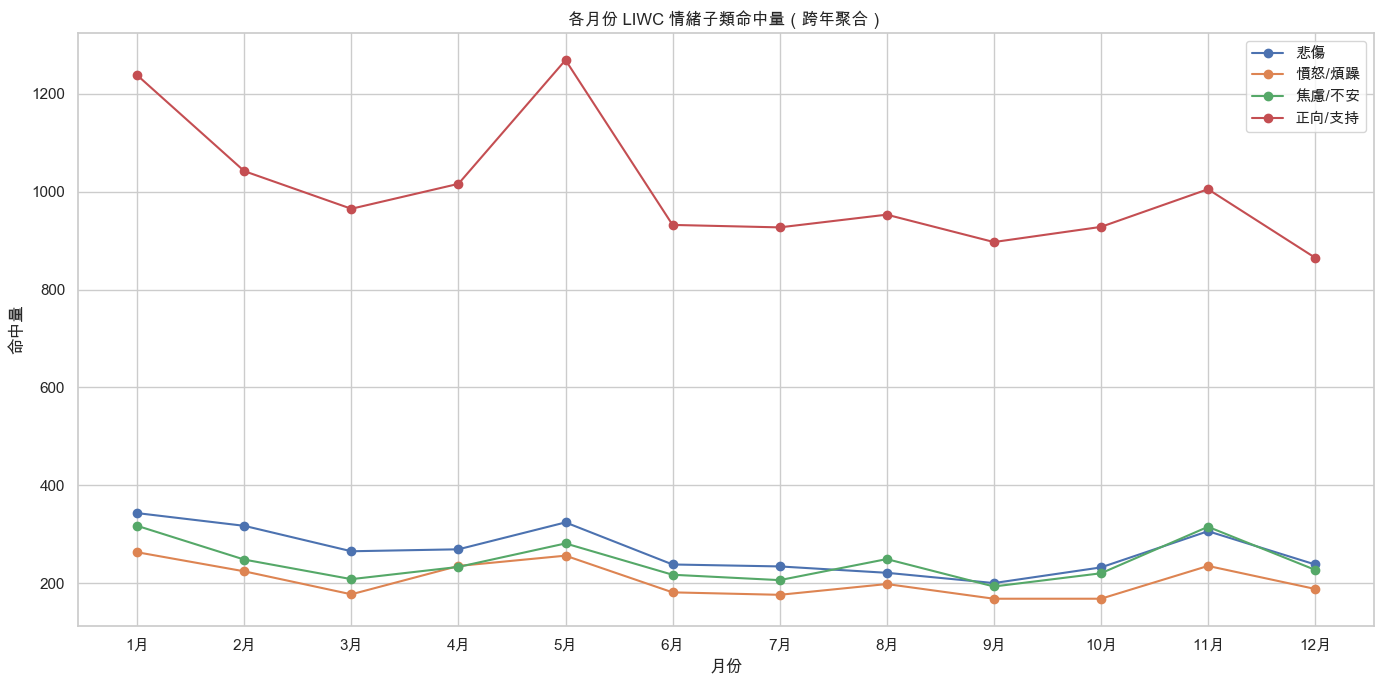

表 7-7-1 LIWC 正負向代表詞


,liwc_positive_word,count,liwc_negative_word,count
0,好,2488,不,3390
1,朋友,819,難過,1101
2,希望,488,不要,650
3,喜歡,433,打,358
4,大,399,死,331
5,玩,193,不好,281
6,謝謝,184,怕,204
7,開心,177,幹,180
8,幫忙,152,壓力,170
9,分享,150,情緒,161


表 7-7-2 LIWC 與 SnowNLP 分歧案例


,artDate,artTitle,final_secondary_topic,liwc_label,snownlp_label,liwc_score_norm,snownlp_score,liwc_negative_hits,clean_content_preview
206,2021-04-21 08:17:44,[難過]啊啊啊啊啊啊啊啊啊啊啊啊啊,社會討論,negative,positive,-0.461538,0.500000,難過、可悲、可憐、亂、糟,肥宅難過\n肥宅可悲可悲肥宅可憐哪\n亂七八糟喵\n啊啊啊啊啊啊啊啊啊啊啊啊啊啊啊啊啊啊啊啊...
1115,2022-06-29 09:57:01,[難過]頭痛,失眠頭痛,negative,positive,-0.262295,0.500000,痛、可悲,頭痛眼睛痛頭痛眼睛痛頭痛眼睛痛頭痛眼睛痛頭痛眼睛痛\n頭痛眼睛痛頭痛眼睛痛頭痛眼睛痛頭痛眼睛...
1988,2022-12-24 13:36:42,[難過]正妹喜歡的是我的心臟，這樣還要跟她在一,曖昧拒絕,positive,negative,0.181818,-0.489866,不、煩惱,"原本知道有超級正的大正妹喜歡我還很開心的,想不到她喜歡的居然是我的心臟,其他地方都不喜歡\n..."
899,2022-04-21 15:54:55,[難過]正妹女同事今天沒有上班QQ,同事相處,positive,negative,0.172414,-0.497778,難過,大家好 我阿肥\n阿肥今天很難過 QQ\n因為今天正妹女同事沒有上班\n來到辦公室的時候歡歡...
2874,2023-09-18 02:25:47,[難過]「好喔」、「好的」還是「好啊」?,同事相處,positive,negative,0.162162,-0.500000,隨便,跟同事傳訊息蕉流完\n最後表達OK 可以 收到的意思時\n都會用 好喔 來回復\n不過公司前...
60,2021-02-09 21:19:52,[難過]痛三小幹,社會討論,negative,positive,-0.216216,0.437081,痛、幹、可憐,肥宅眼睛痛啦嗚嗚嗚嗚嗚嗚嗚嗚嗚嗚\n痛三小 幹\n早上痛中午痛下午痛晚上痛半夜痛\n有病\n...
38,2021-01-24 00:54:22,[難過]肥宅眼睛痛,失眠頭痛,negative,positive,-0.150000,0.500000,痛、可憐,肥宅眼睛痛 頭痛\n睡著了就不會痛 可是醒來了\n隔好久都還睡不著\n可憐那\n啊啊啊啊啊啊...
811,2022-03-03 22:14:21,[難過]聰明有可能被被感染嗎？,伴侶衝突,positive,negative,0.153846,-0.495514,死,這裡說的聰明不單指讀書厲害那種\n還包括遇到事情腦子轉的快 容易變通的人\n超羨慕這種人的 ...
2407,2023-03-27 22:33:17,[難過]痛徹心扉.紀念狒狒~,未明確分類,negative,positive,-0.142857,0.495678,混亂、自私、貪圖、殘忍、無助、冷酷、否定、不、憤怒,回憶混亂我的腳步 阻礙了出路\n證明了你的自私你的貪圖 殘忍的 看著我無助\n平淡的回應我 ...
3140,2024-01-18 19:09:44,[難過]在女友面前幫異性好友夾菜，真的很不妥嗎,伴侶衝突,positive,negative,0.137255,-0.498543,,大家都是好朋友\n女生手短桌子太大\n幫女友夾菜也幫隔壁女性好友夾菜\n如果是女友的好閨密\...


解讀：LIWC 子類能補充情緒類型，分歧案例則提醒我們某些文本可能具有語境、反諷或敘事轉折，不能只看單一方法。


In [47]:
# 7-7 LIWC 子類、代表情緒詞與方法分歧案例

monthly_liwc_subtype_df = (
    df.dropna(subset=["month_of_year"])
    .groupby("month_of_year")[["liwc_sad_count", "liwc_anger_count", "liwc_anx_count", "liwc_positive_count"]]
    .sum()
    .reindex(month_order, fill_value=0)
    .reset_index()
)
monthly_liwc_subtype_df["month_label"] = monthly_liwc_subtype_df["month_of_year"].map(month_label_map)

plt.figure(figsize=(14, 7))
for column_name, label_name in [
    ("liwc_sad_count", "悲傷"),
    ("liwc_anger_count", "憤怒/煩躁"),
    ("liwc_anx_count", "焦慮/不安"),
    ("liwc_positive_count", "正向/支持"),
]:
    plt.plot(monthly_liwc_subtype_df["month_of_year"], monthly_liwc_subtype_df[column_name], marker="o", label=label_name)

plt.title("各月份 LIWC 情緒子類命中量（跨年聚合）")
plt.xlabel("月份")
plt.ylabel("命中量")
plt.xticks(month_order, [month_label_map[month] for month in month_order], rotation=0)
plt.legend()
plt.tight_layout()
print("圖 7-7-1 各月份 LIWC 情緒子類命中量（跨年聚合）")
plt.show()

liwc_positive_rep_words_df = pd.DataFrame(
    Counter([token for tokens in df["sentiment_tokens"] for token in tokens if token in liwc_positive_words]).most_common(10),
    columns=["liwc_positive_word", "count"],
)
liwc_negative_rep_words_df = pd.DataFrame(
    Counter([token for tokens in df["sentiment_tokens"] for token in tokens if token in liwc_negative_words]).most_common(10),
    columns=["liwc_negative_word", "count"],
)
representative_liwc_words_df = pd.concat(
    [liwc_positive_rep_words_df.reset_index(drop=True), liwc_negative_rep_words_df.reset_index(drop=True)],
    axis=1,
)
print("表 7-7-1 LIWC 正負向代表詞")
display(representative_liwc_words_df)

disagreement_source_df = df[
    df["snownlp_label"].isin(["positive", "neutral", "negative"])
    & df["liwc_label"].isin(["positive", "neutral", "negative"])
    & df["snownlp_label"].ne(df["liwc_label"])
].copy()

if not disagreement_source_df.empty:
    disagreement_source_df["score_gap_abs"] = (
        disagreement_source_df["liwc_score_norm"].fillna(0) - disagreement_source_df["snownlp_score"].fillna(0)
    ).abs()
    disagreement_source_df["clean_content_preview"] = disagreement_source_df["clean_content"].astype(str).str.slice(0, 100)
    disagreement_display_df = disagreement_source_df.sort_values(
        ["score_gap_abs", "text_length"],
        ascending=[False, False],
    ).head(12)[
        [
            "artDate",
            "artTitle",
            "final_secondary_topic",
            "liwc_label",
            "snownlp_label",
            "liwc_score_norm",
            "snownlp_score",
            "liwc_negative_hits",
            "clean_content_preview",
        ]
    ]
    print("表 7-7-2 LIWC 與 SnowNLP 分歧案例")
    display(disagreement_display_df)
else:
    disagreement_display_df = pd.DataFrame()
    print("提醒：目前沒有 LIWC 與 SnowNLP 明顯分歧的案例，或 SnowNLP 尚未啟用。")

print("解讀：LIWC 子類能補充情緒類型，分歧案例則提醒我們某些文本可能具有語境、反諷或敘事轉折，不能只看單一方法。")


In [48]:
# 7-8 輸出文章層級情緒結果與比較表

sentiment_article_scores_df = df[
    [
        "doc_id",
        "artTitle",
        "artDate",
        "month",
        "month_of_year",
        "month_label",
        "artUrl",
        "primary_topic",
        "final_secondary_topic",
        "classification_confidence",
        "lex_positive_count",
        "lex_negative_count",
        "lex_score",
        "lex_score_norm",
        "lex_label",
        "liwc_affect_count",
        "liwc_positive_count",
        "liwc_negative_count",
        "liwc_sad_count",
        "liwc_anger_count",
        "liwc_anx_count",
        "liwc_score",
        "liwc_score_norm",
        "liwc_label",
        "liwc_positive_hits",
        "liwc_negative_hits",
        "snownlp_sentiment",
        "snownlp_score",
        "snownlp_label",
    ]
].copy()

legacy_lexicon_article_scores_df = sentiment_article_scores_df[
    [
        "artTitle",
        "artDate",
        "month",
        "month_of_year",
        "month_label",
        "artUrl",
        "primary_topic",
        "final_secondary_topic",
        "classification_confidence",
        "lex_positive_count",
        "lex_negative_count",
        "lex_score",
        "lex_score_norm",
        "lex_label",
    ]
].copy()

sentiment_article_scores_df.to_csv(
    results_dir / "sentiment_article_scores.csv",
    index=False,
    encoding="utf-8-sig",
)
legacy_lexicon_article_scores_df.to_csv(
    results_dir / "lexicon_article_scores.csv",
    index=False,
    encoding="utf-8-sig",
)
monthly_sentiment_compare_df.to_csv(
    results_dir / "monthly_sentiment_compare.csv",
    index=False,
    encoding="utf-8-sig",
)
monthly_liwc_label_ratio_df.reset_index().to_csv(
    results_dir / "monthly_liwc_label_ratio.csv",
    index=False,
    encoding="utf-8-sig",
)
monthly_liwc_subtype_df.to_csv(
    results_dir / "monthly_liwc_subtype.csv",
    index=False,
    encoding="utf-8-sig",
)
topic_sentiment_summary_df.to_csv(
    results_dir / "topic_sentiment_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
sentiment_method_summary_df.to_csv(
    results_dir / "sentiment_method_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
sentiment_agreement_df.to_csv(
    results_dir / "sentiment_agreement.csv",
    index=False,
    encoding="utf-8-sig",
)
representative_liwc_words_df.to_csv(
    results_dir / "representative_liwc_words.csv",
    index=False,
    encoding="utf-8-sig",
)
disagreement_display_df.to_csv(
    results_dir / "sentiment_disagreement_cases.csv",
    index=False,
    encoding="utf-8-sig",
)

print(f"已輸出文章層級情緒結果：{results_dir / 'sentiment_article_scores.csv'}")
print(f"已同步更新 baseline 相容檔：{results_dir / 'lexicon_article_scores.csv'}")
print(f"已輸出月份情緒比較表：{results_dir / 'monthly_sentiment_compare.csv'}")
print(f"已輸出月份 LIWC 比例表：{results_dir / 'monthly_liwc_label_ratio.csv'}")
print(f"已輸出月份 LIWC 子類表：{results_dir / 'monthly_liwc_subtype.csv'}")
print(f"已輸出主題情緒摘要表：{results_dir / 'topic_sentiment_summary.csv'}")
print(f"已輸出情緒方法總表：{results_dir / 'sentiment_method_summary.csv'}")
print(f"已輸出方法一致率表：{results_dir / 'sentiment_agreement.csv'}")
print(f"已輸出 LIWC 代表詞表：{results_dir / 'representative_liwc_words.csv'}")
print(f"已輸出方法分歧案例：{results_dir / 'sentiment_disagreement_cases.csv'}")


已輸出文章層級情緒結果：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/results/sentiment_article_scores.csv
已同步更新 baseline 相容檔：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/results/lexicon_article_scores.csv
已輸出月份情緒比較表：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/results/monthly_sentiment_compare.csv
已輸出月份 LIWC 比例表：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/results/monthly_liwc_label_ratio.csv
已輸出月份 LIWC 子類表：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/results/monthly_liwc_subtype.csv
已輸出主題情緒摘要表：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/results/topic_sentiment_summary.csv
已輸出情緒方法總表：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/results/sentiment_method_summary.csv
已輸出方法一致率表：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/results/sentiment_agreement.csv
已輸出 LIWC 代表詞表：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/results/representative_liwc_words.csv
已輸出方法分歧案例：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/results/sentiment_disagreement_cases.csv


## 8. 代表月份、代表句與代表文章

這一段把前面的量化結果拉回文本脈絡。
這裡的月份改成跨年聚合的 `1月~12月`，並以 `LIWC` 作為主線情緒分數，優先搭配 `medium/high confidence` 的 `final_secondary_topic` 回看：
- 哪些月份最常出現哪些具體困擾。
- 哪些月份的 `LIWC` 平均分數最低或最高。
- 代表句是否真的對應到主題名稱。
- 代表文章是否能補充事件細節與情緒脈絡。

這一章的作用，是讓高頻詞、主題分布與情緒圖表不只停在數字，而能回到原始文本說明「她們究竟在難過什麼」。


In [49]:
# 8-1 找出代表月份

top_post_month = (
    df["month_of_year"].dropna().astype(int).value_counts().idxmax()
    if not df["month_of_year"].dropna().empty
    else None
)
lowest_score_month = (
    int(monthly_sentiment_compare_df.sort_values("avg_liwc_score_norm").iloc[0]["month_of_year"])
    if not monthly_sentiment_compare_df.empty
    else None
)
highest_score_month = (
    int(monthly_sentiment_compare_df.sort_values("avg_liwc_score_norm", ascending=False).iloc[0]["month_of_year"])
    if not monthly_sentiment_compare_df.empty
    else None
)

representative_months_df = pd.DataFrame(
    {
        "category": ["貼文最多月份", "LIWC 最負面月份", "LIWC 最正向月份"],
        "month": [
            month_label_map.get(top_post_month),
            month_label_map.get(lowest_score_month),
            month_label_map.get(highest_score_month),
        ],
    }
)

print("表 8-1 代表月份清單")
display(representative_months_df)


表 8-1 代表月份清單


,category,month
0,貼文最多月份,1月
1,LIWC 最負面月份,3月
2,LIWC 最正向月份,7月


In [50]:
# 8-2 顯示代表月份回看

confidence_order = {"high": 2, "medium": 1, "low": 0}
focus_analysis_df = df[df["classification_confidence"].isin(focus_confidence_levels)].copy()
if focus_analysis_df.empty:
    focus_analysis_df = df.copy()


def build_month_summary(month_value, data_frame, focus_data_frame):
    month_df = data_frame[data_frame["month_of_year"] == month_value].copy()
    focus_month_df = focus_data_frame[focus_data_frame["month_of_year"] == month_value].copy()
    topic_source_df = focus_month_df if not focus_month_df.empty else month_df

    month_tokens = [token for tokens in month_df["tokens_clean_for_analysis"] for token in tokens]
    month_negative_tokens = [
        token for tokens in month_df["sentiment_tokens"] for token in tokens if token in liwc_negative_words
    ]
    top_words = "、".join([word for word, _ in Counter(month_tokens).most_common(8)])
    top_liwc_negative_words = "、".join([word for word, _ in Counter(month_negative_tokens).most_common(5)])
    top_final_secondary_topic = (
        topic_source_df["final_secondary_topic"].value_counts().idxmax()
        if not topic_source_df.empty
        else "未明確分類"
    )
    top_primary_topic = (
        topic_source_df["primary_topic"].value_counts().idxmax()
        if not topic_source_df.empty
        else "未明確分類"
    )

    return pd.DataFrame(
        {
            "month": [month_label_map.get(month_value)],
            "article_count": [len(month_df)],
            "focus_article_count": [len(focus_month_df)],
            "avg_liwc_score_norm": [round(float(month_df["liwc_score_norm"].mean()), 4)],
            "avg_snownlp_score": [round(float(month_df["snownlp_score"].mean()), 4)],
            "liwc_negative_ratio": [round(float((month_df["liwc_label"] == "negative").mean()), 4)],
            "top_final_secondary_topic": [top_final_secondary_topic],
            "top_primary_topic": [top_primary_topic],
            "top_words": [top_words],
            "top_liwc_negative_words": [top_liwc_negative_words],
        }
    )


def select_month_representatives(month_value, data_frame, top_n=3, prefer_positive=False):
    month_df = data_frame[data_frame["month_of_year"] == month_value].copy()
    month_df["confidence_rank"] = month_df["classification_confidence"].map(confidence_order).fillna(0)

    representative_df = month_df.sort_values(
        ["confidence_rank", "secondary_topic_score", "text_length", "liwc_score_norm"],
        ascending=[False, False, False, not prefer_positive],
    ).head(top_n)

    representative_df = representative_df.copy()
    representative_df["text_preview"] = representative_df["clean_content"].astype(str).str.slice(0, 90)
    representative_df["secondary_candidates"] = representative_df["secondary_candidates"].apply(
        lambda values: "、".join(values) if isinstance(values, list) else values
    )
    return representative_df[
        [
            "artDate",
            "artTitle",
            "primary_topic",
            "final_secondary_topic",
            "secondary_candidates",
            "classification_confidence",
            "secondary_topic_score",
            "liwc_score_norm",
            "liwc_label",
            "snownlp_score",
            "snownlp_label",
            "text_preview",
        ]
    ]


def show_month_snapshot(section_title, month_value, prefer_positive=False):
    if month_value is None:
        print(f"{section_title}：沒有可用月份。")
        return

    summary_df = build_month_summary(month_value, df, focus_analysis_df)
    representative_df = select_month_representatives(
        month_value,
        focus_analysis_df,
        top_n=3,
        prefer_positive=prefer_positive,
    )

    month_label = month_label_map.get(month_value, str(month_value))
    print(f"\n【{section_title}：{month_label}】")
    display(summary_df)
    display(representative_df)

    top_secondary_topic = summary_df.iloc[0]["top_final_secondary_topic"]
    print(f"解讀：{month_label} 的中高信心代表文本多集中在「{top_secondary_topic}」，可用來回看這個月份最典型的難過事件。")


show_month_snapshot("A. 貼文最多月份", top_post_month)
show_month_snapshot("B. 最負面月份", lowest_score_month)
show_month_snapshot("C. 最正向月份", highest_score_month, prefer_positive=True)



【A. 貼文最多月份：1月】


,month,article_count,focus_article_count,avg_liwc_score_norm,avg_snownlp_score,liwc_negative_ratio,top_final_secondary_topic,top_primary_topic,top_words,top_liwc_negative_words
0,1月,381,285,-0.0125,-0.3965,0.5407,飲食餐飲,生活事件,朋友、上班、工作、同事、不想、家人、一起、雖然,不、難過、不要、死、受害者


,artDate,artTitle,primary_topic,final_secondary_topic,secondary_candidates,classification_confidence,secondary_topic_score,liwc_score_norm,liwc_label,snownlp_score,snownlp_label,text_preview
2206,2023-01-31 00:08:12,[難過]狗狗結紮術後紗布未取出,健康生理,生病就醫,寵物、科技平台,high,72,-0.001704,negative,-0.5,negative,"邊寫一邊想到這幾個月我家狗狗經歷過程,還是很難過!\n由於文章太長,若不想看長文可直接看一句..."
3121,2024-01-08 22:48:57,"[難過]親身經歷""人帥真好，人醜性騷擾""",家庭,手足關係,商品消費、陌生人衝突、同事相處,high,68,-0.036905,negative,-0.5,negative,以下是今天親身經歷與事後心得分享\n想討拍 哭哭 場景:全X\n店員妹妹:請問有載具或會員嗎...
7,2021-01-06 15:33:48,[心情]男友與前女友,感情,伴侶衝突,分手失戀、朋友疏遠、壓力爆炸,high,67,0.014196,positive,-0.5,negative,"我現在的男友是一個外國人,\n他只有過一個前女友,交往時間五年多\n而他前女友是一個台灣人,..."


解讀：1月 的中高信心代表文本多集中在「飲食餐飲」，可用來回看這個月份最典型的難過事件。



【B. 最負面月份：3月】


...

解讀：3月 的中高信心代表文本多集中在「飲食餐飲」，可用來回看這個月份最典型的難過事件。



【C. 最正向月份：7月】


,month,article_count,focus_article_count,avg_liwc_score_norm,avg_snownlp_score,liwc_negative_ratio,top_final_secondary_topic,top_primary_topic,top_words,top_liwc_negative_words
0,7月,298,222,-0.0057,-0.3739,0.4799,飲食餐飲,生活事件,工作、朋友、可是、同事、其實、公司、不能、爸媽,不、難過、不要、打、死


,artDate,artTitle,primary_topic,final_secondary_topic,secondary_candidates,classification_confidence,secondary_topic_score,liwc_score_norm,liwc_label,snownlp_score,snownlp_label,text_preview
386,2021-07-07 19:06:06,[難過]室友體味很重怎麼辦？,生活事件,搬家,朋友疏遠、租屋金錢、伴侶衝突,high,88,-0.013834,negative,-0.5,negative,"手機發文,排版請見諒.\n遇到的租屋問題無解,上來請教各位.\n我目前住在合租公寓,有四個房..."
3396,2024-07-27 15:52:42,[難過]欺騙消費者的蝦皮賣家!!請大家購物時注意,生活事件,商品消費,科技平台、主管壓力、同事相處,high,25,-0.025210,negative,-0.5,negative,欺騙消費者的蝦皮賣家為 Luck Fairy生活館 帳號wei0122wei\n這是我生平第...
3629,2025-07-24 16:18:22,[難過]被同事當間諜排擠、冷暴力,工作,同事相處,主管壓力、被排擠、加班工時,high,25,-0.029703,negative,-0.5,negative,"2024年底我部門的最大主管離職了,半年後前主管創業開新公司,還把2個同事拉過去.\n我有被..."


解讀：7月 的中高信心代表文本多集中在「飲食餐飲」，可用來回看這個月份最典型的難過事件。


In [51]:
# 8-3 各 final_secondary_topic 的代表句與代表文章
topic_representative_rows = []
representative_secondary_topics = focus_secondary_topic_counts_df["final_secondary_topic"].head(10).tolist()
emotion_hint_words = lex_negative_words | lex_sadness_words | lex_fear_words | lex_anger_words


def extract_representative_sentence(sentences, keyword_values, fallback_text=""):
    sentence_list = sentences if isinstance(sentences, list) else []
    keyword_set = set(keyword_values) if isinstance(keyword_values, list) else set()

    best_sentence = ""
    best_score = (-1, -1, -1, -1)
    for sentence in sentence_list:
        sentence = str(sentence).strip()
        if not sentence:
            continue
        keyword_hits = sum(keyword in sentence for keyword in keyword_set)
        emotion_hits = sum(word in sentence for word in emotion_hint_words)
        seed_hits = int("難過" in sentence or "低落" in sentence or "崩潰" in sentence)
        length_score = min(len(sentence), 80)
        score = (keyword_hits, emotion_hits, seed_hits, length_score)
        if score > best_score:
            best_score = score
            best_sentence = sentence

    if best_sentence:
        return best_sentence
    return str(fallback_text)[:120]


for topic_name in representative_secondary_topics:
    topic_df = focus_analysis_df[focus_analysis_df["final_secondary_topic"] == topic_name].copy()
    if topic_df.empty:
        continue

    topic_df["confidence_rank"] = topic_df["classification_confidence"].map(confidence_order).fillna(0)
    selected_rows = topic_df.sort_values(
        ["confidence_rank", "secondary_topic_score", "text_length", "liwc_score_norm"],
        ascending=[False, False, False, True],
    ).head(2)

    for _, row in selected_rows.iterrows():
        matched_keywords = row["matched_secondary_keywords"] if isinstance(row["matched_secondary_keywords"], list) else []
        topic_representative_rows.append(
            {
                "final_secondary_topic": topic_name,
                "primary_topic": row["primary_topic"],
                "classification_confidence": row["classification_confidence"],
                "artDate": row["artDate"],
                "artTitle": row["artTitle"],
                "matched_secondary_keywords": "、".join(matched_keywords),
                "representative_sentence": extract_representative_sentence(
                    row.get("sentences", []),
                    matched_keywords,
                    fallback_text=row.get("clean_content", ""),
                ),
                "liwc_label": row["liwc_label"],
                "liwc_score_norm": row["liwc_score_norm"],
                "snownlp_label": row["snownlp_label"],
                "snownlp_score": row["snownlp_score"],
                "liwc_negative_hits": row["liwc_negative_hits"],
                "text_preview": str(row["clean_content"])[:100],
            }
        )

topic_representative_df = pd.DataFrame(topic_representative_rows)
print("表 8-3 各 final_secondary_topic 的代表句與代表文章")
display(topic_representative_df)
topic_representative_df.to_csv(
    results_dir / "topic_representative_texts.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "解讀：這張表同時保留主題標籤、代表句、LIWC/SnowNLP 情緒欄位與代表文章，"
    "能把抽象主題名稱拉回具體事件描述，也更方便後續在報告或簡報中直接引用。"
)


表 8-3 各 final_secondary_topic 的代表句與代表文章


,final_secondary_topic,primary_topic,classification_confidence,artDate,artTitle,matched_secondary_keywords,representative_sentence,liwc_label,liwc_score_norm,snownlp_label,snownlp_score,liwc_negative_hits,text_preview
0,飲食餐飲,生活事件,high,2022-11-04 10:35:21,[難過]遇到很混帳的早餐店員,早餐、飲料,只說我下次買中杯飲料可以幫我升級大杯 所以你們確定沒有要賠我一份新的早餐就對了,negative,-0.008621,negative,-0.5,混帳、嚴重、痛苦、拒絕、不,事情是這樣的\n今天去巷口的美x美內用吃早餐\n本來想說慢慢享受完早餐再走路去公司上班\n結...
1,飲食餐飲,生活事件,high,2021-04-21 23:25:36,[難過]難得的一顆星獻給麥當勞XX店,咖啡、晚餐、漢堡、麥當勞,"很多,整個漢堡像泡在美乃滋裡,或是薯條太乾等問題,其實這些我小時候都經歷過 _ 只能說,也要...",negative,-0.014563,negative,-0.5,不、可悲、不悅、可笑、打、不滿,"本來打開這漢堡時,感覺就不太妙......\n醬料將漢堡麵包的底部泡得有些爛爛的,肉與生菜都..."
2,同事相處,工作,high,2021-10-22 21:12:55,[難過]被同事排擠好心累,同事、排擠、部門,"目前工作除了同事難相處之外,其他部分都還在能接受範圍裡,所以我才這麼糾結嗚嗚,倒是學生時期沒...",negative,-0.008403,negative,-0.5,累、忽視、丟下、不、麻煩、不要、無聊、壓力、痛苦,最近換新工作大概一個月\n在還沒入職之前聽一個現在已經離職的同事私底下跟我說\n在我來之前老...
3,同事相處,工作,high,2025-07-24 16:18:22,[難過]被同事當間諜排擠、冷暴力,公司、同事、排擠,"2024年底我部門的最大主管離職了,半年後前主管創業開新公司,還把2個同事拉過去",negative,-0.029703,negative,-0.5,不、惡夢、抱怨,"2024年底我部門的最大主管離職了,半年後前主管創業開新公司,還把2個同事拉過去.\n我有被..."
4,伴侶衝突,感情,high,2021-01-06 15:33:48,[心情]男友與前女友,冷戰、分開、吵架、女友、感情、男友,"每次吵架他永遠都覺得是我的問題,連前女友這件事情他也覺得是我傷害他們兩個的感情",positive,0.014196,negative,-0.5,不要、傷害、難過、不、自私、怪、痛苦、嚴重、亂、放棄、笨、打擾,"我現在的男友是一個外國人,\n他只有過一個前女友,交往時間五年多\n而他前女友是一個台灣人,..."
5,伴侶衝突,感情,high,2021-05-04 14:28:42,[難過]男朋友不會算錢...,先生、男朋友,男朋友覺得麻煩 點都點了 沒差這點小錢,negative,-0.017241,negative,-0.5,幹、麻煩、不、不好、放下、不要、死、貪、欺負、不准,有一件事情我很在意\n前幾天假日 我跟男朋友出去玩\n途中看到有一攤賣鹽酥雞\n我突然就想吃...
6,科技平台,生活事件,high,2021-08-04 20:25:24,[難過]請小心叫吳佳穎的臉書帳號,ig、帳號、平台、手機、蘋果,"號後發的,還好發現的早所以帳號才沒事 提醒大家真的要好好保護自己的帳號,定期換密碼,不要隨便...",negative,-0.021654,negative,-0.5,不、盜、不要、失敗、差、不幸、受害者、受騙、怕、受害、詐騙、奇怪,"嗨,大家晚安\n不知道這篇文應該發哪裡,只是想說女版人氣滿高的應該會有蠻多人看的,所以就發這..."
7,科技平台,生活事件,high,2023-04-09 01:59:19,[心情]詐騙集團請下地獄,facebook、帳號、手機,一方面也擔心他的手機會被查看聊天記錄或監聽,negative,-0.010629,negative,-0.5,詐騙、困難、打、不、不要、騷擾、危險、強迫、虐待、負擔、假裝、發抖,重要聲明:\n不允許記者 媒體 論壇和粉絲專頁等\n以文字或截圖方式進行任何形式的轉載\n以...
8,加班工時,工作,high,2023-05-22 23:19:03,[難過]下班只想追劇,上班、下班、加班、升遷、工作、薪水,現在的我只求有份穩定的工作 不要加班 不要被指派多的工作任務,positive,0.017857,negative,-0.5,喪失、不要、負擔、壓力、幹、可怕、矛盾、焦躁、不,"工作有一段時間了\n公司屬於傳統產業,同事基本上年紀蠻大,也都在等退休\n而且不少關係戶,即..."
9,加班工時,工作,high,2025-01-09 23:54:40,[難過]該換個低薪準時下班的工作嗎,下班、加班、工作、工時、年終,真想辭職然後住家裡隨便找個輕鬆不用動腦準時下班的工作,positive,0.007812,negative,-0.5,累、不,"目前工作一個月6萬\n底薪是不錯,不過工時很長,月加班40小時左右\n而且還沒有加班費,年終..."


解讀：這張表同時保留主題標籤、代表句、LIWC/SnowNLP 情緒欄位與代表文章，能把抽象主題名稱拉回具體事件描述，也更方便後續在報告或簡報中直接引用。


## 9. 結論、限制與輸出整理

這一段用來收束整份分析。
重點是把高頻名詞、`final_secondary_topic`、分類信心、`LIWC` / `SnowNLP` 情緒結果、代表句與代表文章整合回來，說明：
- 女孩板「難過」貼文主要是在難過哪些具體事情。
- 這些事情在不同月份是否有變化。
- 哪些主題與情緒結果較穩定，哪些部分仍需保守解讀。

最後也會把主分析需要的輸出檔整理好，方便後續寫報告、做簡報或進一步人工檢查。


In [52]:
# 9-1 輸出報告摘要

clear_primary_topic_counts_df = primary_topic_counts_df[
    ~primary_topic_counts_df["primary_topic"].isin(["未明確分類", "非個人抒發/雜項"])
].copy()
top_topic = (
    clear_primary_topic_counts_df.sort_values("article_count", ascending=False).iloc[0]["primary_topic"]
    if not clear_primary_topic_counts_df.empty
    else "無資料"
)
top_secondary = (
    focus_secondary_topic_counts_df.iloc[0]["final_secondary_topic"]
    if not focus_secondary_topic_counts_df.empty
    else "無資料"
)
top_words_text = "、".join(top_words_no_seed_df.head(5)["word"].tolist()) if not top_words_no_seed_df.empty else "無資料"
top_nouns_text = "、".join(noun_top20_df.head(5)["noun"].tolist()) if not noun_top20_df.empty else "無資料"
top_secondary_nouns = (
    topic_evidence_summary_df.iloc[0]["top_nouns"]
    if "topic_evidence_summary_df" in globals() and not topic_evidence_summary_df.empty
    else "無資料"
)

if "ckip_ner_top_entities_df" in globals() and not ckip_ner_top_entities_df.empty:
    top_ner_text = "、".join(
        [
            f"{row.entity_text}({row.entity_type})"
            for row in ckip_ner_top_entities_df.head(5).itertuples(index=False)
        ]
    )
    ckip_summary_text = f"- CKIP NER 延伸分析中，較常被辨識出的專名實體包括：{top_ner_text}，可作為品牌、平台、地點與人物線索的補充。"
elif "ckip_runtime_reason" in globals():
    ckip_summary_text = f"- CKIP NER 章節已保留，但目前環境設定為略過執行：{ckip_runtime_reason}"
else:
    ckip_summary_text = "- CKIP NER 已納入 notebook 架構；若環境尚未安裝 `ckiptagger` 或模型，這一段會保留欄位與提示，待補齊模型後即可直接執行。"

liwc_label_ratio = df["liwc_label"].value_counts(normalize=True).round(3)
liwc_negative_ratio = liwc_label_ratio.get("negative", 0)
liwc_positive_ratio = liwc_label_ratio.get("positive", 0)
liwc_neutral_ratio = liwc_label_ratio.get("neutral", 0)

comparable_mask = df["snownlp_label"].isin(["positive", "neutral", "negative"])
liwc_snownlp_agreement = (
    float((df.loc[comparable_mask, "liwc_label"] == df.loc[comparable_mask, "snownlp_label"]).mean())
    if comparable_mask.any()
    else np.nan
)
avg_liwc_score_norm = float(df["liwc_score_norm"].mean()) if len(df) > 0 else np.nan
avg_snownlp_score = float(df["snownlp_score"].mean()) if comparable_mask.any() else np.nan

focus_ratio = len(df_focus) / len(df) if len(df) > 0 else 0
high_ratio = (df["classification_confidence"] == "high").mean() if len(df) > 0 else 0
medium_ratio = (df["classification_confidence"] == "medium").mean() if len(df) > 0 else 0
low_ratio = (df["classification_confidence"] == "low").mean() if len(df) > 0 else 0
lowest_month_text = month_label_map.get(lowest_score_month, "無資料") if "lowest_score_month" in globals() else "無資料"
highest_month_text = month_label_map.get(highest_score_month, "無資料") if "highest_score_month" in globals() else "無資料"

summary_text = f"""
【報告摘要】
一、資料與樣本
- 本研究全樣本共 {len(df_all):,} 篇，核心樣本 {len(df):,} 篇；資料期間為 {date_min.date()} 至 {date_max.date()}。
- 前處理中將標題與內文分開處理：`clean_content` 只保留內文，`analysis_text` 才在分析時整合標題與內文；另外也提前清掉低資訊標題與公共討論文本。

二、語料輪廓
- 在排除種子詞與敘事型雜訊後，高頻詞包含：{top_words_text}。
- 高頻名詞包含：{top_nouns_text}，比一般高頻詞更能直接反映困擾對象與事件核心。
- 文字雲可作為視覺摘要，但正式結論仍以高頻名詞、主題分類與代表文本為主。

三、真正的難過來源
- 主題分類改以 `final_secondary_topic` 為正式分析欄位；若只看 medium/high confidence 結果，最常見的具體困擾是「{top_secondary}」。
- 對應的代表名詞線索為：{top_secondary_nouns}；高層次歸納則以「{top_topic}」為主。
- 本次分類中，high 約 {high_ratio:.1%}、medium 約 {medium_ratio:.1%}、low 約 {low_ratio:.1%}；後續主要解讀優先聚焦 high 與 medium 合計 {focus_ratio:.1%} 的文章。

四、情緒結果
- 主線以 `LIWC` 為主：negative 文章占比約 {liwc_negative_ratio:.1%}，positive 約 {liwc_positive_ratio:.1%}，neutral 約 {liwc_neutral_ratio:.1%}；平均 `liwc_score_norm` 為 {avg_liwc_score_norm:.4f}。
- 若看跨年聚合的月份結果，LIWC 情緒最低月份為 {lowest_month_text}，情緒最高月份為 {highest_month_text}；因此，比起整體高低，更值得解讀的是月份之間的相對變化。
- `SnowNLP` 作為比較方法時，平均 `snownlp_score` 為 {avg_snownlp_score:.4f}，和 LIWC 的整體標籤一致率約為 {liwc_snownlp_agreement:.1%}。

五、CKIP NER 延伸分析
{ckip_summary_text}

六、閱讀提醒
- `secondary_candidates` 與 `classification_reason` 保留下來作為人工檢查資訊，不再把 top 3 候選主題直接當成正式結果。
- 代表句與代表文章的功能，是把量化結果拉回文本脈絡，避免分析只停在抽象類別名稱。
- `SnowNLP` 屬於比較方法，正式報告主結論仍以 `LIWC`、主題分類與代表文本為主。
"""

print(summary_text)



【報告摘要】
一、資料與樣本
- 本研究全樣本共 7,571 篇，核心樣本 3,719 篇；資料期間為 2021-01-01 至 2025-12-20。
- 前處理中將標題與內文分開處理：`clean_content` 只保留內文，`analysis_text` 才在分析時整合標題與內文；另外也提前清掉低資訊標題與公共討論文本。

二、語料輪廓
- 在排除種子詞與敘事型雜訊後，高頻詞包含：工作、朋友、同事、媽媽、上班。
- 高頻名詞包含：朋友、同事、時間、公司、回家，比一般高頻詞更能直接反映困擾對象與事件核心。
- 文字雲可作為視覺摘要，但正式結論仍以高頻名詞、主題分類與代表文本為主。

三、真正的難過來源
- 主題分類改以 `final_secondary_topic` 為正式分析欄位；若只看 medium/high confidence 結果，最常見的具體困擾是「飲食餐飲」。
- 對應的代表名詞線索為：早餐、晚餐、飲料、咖啡、午餐；高層次歸納則以「生活事件」為主。
- 本次分類中，high 約 44.4%、medium 約 30.4%、low 約 25.2%；後續主要解讀優先聚焦 high 與 medium 合計 74.8% 的文章。

四、情緒結果
- 主線以 `LIWC` 為主：negative 文章占比約 52.5%，positive 約 30.0%，neutral 約 17.5%；平均 `liwc_score_norm` 為 -0.0109。
- 若看跨年聚合的月份結果，LIWC 情緒最低月份為 3月，情緒最高月份為 7月；因此，比起整體高低，更值得解讀的是月份之間的相對變化。
- `SnowNLP` 作為比較方法時，平均 `snownlp_score` 為 -0.3813，和 LIWC 的整體標籤一致率約為 52.5%。

五、CKIP NER 延伸分析
- CKIP NER 章節已保留，但目前環境設定為略過執行：本機 macOS x86_64 實測執行 ckiptagger 會觸發 x2APIC CPU 相容性錯誤，為避免 notebook kernel 中斷，預設略過 CKIP NER。

六、閱讀提醒
- `secondary_candidates` 與 `classification_reason` 保留下來作為人工檢查資訊，不再把 top 

In [53]:
# 9-2 輸出主分析結果資料
analysis_result_columns = [
    "doc_id",
    "artTitle",
    "artDate",
    "artUrl",
    "title_tag",
    "is_reply",
    "is_forward",
    "clean_title_for_analysis",
    "clean_content",
    "month",
    "month_of_year",
    "month_label",
    "text_length",
    "analysis_text",
    "title_tokens_clean",
    "content_tokens_clean",
    "tokens_clean_for_analysis",
    "sentiment_tokens",
    "ckip_ner_input_text",
    "ckip_ner_entities",
    "ckip_ner_types",
    "topics",
    "primary_topic",
    "final_secondary_topic",
    "secondary_candidates",
    "secondary_topics",
    "classification_confidence",
    "matched_title_keywords",
    "matched_content_keywords",
    "matched_secondary_keywords",
    "title_hit_count",
    "content_hit_count",
    "top_secondary_score",
    "second_secondary_score",
    "score_gap",
    "classification_reason",
    "primary_topic_score",
    "secondary_topic_score",
    "lex_positive_count",
    "lex_negative_count",
    "lex_score",
    "lex_score_norm",
    "lex_label",
    "liwc_affect_count",
    "liwc_positive_count",
    "liwc_negative_count",
    "liwc_sad_count",
    "liwc_anger_count",
    "liwc_anx_count",
    "liwc_score",
    "liwc_score_norm",
    "liwc_label",
    "liwc_positive_hits",
    "liwc_negative_hits",
    "snownlp_sentiment",
    "snownlp_score",
    "snownlp_label",
]

analysis_results_export = df[analysis_result_columns].copy()
for column_name in [
    "title_tokens_clean",
    "content_tokens_clean",
    "tokens_clean_for_analysis",
    "sentiment_tokens",
    "topics",
    "secondary_candidates",
    "secondary_topics",
    "matched_title_keywords",
    "matched_content_keywords",
    "matched_secondary_keywords",
]:
    analysis_results_export[column_name] = analysis_results_export[column_name].apply(
        lambda values: "、".join(values) if isinstance(values, list) else values
    )

analysis_results_export.to_csv(
    results_dir / "analysis_articles_with_results.csv",
    index=False,
    encoding="utf-8-sig",
)
print(f"已輸出主分析結果資料：{results_dir / 'analysis_articles_with_results.csv'}")


已輸出主分析結果資料：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/4-讀書會報告/results/analysis_articles_with_results.csv
